# TRUST-VL-CXR - Research 

**Dataset:** `simhadrisadaram/mimic-cxr-dataset`  
**Task:** chest-X-ray ↔ report alignment, evidential mismatch detection, and decoupled reliability monitoring

**Goal:** auxiliary image–report reliability experiment. This Kaggle mirror has no lesion masks, so it cannot replace the primary MIMIC-CXR-Ext-ILS segmentation experiment.  
**Protocol:** patient-disjoint development, locked provided validation CSV, frozen external encoders, fixed validation selection, controlled random + hard cross-patient mismatch stress tests, language perturbation analysis, visual corruption analysis, and clustered uncertainty estimates.

## Scope

This Kaggle mirror provides CXR images and report text but **not pixel masks**. Therefore this notebook makes **no segmentation claim**. It evaluates a transferable TRUST principle:

> Train the task predictor first → freeze it → train a separate reliability monitor → compare the independent monitor against task confidence, evidential uncertainty, and cosine similarity on a locked holdout.



## 1. Runtime compatibility and reproducibility


In [3]:
# ============================================================================
# CELL 1 — KAGGLE GPU / PYTORCH SECURITY-COMPATIBILITY BOOTSTRAP
# ============================================================================


import sys, os, json, subprocess
import importlib.metadata as metadata
from pathlib import Path

WORK_ROOT = Path("/kaggle/working")
WORK_ROOT.mkdir(parents=True, exist_ok=True)
CONSTRAINTS_PATH = WORK_ROOT / "trust_vl_cxr_environment_constraints.txt"
SETUP_AUDIT_PATH = WORK_ROOT / "trust_vl_cxr_setup_audit.json"

def dist_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return None

def child_probe(code, label):
    p = subprocess.run([sys.executable, "-c", code], text=True, capture_output=True)
    print("\n" + "=" * 92)
    print(label)
    print("=" * 92)
    if p.stdout.strip():
        print(p.stdout.strip())
    if p.returncode != 0 and p.stderr.strip():
        print(p.stderr.strip())
    return p.returncode == 0, p.stdout.strip(), p.stderr.strip()

print("=" * 92)
print("TRUST-VL-CXR — KAGGLE ENVIRONMENT BOOTSTRAP")
print("=" * 92)
subprocess.run(
    ["nvidia-smi", "--query-gpu=name,compute_cap,driver_version,memory.total",
     "--format=csv,noheader"],
    check=False,
)

protected = [
    "numpy", "pandas", "scipy", "scikit-learn", "scikit-image",
    "matplotlib", "pillow", "fsspec", "joblib", "threadpoolctl",
]
versions_before = {p: dist_version(p) for p in protected}
missing = [p for p, v in versions_before.items() if v is None]
if missing:
    raise RuntimeError("Required Kaggle scientific packages are missing: " + ", ".join(missing))

CONSTRAINTS_PATH.write_text(
    "\n".join(f"{p}=={v}" for p, v in versions_before.items()) + "\n",
    encoding="utf-8",
)

SCIENCE_PROBE = r"""
import json, numpy, pandas, scipy, sklearn, PIL, matplotlib, skimage
print(json.dumps({
    "numpy": numpy.__version__, "pandas": pandas.__version__,
    "scipy": scipy.__version__, "sklearn": sklearn.__version__,
    "pillow": PIL.__version__, "matplotlib": matplotlib.__version__,
    "skimage": skimage.__version__,
}))
"""
TORCH_PROBE = r"""
import json, re, torch

def version_tuple(v):
    m = re.match(r"(\d+)\.(\d+)", str(v))
    return tuple(map(int, m.groups())) if m else (0, 0)

info = {
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
}

# BiomedBERT at the frozen repository revision is distributed as
# pytorch_model.bin. Modern Transformers rejects torch.load on torch<2.6
# because of CVE-2025-32434. Treat this as a hard runtime invariant.
if version_tuple(torch.__version__) < (2, 6):
    print(json.dumps(info))
    raise RuntimeError("torch<2.6 is not permitted for the frozen BiomedBERT checkpoint")

if not torch.cuda.is_available():
    print(json.dumps(info))
    raise RuntimeError("CUDA unavailable")

cap = torch.cuda.get_device_capability(0)
required = f"sm_{cap[0]}{cap[1]}"
arches = torch.cuda.get_arch_list()

info.update({
    "gpu": torch.cuda.get_device_name(0),
    "capability": list(cap),
    "required_arch": required,
    "arches": arches,
})

if arches and required not in arches:
    print(json.dumps(info))
    raise RuntimeError("GPU architecture absent from wheel")

x = torch.randn(2, 1, 64, 64, device="cuda")
m = torch.nn.Conv2d(1, 4, 3, padding=1).cuda()
y = m(x).relu().mean()
a = torch.randn(128, 128, device="cuda")
z = (a @ a.T).mean()
_ = float((y + z).item())
torch.cuda.synchronize()

info["kernel_test"] = "PASS"
info["legacy_bin_security_floor"] = "PASS"
print(json.dumps(info))
"""

science_ok, _, science_err = child_probe(SCIENCE_PROBE, "Scientific-stack preflight")
if not science_ok:
    raise RuntimeError(
        "The current Kaggle session already has a broken NumPy/SciPy/sklearn stack. "
        "Start a NEW Kaggle session; this notebook will not mutate a broken stack.\n" + science_err
    )

torch_before = dist_version("torch")
vision_before = dist_version("torchvision")
torch_loaded_before = ("torch" in sys.modules) or ("torchvision" in sys.modules)
torch_ok, _, _ = child_probe(TORCH_PROBE, "Current PyTorch/CUDA preflight")
torch_changed = False

if not torch_ok:
    cmd = [
        sys.executable, "-m", "pip", "install",
        "--disable-pip-version-check", "--no-cache-dir",
        "--upgrade", "--upgrade-strategy", "only-if-needed",
        "--constraint", str(CONSTRAINTS_PATH),
        "torch==2.6.0", "torchvision==0.21.0", "torchaudio==2.6.0",
        "--index-url", "https://download.pytorch.org/whl/cu118",
    ]
    print("\nCurrent torch is GPU-incompatible or below the BiomedBERT security floor. Installing compatibility stack:")
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)
    torch_changed = True

# TorchXRayVision is installed without dependency resolution, so it cannot
# silently replace torch/numpy/scipy.
if dist_version("torchxrayvision") != "1.5.2":
    cmd = [
        sys.executable, "-m", "pip", "install",
        "--disable-pip-version-check", "--no-cache-dir", "--no-deps",
        "torchxrayvision==1.5.2",
    ]
    print("\nInstalling TorchXRayVision without dependency resolution:")
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)

science_ok2, _, science_err2 = child_probe(SCIENCE_PROBE, "Scientific-stack postflight")
if not science_ok2:
    raise RuntimeError("Scientific stack changed unexpectedly.\n" + science_err2)

torch_ok2, torch_out2, torch_err2 = child_probe(TORCH_PROBE, "Final PyTorch/CUDA postflight")
if not torch_ok2:
    raise RuntimeError("No valid CUDA execution path was obtained.\n" + torch_err2)

versions_after = {p: dist_version(p) for p in protected}
if versions_after != versions_before:
    changed = {p: (versions_before[p], versions_after[p])
               for p in protected if versions_before[p] != versions_after[p]}
    raise RuntimeError("Protected scientific packages changed unexpectedly: " + json.dumps(changed))

audit = {
    "python": sys.version,
    "torch_before": torch_before,
    "torchvision_before": vision_before,
    "torch_after": dist_version("torch"),
    "torchvision_after": dist_version("torchvision"),
    "torchxrayvision": dist_version("torchxrayvision"),
    "protected_versions": versions_after,
    "torch_changed": torch_changed,
    "torch_was_loaded_in_current_kernel": torch_loaded_before,
    "final_torch_probe": torch_out2,
    "minimum_torch_for_legacy_hf_bin": "2.6.0",
    "security_reason": "Transformers torch.load guard for CVE-2025-32434",
}
SETUP_AUDIT_PATH.write_text(json.dumps(audit, indent=2), encoding="utf-8")

# Only a torch binary replacement requires a kernel restart.
if torch_changed and torch_loaded_before:
    print("\nPyTorch was already loaded in this kernel, so its old shared libraries remain resident.")
    print("Restarting the kernel. After reconnect, click Run All once more.")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is not None and hasattr(ip, "kernel"):
            ip.kernel.do_shutdown(restart=True)
        else:
            os._exit(0)
    except Exception:
        os._exit(0)

print("\nENVIRONMENT BOOTSTRAP: PASS")


TRUST-VL-CXR — KAGGLE ENVIRONMENT BOOTSTRAP
Tesla P100-PCIE-16GB, 6.0, 580.159.04, 16384 MiB

Scientific-stack preflight
{"numpy": "2.0.2", "pandas": "2.3.3", "scipy": "1.16.3", "sklearn": "1.6.1", "pillow": "11.3.0", "matplotlib": "3.10.0", "skimage": "0.25.2"}

Current PyTorch/CUDA preflight
{"torch": "2.6.0+cu118", "cuda_runtime": "11.8", "cuda_available": true, "gpu": "Tesla P100-PCIE-16GB", "capability": [6, 0], "required_arch": "sm_60", "arches": ["sm_50", "sm_60", "sm_70", "sm_75", "sm_80", "sm_86", "sm_37", "sm_90"], "kernel_test": "PASS", "legacy_bin_security_floor": "PASS"}

Scientific-stack postflight
{"numpy": "2.0.2", "pandas": "2.3.3", "scipy": "1.16.3", "sklearn": "1.6.1", "pillow": "11.3.0", "matplotlib": "3.10.0", "skimage": "0.25.2"}

Final PyTorch/CUDA postflight
{"torch": "2.6.0+cu118", "cuda_runtime": "11.8", "cuda_available": true, "gpu": "Tesla P100-PCIE-16GB", "capability": [6, 0], "required_arch": "sm_60", "arches": ["sm_50", "sm_60", "sm_70", "sm_75", "sm_80",

In [4]:
# ============================================================================
# CELL 2 — IMPORTS + IN-PROCESS CUDA / PACKAGE PREFLIGHT
# ============================================================================
import os, sys, re, json, time, math, ast, gc, hashlib, random, shutil, platform, subprocess
import importlib.metadata as importlib_metadata
from dataclasses import dataclass, asdict
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink, Image as IPyImage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, roc_curve
)
from scipy.stats import spearmanr
from transformers import AutoTokenizer, AutoModel
from huggingface_hub import HfApi
import torchxrayvision as xrv

def _pkg_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return None

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError("Enable a Kaggle GPU and rerun.")

GPU_NAME = torch.cuda.get_device_name(0)
GPU_CAP = torch.cuda.get_device_capability(0)
GPU_ARCH = f"sm_{GPU_CAP[0]}{GPU_CAP[1]}"
COMPILED_ARCHES = torch.cuda.get_arch_list()

print("=" * 92)
print("IN-PROCESS PREFLIGHT")
print("=" * 92)
for k, v in {
    "Python": platform.python_version(),
    "NumPy": np.__version__, "Pandas": pd.__version__,
    "SciPy": _pkg_version("scipy"), "scikit-learn": _pkg_version("scikit-learn"),
    "torch": torch.__version__, "torchvision": _pkg_version("torchvision"),
    "torchxrayvision": _pkg_version("torchxrayvision"),
    "transformers": _pkg_version("transformers"),
    "CUDA runtime": torch.version.cuda, "GPU": GPU_NAME,
    "GPU capability": GPU_CAP, "Required arch": GPU_ARCH,
}.items():
    print(f"{k:18s}: {v}")
print("Compiled arches    :", COMPILED_ARCHES)

if COMPILED_ARCHES and GPU_ARCH not in COMPILED_ARCHES:
    raise RuntimeError(f"PyTorch wheel does not contain {GPU_ARCH}: {COMPILED_ARCHES}")

x = torch.randn(4, 1, 64, 64, device=DEVICE)
conv = nn.Conv2d(1, 8, 3, padding=1).to(DEVICE)
y = conv(x).relu().mean()
a = torch.randn(256, 256, device=DEVICE)
b = a @ a.T
_ = float((y + b.mean()).item())
torch.cuda.synchronize()
del x, conv, y, a, b
torch.cuda.empty_cache()
print("CUDA convolution/GEMM: PASS")


IN-PROCESS PREFLIGHT
Python            : 3.12.13
NumPy             : 2.0.2
Pandas            : 2.3.3
SciPy             : 1.16.3
scikit-learn      : 1.6.1
torch             : 2.6.0+cu118
torchvision       : 0.21.0+cu118
torchxrayvision   : 1.5.2
transformers      : 5.0.0
CUDA runtime      : 11.8
GPU               : Tesla P100-PCIE-16GB
GPU capability    : (6, 0)
Required arch     : sm_60
Compiled arches    : ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']
CUDA convolution/GEMM: PASS


## 2. Frozen protocol configuration


In [5]:
# ============================================================================
# 2. IMMUTABLE PROTOCOL CONFIGURATION
# ============================================================================
PROFILE = "paper"  # "smoke", "research", or "paper"

@dataclass(frozen=True)
class Config:
    protocol: str = "TRUST-VL-CXR-v6-runtime-safe-decoupled-reliability-2026-08"
    analysis_revision: str = "v7-resume-viewfix-calibration-shiftcache-2026-08"
    dataset_slug: str = "simhadrisadaram/mimic-cxr-dataset"

    # External encoders intentionally avoid MIMIC-specific pretraining in the
    # primary protocol. The exact HF commit is resolved and recorded at runtime.
    image_encoder: str = "torchxrayvision:densenet121-res224-chex"
    image_weights: str = "densenet121-res224-chex"
    text_model: str = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
    text_revision: str = "e1354b7a3a09615f6aba48dfad4b7a613eef7062"

    image_size: int = 224
    image_batch_size: int = 32
    text_batch_size: int = 64
    feature_batch_size: int = 256
    num_workers: int = 0
    max_text_length: int = 160

    projection_dim: int = 256
    hidden_dim: int = 512
    monitor_dim: int = 128
    dropout: float = 0.15

    lr: float = 8e-4
    monitor_lr: float = 8e-4
    weight_decay: float = 1e-4
    grad_clip: float = 5.0
    temperature: float = 0.07
    evidential_kl_weight: float = 1e-3

    val_fraction: float = 0.10
    min_report_chars: int = 20
    retrieval_selection_cap: int = 4000
    pair_selection_cap: int = 8000

    split_seed: int = 42
    validation_subset_seed: int = 20260817
    validation_mismatch_seed: int = 314159
    holdout_mismatch_seed: int = 271828
    visual_subset_seed: int = 424242

    output_root: str = "/kaggle/working/TRUST_VL_CXR"

CFG = Config()

PROFILES = {
    "smoke": {
        "seeds": (42,), "epochs": 2, "patience": 2,
        "max_train": 2500, "max_internal_val": 1000, "max_holdout": 800,
        "bootstrap_reps": 100, "visual_shift_n": 64, "monitor_epochs": 2,
    },
    "research": {
        "seeds": (42,), "epochs": 10, "patience": 3,
        "max_train": 50000, "max_internal_val": 8000, "max_holdout": None,
        "bootstrap_reps": 500, "visual_shift_n": 192, "monitor_epochs": 10,
    },
    "paper": {
        "seeds": (17, 42, 73), "epochs": 16, "patience": 4,
        "max_train": None, "max_internal_val": None, "max_holdout": None,
        "bootstrap_reps": 2000, "visual_shift_n": 400, "monitor_epochs": 16,
    },
}
if PROFILE not in PROFILES:
    raise ValueError("PROFILE must be smoke, research, or paper")
EXP = PROFILES[PROFILE]

OUT = Path(CFG.output_root) / PROFILE
CACHE = OUT / "cache"
FIG = OUT / "figures"
EXPORT = OUT / "export"
for p in (OUT, CACHE, FIG, EXPORT):
    p.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    seed = int(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

seed_everything(42)

ENVIRONMENT = {
    "python": platform.python_version(), "platform": platform.platform(),
    "torch": torch.__version__, "torchvision": _pkg_version("torchvision"),
    "torchxrayvision": _pkg_version("torchxrayvision"),
    "transformers": _pkg_version("transformers"),
    "numpy": np.__version__, "pandas": pd.__version__,
    "scipy": _pkg_version("scipy"), "scikit_learn": _pkg_version("scikit-learn"),
    "cuda_runtime": torch.version.cuda, "gpu": GPU_NAME,
    "gpu_capability": list(GPU_CAP), "torch_arch_list": COMPILED_ARCHES,
    "profile": PROFILE, "config": asdict(CFG), "experiment": EXP,
}
(OUT / "environment.json").write_text(json.dumps(ENVIRONMENT, indent=2), encoding="utf-8")
(OUT / "protocol_config.json").write_text(
    json.dumps({"config": asdict(CFG), "profile": PROFILE, "experiment": EXP}, indent=2),
    encoding="utf-8",
)
try:
    (OUT / "pip_freeze.txt").write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8"
    )
except Exception:
    pass

print("Protocol:", CFG.protocol)
print("Profile :", PROFILE)
print("Output  :", OUT)


Protocol: TRUST-VL-CXR-v6-runtime-safe-decoupled-reliability-2026-08
Profile : paper
Output  : /kaggle/working/TRUST_VL_CXR/paper


## 3. Kaggle data discovery


In [6]:
# ============================================================================
# 3. KAGGLE DATA DISCOVERY + DATASET PROVENANCE
# ============================================================================
KAGGLE_INPUT = Path("/kaggle/input")
if not KAGGLE_INPUT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is designed for Kaggle.")

def find_one(name, want_dir=False):
    hits = []
    for depth in (1, 2, 3, 4, 5):
        pat = "/".join(["*"] * depth + [name])
        for p in KAGGLE_INPUT.glob(pat):
            if p.is_dir() if want_dir else p.is_file():
                hits.append(p)
    hits = sorted(set(hits), key=lambda p: (len(p.parts), len(str(p)), str(p)))
    return hits[0] if hits else None

def sha256_file(path, block=8 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(block)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

DATA_ROOT = find_one("official_data_iccv_final", want_dir=True)
TRAIN_CSV = find_one("mimic_cxr_aug_train.csv")
HOLDOUT_CSV = find_one("mimic_cxr_aug_validate.csv")
if DATA_ROOT is None or TRAIN_CSV is None or HOLDOUT_CSV is None:
    raise FileNotFoundError(
        "Attach simhadrisadaram/mimic-cxr-dataset; expected official_data_iccv_final "
        "and mimic_cxr_aug_train/validate.csv."
    )
if not (DATA_ROOT / "files").is_dir():
    raise FileNotFoundError(f"Expected image tree: {DATA_ROOT / 'files'}")

DATASET_PROVENANCE = {
    "dataset_slug": CFG.dataset_slug,
    "data_root": str(DATA_ROOT),
    "train_csv": str(TRAIN_CSV),
    "holdout_csv": str(HOLDOUT_CSV),
    "train_csv_bytes": int(TRAIN_CSV.stat().st_size),
    "holdout_csv_bytes": int(HOLDOUT_CSV.stat().st_size),
    "train_csv_sha256": sha256_file(TRAIN_CSV),
    "holdout_csv_sha256": sha256_file(HOLDOUT_CSV),
    "license_note": "Kaggle data card reports license as Unknown; raw data are not redistributed by this notebook.",
}
(OUT / "dataset_provenance.json").write_text(
    json.dumps(DATASET_PROVENANCE, indent=2), encoding="utf-8"
)
print(json.dumps(DATASET_PROVENANCE, indent=2))


{
  "dataset_slug": "simhadrisadaram/mimic-cxr-dataset",
  "data_root": "/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final",
  "train_csv": "/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_train.csv",
  "holdout_csv": "/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/mimic_cxr_aug_validate.csv",
  "train_csv_bytes": 235786756,
  "holdout_csv_bytes": 1914711,
  "train_csv_sha256": "a1de526aaccdf378a7aa75947fa3c1dbe414813b64d13bf27f2bf7eb1fc784b0",
  "holdout_csv_sha256": "9f59b898ef6f34cfaf2bfb41e8f60eec2ff46a28e49bd89b91542037f898b28c",
  "license_note": "Kaggle data card reports license as Unknown; raw data are not redistributed by this notebook."
}


## 4. Conservative study–report reconstruction


In [7]:
def parse_list_cell(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return [str(x) for x in value]
    s = str(value).strip()
    if not s or s.lower() == "nan" or s == "[]":
        return []
    try:
        obj = ast.literal_eval(s)
    except Exception:
        return [s]
    if isinstance(obj, (list, tuple)):
        return [str(x) for x in obj if str(x).strip() and str(x).lower() != "nan"]
    return [str(obj)]


STUDY_RE = re.compile(r"/(s\d+)/")


def study_id_from_path(p):
    m = STUDY_RE.search("/" + str(p).lstrip("/"))
    return m.group(1) if m else None


def unique_preserve(seq):
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def _exists_batch(paths, workers=24):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(lambda p: Path(p).is_file(), paths))


def build_study_manifest(csv_path, source_name):
    required = {"subject_id", "image", "AP", "PA", "text", "text_augment"}
    df = pd.read_csv(csv_path, usecols=sorted(required), dtype={"subject_id": str})
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} missing columns: {sorted(missing)}")

    candidates = []
    audit = defaultdict(int)

    # itertuples is substantially faster than iterrows for 64k patient rows.
    for source_row, row in enumerate(tqdm(df.itertuples(index=False), total=len(df), desc=f"Parsing {source_name}")):
        audit["rows"] += 1
        subject_id = str(getattr(row, "subject_id"))
        all_images = parse_list_cell(getattr(row, "image"))
        pa_images = parse_list_cell(getattr(row, "PA"))
        ap_images = parse_list_cell(getattr(row, "AP"))
        texts = parse_list_cell(getattr(row, "text"))
        aug_texts = parse_list_cell(getattr(row, "text_augment"))

        study_order = unique_preserve(
            [sid for sid in (study_id_from_path(p) for p in all_images) if sid is not None]
        )
        audit["studies_seen"] += len(study_order)

        # This Kaggle CSV stores lists. We only use rows where list lengths permit
        # a deterministic order-preserving study/report alignment. We do not infer
        # or keyword-match reports when this condition fails.
        if not study_order or len(texts) != len(study_order):
            audit["ambiguous_rows"] += 1
            continue

        pa_by_study, ap_by_study = defaultdict(list), defaultdict(list)
        for p in pa_images:
            sid = study_id_from_path(p)
            if sid:
                pa_by_study[sid].append(p)
        for p in ap_images:
            sid = study_id_from_path(p)
            if sid:
                ap_by_study[sid].append(p)

        aug_aligned = len(aug_texts) == len(texts)
        for j, sid in enumerate(study_order):
            report = str(texts[j]).strip()
            report_aug = str(aug_texts[j]).strip() if aug_aligned else ""
            if len(report) < CFG.min_report_chars:
                audit["short_report"] += 1
                continue

            if pa_by_study[sid]:
                relpath, view = pa_by_study[sid][0], "PA"
            elif ap_by_study[sid]:
                relpath, view = ap_by_study[sid][0], "AP"
            else:
                audit["no_frontal"] += 1
                continue

            augmentation_available = bool(
                aug_aligned
                and len(report_aug) >= CFG.min_report_chars
                and report_aug.strip() != report.strip()
            )
            candidates.append({
                "source": source_name,
                "source_row": int(source_row),
                "subject_id": subject_id,
                "study_id": sid,
                "relative_image_path": str(relpath),
                "image_path": str(DATA_ROOT / relpath),
                "view": view,
                "text": report,
                "text_augment": report_aug if augmentation_available else report,
                "augmentation_available": augmentation_available,
            })

    cand = pd.DataFrame(candidates)
    if cand.empty:
        return cand, dict(audit)

    exists = np.asarray(_exists_batch(cand.image_path.tolist()), dtype=bool)
    audit["missing_image"] += int((~exists).sum())
    manifest = cand.loc[exists].drop_duplicates(
        subset=["subject_id", "study_id", "image_path"]
    ).reset_index(drop=True)

    print(f"\n[{source_name}] audit")
    for k, v in sorted(audit.items()):
        print(f"  {k:20s}: {v:,}")
    print(f"  usable_pairs         : {len(manifest):,}")
    return manifest, dict(audit)


train_manifest_raw, train_audit = build_study_manifest(TRAIN_CSV, "train_csv")
holdout_manifest_raw, holdout_audit = build_study_manifest(HOLDOUT_CSV, "provided_validate_csv")
if len(train_manifest_raw) < 1000 or len(holdout_manifest_raw) < 100:
    raise RuntimeError("Too few conservative image-report pairs; inspect dataset construction before continuing.")


Parsing train_csv:   0%|          | 0/64586 [00:00<?, ?it/s]


[train_csv] audit
  missing_image       : 63,584
  no_frontal          : 9,393
  rows                : 64,586
  studies_seen        : 222,758
  usable_pairs         : 149,781


Parsing provided_validate_csv:   0%|          | 0/500 [00:00<?, ?it/s]


[provided_validate_csv] audit
  missing_image       : 481
  no_frontal          : 75
  rows                : 500
  studies_seen        : 1,808
  usable_pairs         : 1,252


## 5. Patient-disjoint split construction and data audit


train       : pairs=135,262 patients=39,771 PA=0.396
internal_val: pairs=14,519 patients=4,420 PA=0.397
holdout     : pairs=1,252 patients=330 PA=0.359


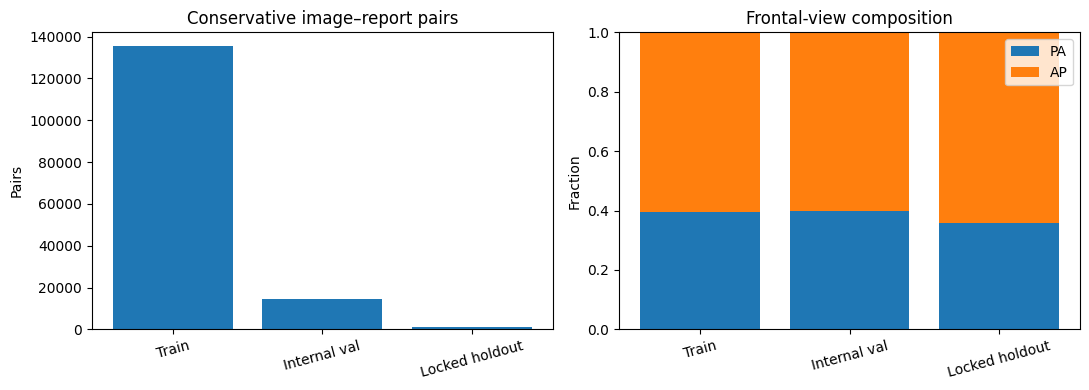


AUGMENTATION AVAILABILITY
train       : 0.999
internal_val: 0.999
holdout     : 1.000


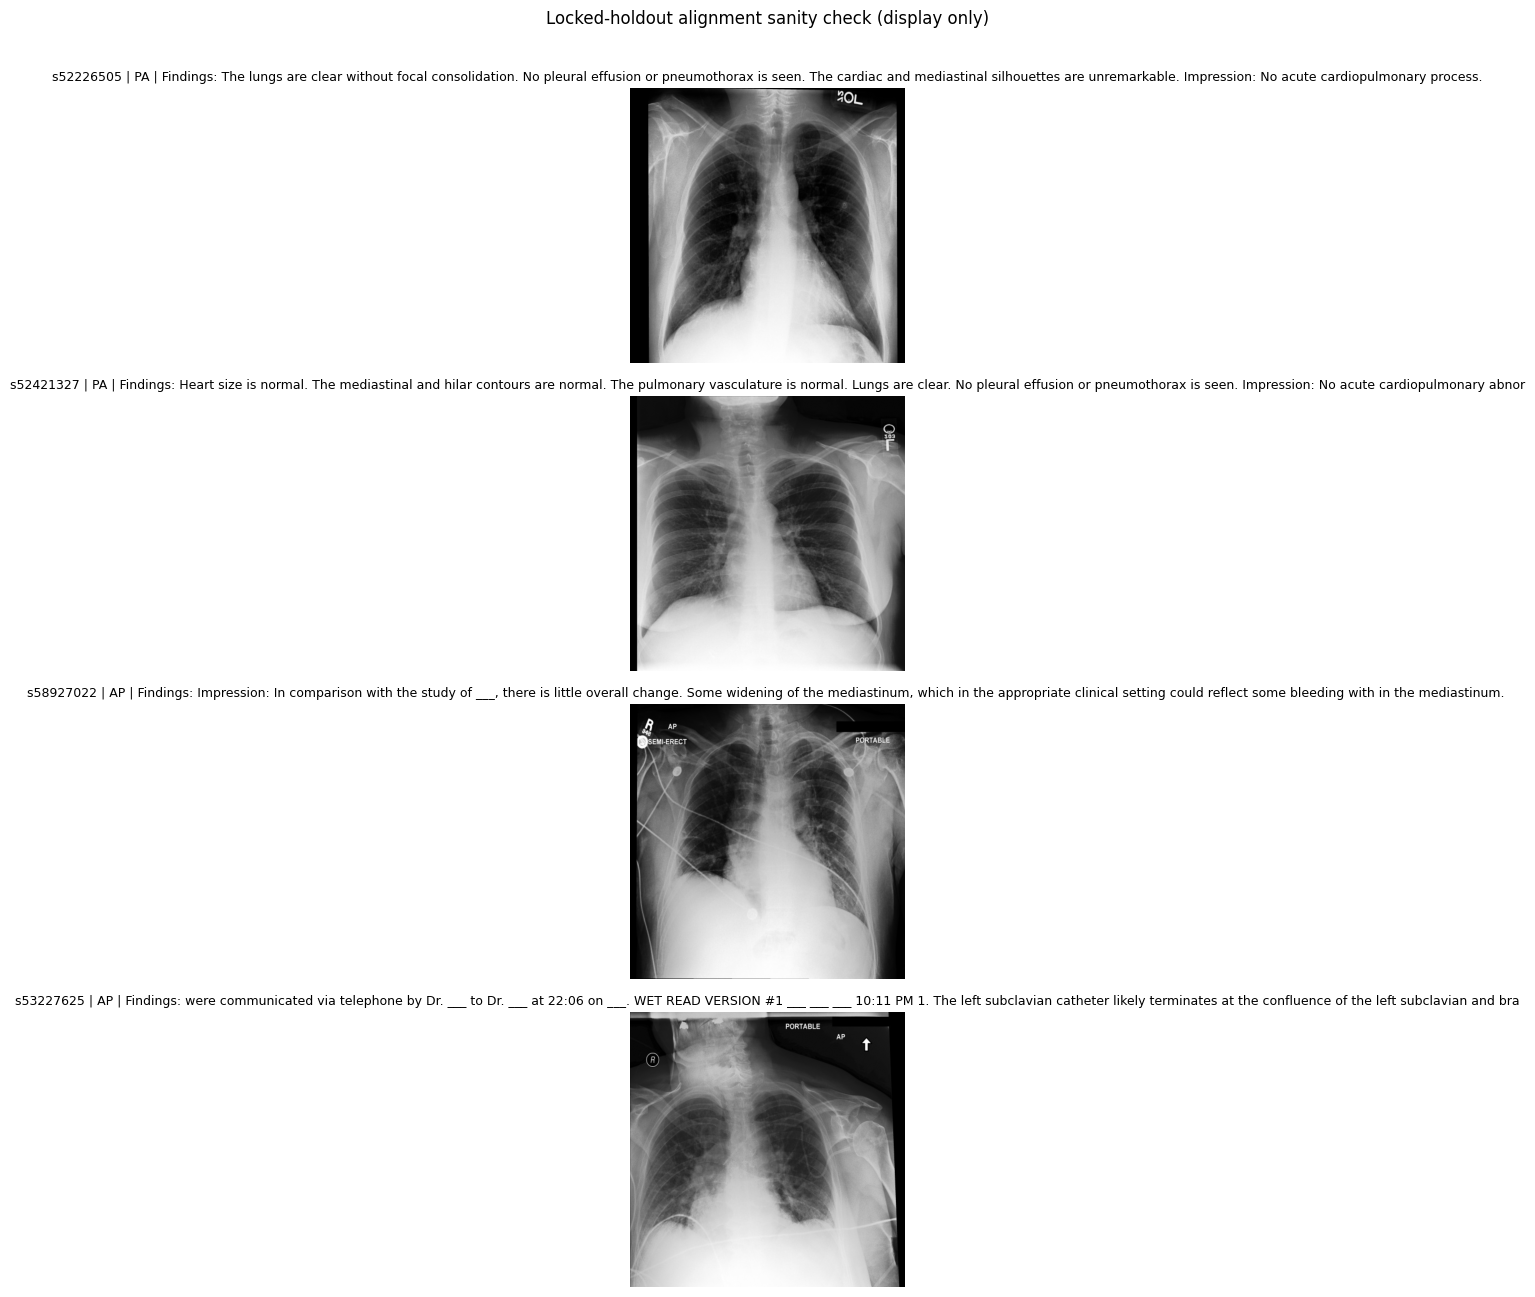

In [8]:
# ============================================================================
# 4. PATIENT-DISJOINT DEVELOPMENT / LOCKED-HOLDOUT PROTOCOL
# ============================================================================
holdout_subjects = set(holdout_manifest_raw.subject_id.astype(str))
train_pool = train_manifest_raw[
    ~train_manifest_raw.subject_id.astype(str).isin(holdout_subjects)
].reset_index(drop=True)

splitter = GroupShuffleSplit(n_splits=1, test_size=CFG.val_fraction, random_state=CFG.split_seed)
tr_idx, va_idx = next(splitter.split(train_pool, groups=train_pool.subject_id.astype(str)))
train_manifest = train_pool.iloc[tr_idx].reset_index(drop=True)
internal_val_manifest = train_pool.iloc[va_idx].reset_index(drop=True)
holdout_manifest = holdout_manifest_raw.reset_index(drop=True)


def deterministic_patient_cap(df, max_rows, seed):
    if max_rows is None or len(df) <= max_rows:
        return df.reset_index(drop=True)
    rng = np.random.default_rng(seed)
    subjects = df.subject_id.astype(str).unique().copy()
    rng.shuffle(subjects)
    selected, count = [], 0
    counts = df.subject_id.astype(str).value_counts().to_dict()
    for sid in subjects:
        selected.append(sid)
        count += counts[sid]
        if count >= max_rows:
            break
    return df[df.subject_id.astype(str).isin(selected)].reset_index(drop=True)


train_manifest = deterministic_patient_cap(train_manifest, EXP["max_train"], 42)
internal_val_manifest = deterministic_patient_cap(internal_val_manifest, EXP["max_internal_val"], 43)
holdout_manifest = deterministic_patient_cap(holdout_manifest, EXP["max_holdout"], 44)

split_subjects = {
    "train": set(train_manifest.subject_id.astype(str)),
    "internal_val": set(internal_val_manifest.subject_id.astype(str)),
    "holdout": set(holdout_manifest.subject_id.astype(str)),
}
assert split_subjects["train"].isdisjoint(split_subjects["internal_val"])
assert split_subjects["train"].isdisjoint(split_subjects["holdout"])
assert split_subjects["internal_val"].isdisjoint(split_subjects["holdout"])

split_frames = {
    "train": train_manifest,
    "internal_val": internal_val_manifest,
    "holdout": holdout_manifest,
}
for name, frame in split_frames.items():
    frame.to_csv(CACHE / f"manifest_{name}_full.csv", index=False)
    # Export manifest omits report text to avoid redistributing clinical narrative.
    frame[["source", "source_row", "subject_id", "study_id", "relative_image_path", "view"]].to_csv(
        OUT / f"manifest_index_{name}.csv", index=False
    )
    print(
        f"{name:12s}: pairs={len(frame):,} patients={frame.subject_id.nunique():,} "
        f"PA={(frame.view == 'PA').mean():.3f}"
    )

DATA_AUDIT = {
    "train_csv_audit": train_audit,
    "holdout_csv_audit": holdout_audit,
    "raw_train_pairs": int(len(train_manifest_raw)),
    "raw_holdout_pairs": int(len(holdout_manifest_raw)),
    "profile_train_pairs": int(len(train_manifest)),
    "profile_internal_val_pairs": int(len(internal_val_manifest)),
    "profile_holdout_pairs": int(len(holdout_manifest)),
    "train_patients": int(train_manifest.subject_id.nunique()),
    "internal_val_patients": int(internal_val_manifest.subject_id.nunique()),
    "holdout_patients": int(holdout_manifest.subject_id.nunique()),
    "patient_overlap_checks": "PASS",
    "train_augmentation_available_fraction": float(train_manifest.augmentation_available.mean()),
    "internal_val_augmentation_available_fraction": float(internal_val_manifest.augmentation_available.mean()),
    "holdout_augmentation_available_fraction": float(holdout_manifest.augmentation_available.mean()),
    "alignment_rule": "order-preserving only when #reports == #unique study IDs; otherwise excluded",
}
(OUT / "data_audit.json").write_text(json.dumps(DATA_AUDIT, indent=2), encoding="utf-8")

# Dataset composition plot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["Train", "Internal val", "Locked holdout"]
counts = [len(train_manifest), len(internal_val_manifest), len(holdout_manifest)]
axes[0].bar(names, counts)
axes[0].set_title("Conservative image–report pairs")
axes[0].set_ylabel("Pairs")
axes[0].tick_params(axis="x", rotation=15)
pa = [(split_frames[k].view == "PA").mean() for k in ("train", "internal_val", "holdout")]
ap = [1 - x for x in pa]
xpos = np.arange(3)
axes[1].bar(xpos, pa, label="PA")
axes[1].bar(xpos, ap, bottom=pa, label="AP")
axes[1].set_xticks(xpos, names, rotation=15)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Fraction")
axes[1].set_title("Frontal-view composition")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "01_dataset_protocol.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


# Human-readable data audit (display only; report text is not exported).
print("\nAUGMENTATION AVAILABILITY")
for _name, _frame in split_frames.items():
    print(f"{_name:12s}: {_frame.augmentation_available.mean():.3f}")

_example = holdout_manifest.sample(min(4, len(holdout_manifest)), random_state=CFG.split_seed).reset_index(drop=True)
fig, axes = plt.subplots(len(_example), 1, figsize=(10, 3.2 * len(_example)))
if len(_example) == 1:
    axes = [axes]
for ax, row in zip(axes, _example.itertuples(index=False)):
    with Image.open(row.image_path) as im:
        ax.imshow(im.convert("L"), cmap="gray")
    snippet = re.sub(r"\s+", " ", str(row.text))[:220]
    ax.set_title(f"{row.study_id} | {row.view} | {snippet}", fontsize=9)
    ax.axis("off")
fig.suptitle("Locked-holdout alignment sanity check (display only)", y=1.01)
fig.tight_layout()
plt.show()
plt.close(fig)


## Implementation notes and model provenance

- **Image encoder:** TorchXRayVision DenseNet-121 with CheXpert weights (`densenet121-res224-chex`), frozen before feature extraction.
- **Text encoder:** Microsoft BiomedBERT (`microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`). The notebook pins the exact Hugging Face revision `e1354b7a3a09615f6aba48dfad4b7a613eef7062` in the immutable protocol and records it in `encoder_provenance.json`. Transformers auto-detects the checkpoint format at that exact commit; the notebook does not force safetensors.
- **Dataset schema:** the image/view/report/list structure is consistent with the published CXR-CLIP MIMIC preprocessing format. This Kaggle mirror is nevertheless audited independently; because its CSV rows aggregate multiple studies, study↔report reconstruction is accepted only when an order-preserving one-to-one mapping is structurally possible.
- **Runtime:** the current PyTorch build is first tested in a clean child process. A PyTorch 2.6.0 + CUDA 11.8 compatibility build is installed when the assigned GPU cannot execute the current wheel or when the runtime is below the Transformers security floor required for the pinned legacy `.bin` checkpoint; NumPy/Pandas/SciPy/sklearn/Pillow/fsspec are constrained and must remain unchanged.
- **Final artifacts:** configuration, environment, dataset hashes, encoder provenance, manifests, predictions, bootstrap intervals, checkpoints, plots, and a compact results ZIP are saved under `/kaggle/working`.

The notebook does not create report-keyword disease labels, does not infer unavailable lesion masks, and does not use `text_augment` as training supervision.

- **Cache integrity:** the frozen-feature cache fingerprint includes torch, torchvision, TorchXRayVision, Transformers, encoder identifiers, and exact text-model revision. A runtime change therefore triggers clean feature re-extraction rather than mixing features across environments.


## 6. Frozen encoder feature-cache definitions


In [9]:
# ============================================================================
# 5. FROZEN EXTERNAL FEATURE EXTRACTION + FINGERPRINTED CACHING
# ============================================================================

# Frozen external-encoder revision.
# Do NOT resolve "current main" separately for each seed/run: that can silently
# change the text representation between experiments.
TEXT_REVISION = CFG.text_revision

try:
    _repo_files = HfApi().list_repo_files(
        CFG.text_model,
        revision=TEXT_REVISION,
    )
except Exception as exc:
    raise RuntimeError(
        f"Could not verify frozen text revision {TEXT_REVISION} for {CFG.text_model}. "
        "Enable Kaggle Internet on the first uncached run."
    ) from exc

if "pytorch_model.bin" not in _repo_files:
    raise RuntimeError(
        "Frozen BiomedBERT revision does not contain expected pytorch_model.bin. "
        "Protocol provenance has changed; do not silently substitute another checkpoint."
    )

# The frozen revision has no safetensors file, therefore torch>=2.6 is required
# by current Transformers for secure legacy checkpoint loading.
_torch_major_minor = tuple(
    int(x)
    for x in re.match(
        r"(\d+)\.(\d+)",
        torch.__version__,
    ).groups()
)

if _torch_major_minor < (2, 6):
    raise RuntimeError(
        f"torch {torch.__version__} is below the required >=2.6 safety floor "
        "for loading the frozen BiomedBERT pytorch_model.bin checkpoint."
    )

ENCODER_PROVENANCE = {
    "image_encoder": CFG.image_encoder,
    "image_weights": CFG.image_weights,
    "torchxrayvision_version": _pkg_version("torchxrayvision"),
    "text_model": CFG.text_model,
    "text_revision": TEXT_REVISION,
    "transformers_version": _pkg_version("transformers"),
    "text_weight_format": "official pytorch_model.bin at frozen Microsoft HF revision",
    "torch_security_floor": ">=2.6.0",
}
(OUT / "encoder_provenance.json").write_text(
    json.dumps(ENCODER_PROVENANCE, indent=2), encoding="utf-8"
)
print("Resolved text revision:", TEXT_REVISION)

def manifest_fingerprint(frame):
    cols = [
        "subject_id", "study_id", "relative_image_path", "view",
        "text", "text_augment", "augmentation_available"
    ]
    h = pd.util.hash_pandas_object(frame[cols].astype(str), index=False).to_numpy(dtype=np.uint64)
    return hashlib.sha256(h.tobytes()).hexdigest()

def encoder_fingerprint():
    # Include runtime versions because numerical feature extraction can differ
    # across torch/transformers/torchxrayvision builds. This deliberately
    # invalidates caches created under the failed torch-2.5.1 run.
    payload = (
        f"{CFG.protocol}|"
        f"{CFG.image_encoder}|{CFG.image_weights}|"
        f"{CFG.text_model}|{TEXT_REVISION}|"
        f"{CFG.image_size}|{CFG.max_text_length}|"
        f"torch={torch.__version__}|"
        f"torchvision={_pkg_version('torchvision')}|"
        f"torchxrayvision={_pkg_version('torchxrayvision')}|"
        f"transformers={_pkg_version('transformers')}"
    )
    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()

def cache_paths(split):
    return {
        "img": CACHE / f"{split}_image.npy",
        "txt": CACHE / f"{split}_text.npy",
        "aug": CACHE / f"{split}_text_aug.npy",
        "meta": CACHE / f"{split}_meta.csv",
        "fingerprint": CACHE / f"{split}_fingerprint.json",
    }

def cache_valid(split, manifest):
    p = cache_paths(split)
    if not all(p[k].exists() for k in ("img", "txt", "aug", "meta", "fingerprint")):
        return False
    try:
        fp = json.loads(p["fingerprint"].read_text())
        meta = pd.read_csv(p["meta"], nrows=2)
        return (
            fp.get("manifest") == manifest_fingerprint(manifest)
            and fp.get("encoder") == encoder_fingerprint()
            and len(pd.read_csv(p["meta"], usecols=["study_id"])) == len(manifest)
            and "augmentation_available" in meta.columns
        )
    except Exception:
        return False

class XRVImageDataset(Dataset):
    def __init__(self, manifest, condition="clean", severity=0.0):
        self.df = manifest.reset_index(drop=True)
        self.condition = condition
        self.severity = float(severity)
        self.center = xrv.datasets.XRayCenterCrop()
        self.resize = xrv.datasets.XRayResizer(CFG.image_size)

    def __len__(self):
        return len(self.df)

    def _corrupt(self, im, path):
        if self.condition == "clean":
            return im
        if self.condition == "blur":
            return im.filter(ImageFilter.GaussianBlur(radius=0.4 + 2.4 * self.severity))
        if self.condition == "contrast":
            return ImageEnhance.Contrast(im).enhance(max(0.25, 1.0 - 0.65 * self.severity))
        if self.condition == "brightness":
            return ImageEnhance.Brightness(im).enhance(max(0.35, 1.0 - 0.50 * self.severity))
        if self.condition == "noise":
            arr = np.asarray(im, dtype=np.float32)
            key = f"{path}|{self.condition}|{self.severity:.4f}"
            seed = int(hashlib.sha256(key.encode()).hexdigest()[:16], 16) % (2**32)
            rng = np.random.default_rng(seed)
            arr = np.clip(
                arr + rng.normal(0, 4 + 18 * self.severity, arr.shape), 0, 255
            ).astype(np.uint8)
            return Image.fromarray(arr)
        raise KeyError(self.condition)

    def __getitem__(self, idx):
        path = self.df.iloc[idx].image_path
        with Image.open(path) as im:
            im = self._corrupt(im.convert("L"), path)
            arr = np.asarray(im, dtype=np.float32)
        arr = xrv.datasets.normalize(arr, 255)
        arr = self.center(arr[None, ...])
        arr = self.resize(arr)
        return torch.from_numpy(np.ascontiguousarray(arr)).float(), idx

class TextDataset(Dataset):
    def __init__(self, manifest):
        self.text = manifest.text.astype(str).tolist()
        self.aug = manifest.text_augment.astype(str).tolist()
    def __len__(self):
        return len(self.text)
    def __getitem__(self, idx):
        return self.text[idx], self.aug[idx], idx


Resolved text revision: e1354b7a3a09615f6aba48dfad4b7a613eef7062


## 7. Frozen medical image/text feature extraction


In [10]:
def load_image_encoder():
    try:
        model = xrv.models.DenseNet(weights=CFG.image_weights).to(DEVICE).eval()
        for p in model.parameters():
            p.requires_grad_(False)
        return model
    except Exception as exc:
        raise RuntimeError(
            "Could not load TorchXRayVision CheXpert DenseNet weights. "
            "Internet must be enabled on the first run."
        ) from exc

@torch.inference_mode()
def image_features(model, x):
    z = model.features(x)
    if z.ndim == 4:
        z = F.relu(z, inplace=False)
        z = F.adaptive_avg_pool2d(z, (1, 1)).flatten(1)
    elif z.ndim > 2:
        z = z.flatten(1)
    return F.normalize(z.float(), dim=-1)

def load_text_encoder():
    """
    Frozen BiomedBERT feature encoder.

    The exact repository revision is pinned in Config. That revision contains a
    PyTorch .bin checkpoint, so torch>=2.6 is a runtime invariant under modern
    Transformers. We preserve the scientific encoder instead of silently
    swapping to a different language model after an environment error.
    """
    major_minor = tuple(
        int(x)
        for x in re.match(
            r"(\d+)\.(\d+)",
            torch.__version__,
        ).groups()
    )

    if major_minor < (2, 6):
        raise RuntimeError(
            f"Unsafe/incompatible runtime: torch={torch.__version__}. "
            "The frozen BiomedBERT checkpoint requires torch>=2.6 with current Transformers."
        )

    try:
        tok = AutoTokenizer.from_pretrained(
            CFG.text_model,
            revision=TEXT_REVISION,
        )

        mdl = AutoModel.from_pretrained(
            CFG.text_model,
            revision=TEXT_REVISION,
            local_files_only=False,
        ).to(
            DEVICE
        ).eval()

        for p in mdl.parameters():
            p.requires_grad_(
                False
            )

        return tok, mdl

    except Exception as exc:
        raise RuntimeError(
            "Frozen text encoder load failed after the runtime safety preflight.\n"
            f"model={CFG.text_model}\n"
            f"revision={TEXT_REVISION}\n"
            f"torch={torch.__version__}\n"
            f"transformers={_pkg_version('transformers')}\n"
            "Do not replace the encoder ad hoc; inspect network/cache/runtime first."
        ) from exc

@torch.inference_mode()
def encode_text_batch(tokenizer, model, texts):
    batch = tokenizer(
        list(texts), padding=True, truncation=True,
        max_length=CFG.max_text_length, return_tensors="pt",
    )
    batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
    out = model(**batch).last_hidden_state
    mask = batch["attention_mask"].unsqueeze(-1).float()
    z = (out * mask).sum(1) / mask.sum(1).clamp_min(1.0)
    return F.normalize(z.float(), dim=-1)

def extract_image_cache(split, manifest, model):
    p = cache_paths(split)
    loader = DataLoader(
        XRVImageDataset(manifest), batch_size=CFG.image_batch_size, shuffle=False,
        num_workers=CFG.num_workers, pin_memory=True,
        persistent_workers=(CFG.num_workers > 0),
    )
    writer = None
    for batch, idx in tqdm(loader, desc=f"Image features [{split}]"):
        z = image_features(model, batch.to(DEVICE, non_blocking=True)).cpu().numpy().astype(np.float32)
        if writer is None:
            writer = np.lib.format.open_memmap(
                p["img"], mode="w+", dtype=np.float32, shape=(len(manifest), z.shape[1])
            )
        writer[np.asarray(idx)] = z
    if writer is None:
        raise RuntimeError(f"No image features produced for {split}")
    writer.flush(); del writer

def extract_text_cache(split, manifest, tokenizer, model):
    p = cache_paths(split)
    loader = DataLoader(TextDataset(manifest), batch_size=CFG.text_batch_size, shuffle=False, num_workers=0)
    tw = aw = None
    encode_aug = (split == "holdout")  # augmentation is evaluation-only
    for texts, augs, idx in tqdm(loader, desc=f"Text features  [{split}]"):
        t = encode_text_batch(tokenizer, model, texts).cpu().numpy().astype(np.float32)
        if tw is None:
            tw = np.lib.format.open_memmap(
                p["txt"], mode="w+", dtype=np.float32, shape=(len(manifest), t.shape[1])
            )
            if encode_aug:
                aw = np.lib.format.open_memmap(
                    p["aug"], mode="w+", dtype=np.float32, shape=(len(manifest), t.shape[1])
                )
        ids = np.asarray(idx)
        tw[ids] = t
        if encode_aug:
            a = encode_text_batch(tokenizer, model, augs).cpu().numpy().astype(np.float32)
            aw[ids] = a
    if tw is None:
        raise RuntimeError(f"No text features produced for {split}")
    tw.flush(); del tw
    if encode_aug:
        aw.flush(); del aw
    else:
        # Avoid a second BERT pass on training/internal-val text_augment because it
        # is never used for optimization. Keep pack shape consistent.
        shutil.copy2(p["txt"], p["aug"])

def ensure_feature_cache():
    need = {s: not cache_valid(s, m) for s, m in split_frames.items()}
    if not any(need.values()):
        print("All feature caches match current manifests and encoder fingerprints.")
        return

    image_model = load_image_encoder()
    for split, manifest in split_frames.items():
        if need[split]:
            extract_image_cache(split, manifest, image_model)
    del image_model; gc.collect(); torch.cuda.empty_cache()

    tokenizer, text_model = load_text_encoder()
    for split, manifest in split_frames.items():
        if need[split]:
            extract_text_cache(split, manifest, tokenizer, text_model)
            p = cache_paths(split)
            manifest[
                ["subject_id", "study_id", "view", "image_path",
                 "relative_image_path", "augmentation_available"]
            ].to_csv(p["meta"], index=False)
            p["fingerprint"].write_text(
                json.dumps({
                    "manifest": manifest_fingerprint(manifest),
                    "encoder": encoder_fingerprint(),
                    "text_revision": TEXT_REVISION,
                }, indent=2),
                encoding="utf-8",
            )
    del tokenizer, text_model; gc.collect(); torch.cuda.empty_cache()

ensure_feature_cache()

def load_pack(split):
    p = cache_paths(split)
    return (
        np.load(p["img"], mmap_mode="r"),
        np.load(p["txt"], mmap_mode="r"),
        np.load(p["aug"], mmap_mode="r"),
        pd.read_csv(p["meta"], dtype={"subject_id": str, "study_id": str}),
    )

FEATURES = {split: load_pack(split) for split in split_frames}

# Metadata integrity invariant: projection view must survive cache round-trip.
for _split, (_img, _txt, _aug, _meta) in FEATURES.items():
    _views = set(_meta["view"].astype(str).unique())
    if not _views.issubset({"PA", "AP"}):
        raise RuntimeError(
            f"Unexpected projection-view values in {_split}: {sorted(_views)[:20]}"
        )

FEATURE_AUDIT = {}
for split, (img, txt, aug, meta) in FEATURES.items():
    n = len(meta)
    probe = np.unique(np.linspace(0, max(0, n - 1), min(n, 512), dtype=int))
    I = np.asarray(img[probe], dtype=np.float32)
    T = np.asarray(txt[probe], dtype=np.float32)
    A = np.asarray(aug[probe], dtype=np.float32)
    if not (np.isfinite(I).all() and np.isfinite(T).all() and np.isfinite(A).all()):
        raise RuntimeError(f"Non-finite frozen features in {split}")
    FEATURE_AUDIT[split] = {
        "n": int(n), "image_dim": int(img.shape[1]), "text_dim": int(txt.shape[1]),
        "mean_image_norm": float(np.linalg.norm(I, axis=1).mean()),
        "mean_text_norm": float(np.linalg.norm(T, axis=1).mean()),
        "augmentation_available_fraction": float(
            meta.augmentation_available.astype(str).str.lower().isin(["true", "1"]).mean()
        ),
        "aug_encoded_from_source": bool(split == "holdout"),
    }
(OUT / "feature_audit.json").write_text(json.dumps(FEATURE_AUDIT, indent=2), encoding="utf-8")
display(pd.DataFrame(FEATURE_AUDIT).T)


If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Image features [train]:   0%|          | 0/4227 [00:00<?, ?it/s]

Image features [internal_val]:   0%|          | 0/454 [00:00<?, ?it/s]

Image features [holdout]:   0%|          | 0/40 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

...

Text features  [train]:   0%|          | 0/2114 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Text features  [internal_val]:   0%|          | 0/227 [00:00<?, ?it/s]

Text features  [holdout]:   0%|          | 0/20 [00:00<?, ?it/s]

,n,image_dim,text_dim,mean_image_norm,mean_text_norm,augmentation_available_fraction,aug_encoded_from_source
train,135262,1024,768,1.0,1.0,0.99946,False
internal_val,14519,1024,768,1.0,1.0,0.99938,False
holdout,1252,1024,768,1.0,1.0,1.0,True


## 8. TRUST-VL-CXR architecture


In [11]:
# ============================================================================
# 6. BASE TASK MODEL
# ============================================================================
class FeatureDataset(Dataset):
    def __init__(self, pack):
        self.i, self.t, self.a, self.meta = pack
        self.subject_codes = pd.Categorical(self.meta.subject_id.astype(str)).codes.astype(np.int64)
    def __len__(self):
        return len(self.i)
    def __getitem__(self, idx):
        return (
            torch.tensor(np.asarray(self.i[idx]), dtype=torch.float32),
            torch.tensor(np.asarray(self.t[idx]), dtype=torch.float32),
            torch.tensor(self.subject_codes[idx], dtype=torch.long),
            torch.tensor(idx, dtype=torch.long),
        )

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim), nn.Linear(in_dim, hidden_dim),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class GatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())
    def forward(self, image_z, text_z):
        gate = self.gate(torch.cat([image_z, text_z], dim=-1))
        fused = F.normalize(gate * image_z + (1.0 - gate) * text_z, dim=-1)
        return fused, gate

class EvidentialPairHead(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # I, T, |I-T|, I*T, fused, mean(gate)
        in_dim = dim * 5 + 1
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(CFG.dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Linear(128, 2),
        )
    def forward(self, image_z, text_z, fused_z, gate_mean):
        h = torch.cat([
            image_z, text_z, torch.abs(image_z - text_z), image_z * text_z,
            fused_z, gate_mean[:, None],
        ], dim=-1)
        evidence = F.softplus(self.net(h))
        alpha = evidence + 1.0
        prob = alpha / alpha.sum(-1, keepdim=True)
        uncertainty = 2.0 / alpha.sum(-1)
        return {"alpha": alpha, "prob": prob, "uncertainty": uncertainty}

class TrustVLCXR(nn.Module):
    def __init__(self, image_dim, text_dim):
        super().__init__()
        self.image_proj = ProjectionHead(image_dim, CFG.projection_dim, CFG.hidden_dim, CFG.dropout)
        self.text_proj = ProjectionHead(text_dim, CFG.projection_dim, CFG.hidden_dim, CFG.dropout)
        self.fusion = GatedFusion(CFG.projection_dim)
        self.pair_head = EvidentialPairHead(CFG.projection_dim)

    def pair_from_projected(self, image_z, text_z):
        fused, gate = self.fusion(image_z, text_z)
        pair = self.pair_head(image_z, text_z, fused, gate.mean(-1))
        return pair, fused, gate


## 9. Losses, false-negative control, and loaders


In [12]:
# ============================================================================
# 7. LOSSES, FALSE-NEGATIVE CONTROL, AND LOADERS
# ============================================================================
def masked_symmetric_info_nce(image_z, text_z, subject_codes, temperature=CFG.temperature):
    logits = (image_z @ text_z.T) / temperature
    same = subject_codes[:, None].eq(subject_codes[None, :])
    diag = torch.eye(len(subject_codes), dtype=torch.bool, device=subject_codes.device)
    logits = logits.masked_fill(same & ~diag, -1e4)
    y = torch.arange(len(image_z), device=image_z.device)
    return 0.5 * (F.cross_entropy(logits, y) + F.cross_entropy(logits.T, y))

def dirichlet_kl_to_uniform(alpha):
    beta = torch.ones_like(alpha)
    sa = alpha.sum(-1, keepdim=True)
    sb = beta.sum(-1, keepdim=True)
    lnB_a = torch.lgamma(sa) - torch.lgamma(alpha).sum(-1, keepdim=True)
    lnB_b = torch.lgamma(beta).sum(-1, keepdim=True) - torch.lgamma(sb)
    dg = torch.digamma(alpha) - torch.digamma(sa)
    return (lnB_a + lnB_b + ((alpha - beta) * dg).sum(-1, keepdim=True)).squeeze(-1)

def evidential_ce(alpha, labels, anneal=1.0):
    onehot = F.one_hot(labels, num_classes=2).float()
    s = alpha.sum(-1, keepdim=True)
    nll = (onehot * (torch.digamma(s) - torch.digamma(alpha))).sum(-1)
    alpha_tilde = onehot + (1.0 - onehot) * alpha
    kl = dirichlet_kl_to_uniform(alpha_tilde)
    return (nll + CFG.evidential_kl_weight * anneal * kl).mean()

def make_loader(split, shuffle, seed=0):
    ds = FeatureDataset(FEATURES[split])
    bs = min(CFG.feature_batch_size, len(ds))
    g = torch.Generator().manual_seed(seed)
    return DataLoader(
        ds, batch_size=bs, shuffle=shuffle, num_workers=0,
        pin_memory=(DEVICE.type == "cuda"), drop_last=False,
        generator=g if shuffle else None,
    )

def batch_hard_indices(image_z, text_z, subject_codes):
    """Hardest cross-patient text in the current batch under projected cosine."""
    sim = image_z.detach() @ text_z.detach().T
    same = subject_codes[:, None].eq(subject_codes[None, :])
    sim = sim.masked_fill(same, -1e4)
    if torch.any((~same).sum(1) == 0):
        return None
    return sim.argmax(1)

def state_dict_sha256(module):
    h = hashlib.sha256()
    for name, tensor in sorted(module.state_dict().items()):
        h.update(name.encode())
        arr = tensor.detach().cpu().contiguous().numpy()
        h.update(arr.tobytes())
    return h.hexdigest()


## 9B. Pre-training invariants and synthetic forward-pass audit


In [13]:
# ============================================================================
# PRE-TRAINING DATA / MODEL INVARIANTS
# ============================================================================
for split, (i, t, a, m) in FEATURES.items():
    assert len(i) == len(t) == len(a) == len(m)
    assert m.subject_id.notna().all() and m.study_id.notna().all()
    assert len(m) >= 2

image_dim = FEATURES["train"][0].shape[1]
text_dim = FEATURES["train"][1].shape[1]
probe = TrustVLCXR(image_dim, text_dim).to(DEVICE).eval()
pi = torch.tensor(np.asarray(FEATURES["train"][0][:8]), dtype=torch.float32, device=DEVICE)
pt = torch.tensor(np.asarray(FEATURES["train"][1][:8]), dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    I = probe.image_proj(pi); T = probe.text_proj(pt)
    P, FZ, G = probe.pair_from_projected(I, T)
assert I.shape == T.shape == FZ.shape == (8, CFG.projection_dim)
assert G.shape == (8, CFG.projection_dim)
assert P["prob"].shape == (8, 2)
assert torch.isfinite(P["prob"]).all() and torch.isfinite(P["uncertainty"]).all()
del probe, pi, pt, I, T, P, FZ, G
torch.cuda.empty_cache()
print("PRE-TRAINING INVARIANTS: PASS")


PRE-TRAINING INVARIANTS: PASS


## 10. Retrieval and validation utilities


In [14]:
# ============================================================================
# 8. RETRIEVAL + NEGATIVE-CONSTRUCTION UTILITIES
# ============================================================================
def deterministic_patient_cap(df, max_rows, seed):
    if max_rows is None or len(df) <= max_rows:
        return df.reset_index(drop=True)
    rng = np.random.default_rng(seed)
    subjects = df.subject_id.astype(str).unique().copy()
    rng.shuffle(subjects)
    counts = df.subject_id.astype(str).value_counts().to_dict()
    selected, total = [], 0
    for sid in subjects:
        selected.append(sid); total += counts[sid]
        if total >= max_rows:
            break
    return df[df.subject_id.astype(str).isin(selected)].reset_index(drop=True)

def fixed_eval_indices(split, cap, seed):
    n = len(FEATURES[split][0])
    if cap is None or n <= cap:
        return np.arange(n)
    meta = FEATURES[split][3].copy()
    meta["_idx"] = np.arange(n)
    return deterministic_patient_cap(meta, cap, seed)["_idx"].to_numpy(dtype=int)

@torch.no_grad()
def project_arrays(model, split, use_aug=False, indices=None, batch_size=1024):
    model.eval()
    img, txt, aug, _ = FEATURES[split]
    if indices is None:
        indices = np.arange(len(img))
    source_t = aug if use_aug else txt
    Is, Ts = [], []
    for s in range(0, len(indices), batch_size):
        idx = np.asarray(indices[s:s+batch_size])
        iraw = torch.tensor(np.asarray(img[idx]), dtype=torch.float32, device=DEVICE)
        traw = torch.tensor(np.asarray(source_t[idx]), dtype=torch.float32, device=DEVICE)
        Is.append(model.image_proj(iraw).cpu())
        Ts.append(model.text_proj(traw).cpu())
    return torch.cat(Is), torch.cat(Ts)

@torch.no_grad()
def retrieval_ranks(model, split, use_aug=False, chunk=512, indices=None, mask_same_patient=True):
    I, T = project_arrays(model, split, use_aug=use_aug, indices=indices)
    meta_all = FEATURES[split][3]
    if indices is None:
        indices = np.arange(len(meta_all))
    indices = np.asarray(indices, dtype=int)
    meta = meta_all.iloc[indices].reset_index(drop=True)
    subjects = meta.subject_id.astype(str).to_numpy()
    n = len(I)
    i2t = np.empty(n, np.int32); t2i = np.empty(n, np.int32)
    for s0 in range(0, n, chunk):
        e0 = min(n, s0 + chunk)
        q = np.arange(s0, e0)
        sim = I[s0:e0] @ T.T
        if mask_same_patient:
            same = subjects[q, None] == subjects[None, :]
            same[np.arange(e0-s0), q] = False
            sim = sim.masked_fill(torch.from_numpy(same), -1e4)
        true = sim[torch.arange(e0-s0), torch.arange(s0,e0)].unsqueeze(1)
        i2t[s0:e0] = (sim > true).sum(1).numpy() + 1

        sim = T[s0:e0] @ I.T
        if mask_same_patient:
            same = subjects[q, None] == subjects[None, :]
            same[np.arange(e0-s0), q] = False
            sim = sim.masked_fill(torch.from_numpy(same), -1e4)
        true = sim[torch.arange(e0-s0), torch.arange(s0,e0)].unsqueeze(1)
        t2i[s0:e0] = (sim > true).sum(1).numpy() + 1
    return i2t, t2i

def rank_metrics(ranks, prefix):
    r = np.asarray(ranks)
    return {
        f"{prefix}_R@1": float(np.mean(r <= 1)),
        f"{prefix}_R@5": float(np.mean(r <= 5)),
        f"{prefix}_R@10": float(np.mean(r <= 10)),
        f"{prefix}_MRR": float(np.mean(1.0 / r)),
        f"{prefix}_median_rank": float(np.median(r)),
    }

def random_cross_patient_negative_indices(meta, seed):
    subjects = meta.subject_id.astype(str).to_numpy()
    n = len(subjects)
    rng = np.random.default_rng(seed)
    base = np.arange(n)
    for shift in rng.permutation(np.arange(1, n))[:min(5000, max(0, n-1))]:
        neg = np.roll(base, int(shift))
        if np.all(subjects != subjects[neg]):
            return neg
    # Deterministic fallback; duplicates are allowed but never same-patient.
    neg = np.empty(n, dtype=int)
    all_idx = np.arange(n)
    for i, sid in enumerate(subjects):
        pool = all_idx[subjects != sid]
        if len(pool) == 0:
            raise RuntimeError("Cannot create cross-patient negatives from a one-patient split.")
        neg[i] = rng.choice(pool)
    return neg

def hard_text_negative_indices(split, indices=None, chunk=256):
    """Nearest report in frozen BiomedBERT space from a different patient."""
    _, txt, _, meta_all = FEATURES[split]
    if indices is None:
        indices = np.arange(len(meta_all))
    indices = np.asarray(indices, dtype=int)
    T = np.asarray(txt[indices], dtype=np.float32)
    subjects = meta_all.iloc[indices].subject_id.astype(str).to_numpy()
    n = len(indices)
    out = np.empty(n, dtype=int)
    for s0 in range(0, n, chunk):
        e0 = min(n, s0 + chunk)
        sim = T[s0:e0] @ T.T
        same = subjects[s0:e0, None] == subjects[None, :]
        sim[same] = -np.inf
        if np.any(~np.isfinite(sim).any(1)):
            raise RuntimeError("Hard-negative construction found a query with no cross-patient candidate.")
        out[s0:e0] = sim.argmax(1)
    return out

def negative_indices(split, indices, mode, seed):
    meta_all = FEATURES[split][3]
    local = meta_all.iloc[indices].reset_index(drop=True)
    if mode == "random":
        return random_cross_patient_negative_indices(local, seed)
    if mode == "hard_text":
        return hard_text_negative_indices(split, indices=indices)
    raise KeyError(mode)


## 11. Calibration, thresholds, and pair-level evaluation


In [15]:
# ============================================================================
# 9. CALIBRATION, THRESHOLDS, AND PAIR-LEVEL EVALUATION
# ============================================================================
def expected_calibration_error(y, p, bins=15):
    y = np.asarray(y, int); p = np.asarray(p, float)
    edges = np.linspace(0, 1, bins + 1)
    ece, rows = 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p < hi if hi < 1 else p <= hi)
        if not mask.any():
            continue
        conf, acc, frac = p[mask].mean(), y[mask].mean(), mask.mean()
        ece += frac * abs(acc-conf)
        rows.append({"bin_lo":lo,"bin_hi":hi,"confidence":conf,"accuracy":acc,"n":int(mask.sum())})
    return float(ece), pd.DataFrame(rows)

def best_balanced_threshold(y, scores):
    grid = np.linspace(0.01, 0.99, 199)
    vals = np.array([balanced_accuracy_score(y, np.asarray(scores) >= t) for t in grid])
    j = int(np.nanargmax(vals))
    return float(grid[j]), float(vals[j])

@torch.no_grad()
def pair_outputs(model, split, indices=None, negative_mode="hard_text", seed=123):
    model.eval()
    img, txt, _, meta_all = FEATURES[split]
    if indices is None:
        indices = np.arange(len(img))
    indices = np.asarray(indices, dtype=int)
    neg_local = negative_indices(split, indices, negative_mode, seed)
    neg_global = indices[neg_local]

    rows = []
    bs = 1024
    for s0 in range(0, len(indices), bs):
        a = indices[s0:s0+bs]; b = neg_global[s0:s0+bs]
        I = model.image_proj(torch.tensor(np.asarray(img[a]), dtype=torch.float32, device=DEVICE))
        Tp = model.text_proj(torch.tensor(np.asarray(txt[a]), dtype=torch.float32, device=DEVICE))
        Tn = model.text_proj(torch.tensor(np.asarray(txt[b]), dtype=torch.float32, device=DEVICE))
        Pp, _, _ = model.pair_from_projected(I, Tp)
        Pn, _, _ = model.pair_from_projected(I, Tn)
        cp = F.cosine_similarity(I, Tp, dim=-1)
        cn = F.cosine_similarity(I, Tn, dim=-1)

        image_meta = meta_all.iloc[a].reset_index(drop=True)
        neg_meta = meta_all.iloc[b].reset_index(drop=True)
        for j in range(len(a)):
            common = {
                "subject_id": str(image_meta.iloc[j].subject_id),
                "study_id": str(image_meta.iloc[j].study_id),
                "view": str(image_meta.iloc[j]["view"]),
                "negative_mode": negative_mode,
            }
            rows.append({
                **common, "label_match": 1, "pair_type": "matched",
                "report_subject_id": str(image_meta.iloc[j].subject_id),
                "report_study_id": str(image_meta.iloc[j].study_id),
                "match_prob": float(Pp["prob"][j,1].item()),
                "uncertainty": float(Pp["uncertainty"][j].item()),
                "projected_cosine": float(cp[j].item()),
            })
            rows.append({
                **common, "label_match": 0, "pair_type": f"{negative_mode}_mismatch",
                "report_subject_id": str(neg_meta.iloc[j].subject_id),
                "report_study_id": str(neg_meta.iloc[j].study_id),
                "match_prob": float(Pn["prob"][j,1].item()),
                "uncertainty": float(Pn["uncertainty"][j].item()),
                "projected_cosine": float(cn[j].item()),
            })
    frame = pd.DataFrame(rows)

    assert np.all(
        frame.loc[
            frame.label_match == 0,
            "subject_id",
        ].to_numpy()
        != frame.loc[
            frame.label_match == 0,
            "report_subject_id",
        ].to_numpy()
    )

    if not set(
        frame[
            "view"
        ].astype(
            str
        ).unique()
    ).issubset(
        {
            "PA",
            "AP",
        }
    ):
        raise RuntimeError(
            "Projection-view metadata corruption detected in pair outputs."
        )

    return frame

def pair_metrics_from_frame(frame, threshold=None, prefix=""):
    y = frame.label_match.to_numpy(int)
    p = frame.match_prob.to_numpy(float)
    u = frame.uncertainty.to_numpy(float)
    c = frame.projected_cosine.to_numpy(float)
    ece, _ = expected_calibration_error(y, p)
    out = {
        f"{prefix}match_AUROC": float(roc_auc_score(y,p)),
        f"{prefix}match_AUPRC": float(average_precision_score(y,p)),
        f"{prefix}stress_Brier": float(brier_score_loss(y,p)),
        f"{prefix}stress_ECE": ece,
        f"{prefix}uncertainty_mismatch_AUROC": float(roc_auc_score(1-y,u)),
        f"{prefix}cosine_match_AUROC": float(roc_auc_score(y,c)),
    }
    if threshold is not None:
        out[f"{prefix}match_balanced_accuracy"] = float(balanced_accuracy_score(y, p >= threshold))
    return out


# --------------------------------------------------------------------------
# Validation-only probability calibration.
# Ranking metrics (AUROC/AUPRC) are reported on the raw scores; calibration
# only affects Brier/ECE and threshold-probability interpretation.
# --------------------------------------------------------------------------
def _safe_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def fit_platt_calibrator(y, probability):
    y = np.asarray(y, dtype=int)
    x = _safe_logit(probability).reshape(-1, 1)

    # Unregularized logistic calibration fit on internal validation only.
    model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=1000,
        random_state=0,
    )
    model.fit(x, y)

    return {
        "coef": float(model.coef_[0, 0]),
        "intercept": float(model.intercept_[0]),
    }

def apply_platt_calibrator(probability, calibrator):
    x = _safe_logit(probability)
    z = (
        float(calibrator["coef"]) * x
        + float(calibrator["intercept"])
    )
    return 1.0 / (1.0 + np.exp(-np.clip(z, -40.0, 40.0)))

def calibrated_binary_metrics(y, probability, calibrator, prefix):
    calibrated = apply_platt_calibrator(
        probability,
        calibrator,
    )
    ece, _ = expected_calibration_error(
        y,
        calibrated,
    )
    return {
        f"{prefix}calibrated_Brier":
        float(
            brier_score_loss(
                y,
                calibrated,
            )
        ),
        f"{prefix}calibrated_ECE":
        float(
            ece
        ),
    }


## 12. Base multimodal training


In [16]:
# ============================================================================
# 10. BASE TRAINING — FIXED INTERNAL-VALIDATION SELECTION
# ============================================================================
def train_base(seed):
    seed_everything(seed)

    image_dim = FEATURES["train"][0].shape[1]
    text_dim = FEATURES["train"][1].shape[1]
    model = TrustVLCXR(
        image_dim,
        text_dim,
    ).to(
        DEVICE
    )

    run = OUT / f"seed_{seed}"
    run.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_path = run / "base_model.pt"
    history_path = run / "base_training_history.csv"

    if checkpoint_path.exists() and history_path.exists():
        try:
            saved = torch.load(
                checkpoint_path,
                map_location="cpu",
                weights_only=False,
            )

            saved_cfg = saved.get(
                "config",
                {}
            )

            if (
                int(
                    saved.get(
                        "seed",
                        -1,
                    )
                )
                == int(
                    seed
                )
                and saved_cfg.get(
                    "protocol"
                )
                == CFG.protocol
            ):
                model.load_state_dict(
                    saved[
                        "state_dict"
                    ]
                )

                model.eval()

                hist = pd.read_csv(
                    history_path
                )

                print(
                    f"[resume] base seed={seed} | "
                    f"best val selection="
                    f"{float(saved['best_internal_val_selection']):.6f}"
                )

                return (
                    model,
                    float(
                        saved[
                            "best_internal_val_selection"
                        ]
                    ),
                    hist,
                )

        except Exception as exc:
            print(
                f"[resume warning] base seed={seed}: "
                f"{repr(exc)}; retraining."
            )
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EXP["epochs"])
    loader = make_loader("train", True, seed)

    val_idx = fixed_eval_indices("internal_val", CFG.retrieval_selection_cap, CFG.validation_subset_seed)
    pair_idx = fixed_eval_indices("internal_val", CFG.pair_selection_cap, CFG.validation_subset_seed + 1)

    best_score, best_state, stale, history = -np.inf, None, 0, []
    for epoch in range(EXP["epochs"]):
        model.train()
        epoch_loss, epoch_con, epoch_ev = [], [], []
        anneal = min(1.0, (epoch+1) / max(1, EXP["epochs"]//3))
        train_neg = random_cross_patient_negative_indices(
            FEATURES["train"][3], seed + 4444 + epoch
        )

        for image, text, subject, batch_idx in tqdm(
            loader, desc=f"Base seed={seed} e{epoch+1}", leave=False
        ):
            image = image.to(DEVICE, non_blocking=True)
            text = text.to(DEVICE, non_blocking=True)
            subject = subject.to(DEVICE, non_blocking=True)
            idx_np = batch_idx.numpy()

            I = model.image_proj(image)
            T = model.text_proj(text)

            neg_raw = torch.tensor(
                np.asarray(FEATURES["train"][1][train_neg[idx_np]]),
                dtype=torch.float32, device=DEVICE
            )
            Tneg = model.text_proj(neg_raw)

            hard_idx = batch_hard_indices(I, T, subject)
            Thard = T[hard_idx] if hard_idx is not None else Tneg

            Ppos, _, _ = model.pair_from_projected(I, T)
            Prand, _, _ = model.pair_from_projected(I, Tneg)
            Phard, _, _ = model.pair_from_projected(I, Thard)

            y1 = torch.ones(len(I), dtype=torch.long, device=DEVICE)
            y0 = torch.zeros(len(I), dtype=torch.long, device=DEVICE)

            loss_con = masked_symmetric_info_nce(I, T, subject)
            loss_ev = (
                0.50 * evidential_ce(Ppos["alpha"], y1, anneal)
                + 0.25 * evidential_ce(Prand["alpha"], y0, anneal)
                + 0.25 * evidential_ce(Phard["alpha"], y0, anneal)
            )
            loss = loss_con + loss_ev

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            opt.step()

            epoch_loss.append(float(loss.item()))
            epoch_con.append(float(loss_con.item()))
            epoch_ev.append(float(loss_ev.item()))

        sched.step()

        i2t, t2i = retrieval_ranks(model, "internal_val", indices=val_idx, mask_same_patient=True)
        ret = {**rank_metrics(i2t,"i2t"), **rank_metrics(t2i,"t2i")}
        pair = pair_outputs(
            model, "internal_val", indices=pair_idx,
            negative_mode="hard_text", seed=CFG.validation_mismatch_seed
        )
        pm = pair_metrics_from_frame(pair)
        selection = (
            0.375 * ret["i2t_R@10"]
            + 0.375 * ret["t2i_R@10"]
            + 0.250 * pm["match_AUROC"]
        )
        row = {
            "epoch": epoch+1, "train_loss": float(np.mean(epoch_loss)),
            "contrastive_loss": float(np.mean(epoch_con)),
            "evidential_pair_loss": float(np.mean(epoch_ev)),
            "selection_score": float(selection),
            "lr": float(opt.param_groups[0]["lr"]), **ret, **pm,
        }
        history.append(row)
        print(
            f"base seed={seed} epoch={epoch+1:02d} loss={row['train_loss']:.4f} "
            f"valR10=({ret['i2t_R@10']:.3f},{ret['t2i_R@10']:.3f}) "
            f"hardAUROC={pm['match_AUROC']:.3f} select={selection:.4f}"
        )

        if selection > best_score + 1e-5:
            best_score, stale = selection, 0
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= EXP["patience"]:
                break

    if best_state is None:
        raise RuntimeError("No valid base checkpoint")
    model.load_state_dict(best_state); model.eval()

    hist = pd.DataFrame(history)
    hist.to_csv(run / "base_training_history.csv", index=False)
    torch.save({
        "state_dict": best_state, "best_internal_val_selection": float(best_score),
        "config": asdict(CFG), "profile": PROFILE, "seed": seed,
    }, run / "base_model.pt")

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(hist.epoch, hist.train_loss, marker="o", label="total")
    ax.plot(hist.epoch, hist.contrastive_loss, marker="o", label="contrastive")
    ax.plot(hist.epoch, hist.evidential_pair_loss, marker="o", label="pair")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
    ax2 = ax.twinx(); ax2.plot(hist.epoch, hist.selection_score, marker="s", linestyle="--")
    ax2.set_ylabel("Internal-val selection")
    ax.set_title(f"Base training — seed {seed}")
    fig.tight_layout(); fig.savefig(FIG/f"02_base_training_seed{seed}.png", dpi=180)
    plt.show(); plt.close(fig)
    return model, float(best_score), hist


## 13. Independent decoupled compatibility monitor

The monitor is trained **after** freezing the base model. It has its own small projections of the frozen external image/text features and never receives the base pair probability, evidential uncertainty, fusion gate, or base projected features. A SHA-256 hash of the complete base state is checked before and after monitor training.


In [17]:
# ============================================================================
# 11. INDEPENDENT DECOUPLED COMPATIBILITY MONITOR
# ============================================================================
class DecoupledCompatibilityMonitor(nn.Module):
    """Independent monitor over frozen external features.

    It has its own small image/text projections and does NOT consume:
      - base match probability,
      - evidential uncertainty,
      - base fusion gate,
      - base projected features.
    """
    def __init__(self, image_dim, text_dim):
        super().__init__()
        d = CFG.monitor_dim
        self.ip = nn.Sequential(nn.LayerNorm(image_dim), nn.Linear(image_dim,d), nn.GELU())
        self.tp = nn.Sequential(nn.LayerNorm(text_dim), nn.Linear(text_dim,d), nn.GELU())
        self.net = nn.Sequential(
            nn.Linear(d*4, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256,64), nn.GELU(), nn.Linear(64,1),
        )
    def forward(self, image_raw, text_raw):
        i = F.normalize(self.ip(image_raw), dim=-1)
        t = F.normalize(self.tp(text_raw), dim=-1)
        h = torch.cat([i,t,torch.abs(i-t),i*t], dim=-1)
        return self.net(h).squeeze(-1)

def monitor_train_loader(seed):
    return make_loader("train", True, seed)

def batch_hard_text_raw(text_raw, subject_codes):
    sim = text_raw.detach() @ text_raw.detach().T
    same = subject_codes[:,None].eq(subject_codes[None,:])
    sim = sim.masked_fill(same, -1e4)
    if torch.any((~same).sum(1) == 0):
        return None
    return sim.argmax(1)

@torch.no_grad()
def evaluate_monitor(base, monitor, split, negative_mode, seed, threshold=None, indices=None):
    base.eval(); monitor.eval()
    img, txt, _, meta_all = FEATURES[split]
    if indices is None:
        indices = np.arange(len(meta_all))
    indices = np.asarray(indices, dtype=int)
    neg_local = negative_indices(split, indices, negative_mode, seed)
    neg_global = indices[neg_local]
    rows = []

    bs = 1024
    for s0 in range(0, len(indices), bs):
        a = indices[s0:s0+bs]; b = neg_global[s0:s0+bs]
        iraw = torch.tensor(np.asarray(img[a]), dtype=torch.float32, device=DEVICE)
        tpraw = torch.tensor(np.asarray(txt[a]), dtype=torch.float32, device=DEVICE)
        tnraw = torch.tensor(np.asarray(txt[b]), dtype=torch.float32, device=DEVICE)

        I = base.image_proj(iraw)
        Tp = base.text_proj(tpraw); Tn = base.text_proj(tnraw)
        Pp, _, _ = base.pair_from_projected(I,Tp)
        Pn, _, _ = base.pair_from_projected(I,Tn)

        Sm_p = torch.sigmoid(monitor(iraw,tpraw))
        Sm_n = torch.sigmoid(monitor(iraw,tnraw))
        Cp = F.cosine_similarity(I,Tp,dim=-1)
        Cn = F.cosine_similarity(I,Tn,dim=-1)

        imeta = meta_all.iloc[a].reset_index(drop=True)
        nmeta = meta_all.iloc[b].reset_index(drop=True)
        for j in range(len(a)):
            common = {
                "subject_id": str(imeta.iloc[j].subject_id),
                "study_id": str(imeta.iloc[j].study_id),
                "view": str(imeta.iloc[j]["view"]),
                "negative_mode": negative_mode,
            }
            rows.append({
                **common, "label_conflict":0, "pair_type":"matched",
                "report_subject_id":str(imeta.iloc[j].subject_id),
                "report_study_id":str(imeta.iloc[j].study_id),
                "monitor_score":float(1.0-Sm_p[j].item()),  # conflict score
                "base_conflict_score":float(1.0-Pp["prob"][j,1].item()),
                "base_uncertainty":float(Pp["uncertainty"][j].item()),
                "cosine_conflict_score":float(1.0-Cp[j].item()),
            })
            rows.append({
                **common, "label_conflict":1, "pair_type":f"{negative_mode}_mismatch",
                "report_subject_id":str(nmeta.iloc[j].subject_id),
                "report_study_id":str(nmeta.iloc[j].study_id),
                "monitor_score":float(1.0-Sm_n[j].item()),
                "base_conflict_score":float(1.0-Pn["prob"][j,1].item()),
                "base_uncertainty":float(Pn["uncertainty"][j].item()),
                "cosine_conflict_score":float(1.0-Cn[j].item()),
            })
    frame = pd.DataFrame(rows)

    if not set(
        frame[
            "view"
        ].astype(
            str
        ).unique()
    ).issubset(
        {
            "PA",
            "AP",
        }
    ):
        raise RuntimeError(
            "Projection-view metadata corruption detected in monitor outputs."
        )

    y = frame.label_conflict.to_numpy(int)
    out = {
        "monitor_AUROC": float(roc_auc_score(y, frame.monitor_score)),
        "monitor_AUPRC": float(average_precision_score(y, frame.monitor_score)),
        "base_conflict_AUROC": float(roc_auc_score(y, frame.base_conflict_score)),
        "uncertainty_conflict_AUROC": float(roc_auc_score(y, frame.base_uncertainty)),
        "cosine_conflict_AUROC": float(roc_auc_score(y, frame.cosine_conflict_score)),
    }
    if threshold is not None:
        out["monitor_balanced_accuracy"] = float(
            balanced_accuracy_score(y, frame.monitor_score >= threshold)
        )
    return out, frame

def train_monitor(base, seed):
    for p in base.parameters():
        p.requires_grad_(
            False
        )

    base.eval()

    base_hash_before = state_dict_sha256(
        base
    )

    image_dim = FEATURES["train"][0].shape[1]
    text_dim = FEATURES["train"][1].shape[1]

    monitor = DecoupledCompatibilityMonitor(
        image_dim,
        text_dim,
    ).to(
        DEVICE
    )

    run = OUT / f"seed_{seed}"
    run.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_path = run / "decoupled_monitor.pt"
    history_path = run / "monitor_training_history.csv"

    if checkpoint_path.exists() and history_path.exists():
        try:
            saved = torch.load(
                checkpoint_path,
                map_location="cpu",
                weights_only=False,
            )

            if (
                saved.get(
                    "base_hash_before"
                )
                == base_hash_before
                and saved.get(
                    "base_hash_after"
                )
                == base_hash_before
            ):
                monitor.load_state_dict(
                    saved[
                        "state_dict"
                    ]
                )

                monitor.eval()

                hist = pd.read_csv(
                    history_path
                )

                print(
                    f"[resume] monitor seed={seed} | "
                    f"val AUROC="
                    f"{float(saved['best_internal_val_AUROC']):.6f}"
                )

                return (
                    monitor,
                    float(
                        saved[
                            "threshold"
                        ]
                    ),
                    float(
                        saved[
                            "best_internal_val_AUROC"
                        ]
                    ),
                    hist,
                    base_hash_before,
                )

        except Exception as exc:
            print(
                f"[resume warning] monitor seed={seed}: "
                f"{repr(exc)}; retraining."
            )
    opt = torch.optim.AdamW(monitor.parameters(), lr=CFG.monitor_lr, weight_decay=CFG.weight_decay)
    bce = nn.BCEWithLogitsLoss()
    best, best_state, stale, history = -np.inf, None, 0, []

    val_idx = fixed_eval_indices("internal_val", CFG.pair_selection_cap, CFG.validation_subset_seed+2)
    for epoch in range(EXP["monitor_epochs"]):
        monitor.train()
        random_neg = random_cross_patient_negative_indices(
            FEATURES["train"][3], seed + 9000 + epoch
        )
        losses = []
        for image, text, subject, idx in tqdm(
            monitor_train_loader(seed+epoch), desc=f"Monitor seed={seed} e{epoch+1}", leave=False
        ):
            image = image.to(DEVICE); text = text.to(DEVICE); subject = subject.to(DEVICE)
            ids = idx.numpy()
            rand = torch.tensor(
                np.asarray(FEATURES["train"][1][random_neg[ids]]),
                dtype=torch.float32, device=DEVICE
            )
            hard_idx = batch_hard_text_raw(text, subject)
            hard = text[hard_idx] if hard_idx is not None else rand

            lp = monitor(image,text)
            lr = monitor(image,rand)
            lh = monitor(image,hard)
            # Monitor output is compatibility logit. Positives=1, mismatches=0.
            one = torch.ones_like(lp); zero = torch.zeros_like(lp)
            loss = 0.50*bce(lp,one) + 0.25*bce(lr,zero) + 0.25*bce(lh,zero)

            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(monitor.parameters(), CFG.grad_clip); opt.step()
            losses.append(float(loss.item()))

        vm, _ = evaluate_monitor(
            base, monitor, "internal_val", "hard_text",
            CFG.validation_mismatch_seed, indices=val_idx
        )
        score = vm["monitor_AUROC"]
        history.append({"epoch":epoch+1,"train_loss":float(np.mean(losses)),**vm})
        print(f"monitor seed={seed} epoch={epoch+1:02d} loss={np.mean(losses):.4f} hardValAUROC={score:.4f}")
        if score > best + 1e-5:
            best, stale = score, 0
            best_state = {k:v.detach().cpu().clone() for k,v in monitor.state_dict().items()}
        else:
            stale += 1
            if stale >= EXP["patience"]:
                break

    if best_state is None:
        raise RuntimeError("No monitor checkpoint")
    monitor.load_state_dict(best_state); monitor.eval()

    _, vf = evaluate_monitor(
        base, monitor, "internal_val", "hard_text",
        CFG.validation_mismatch_seed, indices=val_idx
    )
    threshold, val_bacc = best_balanced_threshold(vf.label_conflict, vf.monitor_score)

    base_hash_after = state_dict_sha256(base)
    if base_hash_before != base_hash_after:
        raise RuntimeError("Base model changed during monitor training; decoupling invariant violated.")

    hist = pd.DataFrame(history)
    hist.to_csv(run/"monitor_training_history.csv", index=False)
    torch.save({
        "state_dict":best_state, "threshold":threshold,
        "best_internal_val_AUROC":float(best),
        "internal_val_balanced_accuracy":val_bacc,
        "base_hash_before":base_hash_before, "base_hash_after":base_hash_after,
    }, run/"decoupled_monitor.pt")

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(hist.epoch,hist.train_loss,marker="o")
    ax2=ax.twinx(); ax2.plot(hist.epoch,hist.monitor_AUROC,marker="s")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Monitor loss"); ax2.set_ylabel("Hard-val AUROC")
    ax.set_title(f"Independent monitor — seed {seed}")
    fig.tight_layout(); fig.savefig(FIG/f"03_monitor_training_seed{seed}.png",dpi=180)
    plt.show(); plt.close(fig)
    return monitor, threshold, float(best), hist, base_hash_before


## 14. Language and visual-shift analyses


In [18]:
# ============================================================================
# 12. LOCKED LANGUAGE-PERTURBATION ANALYSIS
# ============================================================================
@torch.no_grad()
def language_analysis(base):
    img, txt, aug, meta = FEATURES["holdout"]
    available = meta.augmentation_available.astype(str).str.lower().isin(["true","1"]).to_numpy()
    indices = np.flatnonzero(available)
    if len(indices) < 20:
        return {
            "n_language_perturbation_samples":int(len(indices)),
            "mean_text_paraphrase_cos":np.nan,
            "mean_abs_match_prob_shift":np.nan,
            "language_instability_vs_match_shift_spearman":np.nan,
        }, pd.DataFrame()

    rows=[]
    for s0 in range(0,len(indices),1024):
        idx=indices[s0:s0+1024]
        I=base.image_proj(torch.tensor(np.asarray(img[idx]),dtype=torch.float32,device=DEVICE))
        T=base.text_proj(torch.tensor(np.asarray(txt[idx]),dtype=torch.float32,device=DEVICE))
        A=base.text_proj(torch.tensor(np.asarray(aug[idx]),dtype=torch.float32,device=DEVICE))
        Po,_,_=base.pair_from_projected(I,T)
        Pa,_,_=base.pair_from_projected(I,A)
        for j,gidx in enumerate(idx):
            rows.append({
                "feature_index":int(gidx),
                "subject_id":str(meta.iloc[gidx].subject_id),
                "study_id":str(meta.iloc[gidx].study_id),
                "view":str(meta.iloc[gidx]["view"]),
                "image_text_cos_orig":float(F.cosine_similarity(I[j:j+1],T[j:j+1]).item()),
                "image_text_cos_aug":float(F.cosine_similarity(I[j:j+1],A[j:j+1]).item()),
                "text_paraphrase_cos":float(F.cosine_similarity(T[j:j+1],A[j:j+1]).item()),
                "match_prob_orig":float(Po["prob"][j,1].item()),
                "match_prob_aug":float(Pa["prob"][j,1].item()),
                "uncertainty_orig":float(Po["uncertainty"][j].item()),
                "uncertainty_aug":float(Pa["uncertainty"][j].item()),
            })
    frame=pd.DataFrame(rows)
    frame["language_instability"]=1-frame.text_paraphrase_cos
    frame["match_prob_shift"]=np.abs(frame.match_prob_orig-frame.match_prob_aug)
    rho=spearmanr(frame.language_instability,frame.match_prob_shift).statistic
    return {
        "n_language_perturbation_samples":int(len(frame)),
        "mean_text_paraphrase_cos":float(frame.text_paraphrase_cos.mean()),
        "mean_abs_match_prob_shift":float(frame.match_prob_shift.mean()),
        "language_instability_vs_match_shift_spearman":float(rho),
    },frame


## 15. Patient-cluster bootstrap and selective prediction


In [19]:
# ============================================================================
# 13. CLUSTERED UNCERTAINTY, SELECTIVE RISK, AND VISUAL SHIFT
# ============================================================================
def patient_cluster_bootstrap(frame, metric_fns, reps, seed, scope):
    subjects=frame.subject_id.astype(str).unique()
    by={sid:frame[frame.subject_id.astype(str)==sid] for sid in subjects}
    rng=np.random.default_rng(seed)
    vals={k:[] for k in metric_fns}
    for _ in range(reps):
        draw=rng.choice(subjects,size=len(subjects),replace=True)
        sample=pd.concat([by[s] for s in draw],ignore_index=True)
        for name,fn in metric_fns.items():
            try:
                v=float(fn(sample))
                if np.isfinite(v): vals[name].append(v)
            except Exception:
                pass
    rows=[]
    for name,arr in vals.items():
        a=np.asarray(arr,float)
        if len(a) < max(20, int(0.90*reps)):
            raise RuntimeError(f"Too few valid bootstrap replicates for {name}: {len(a)}/{reps}")
        rows.append({
            "metric":name,"estimate":float(metric_fns[name](frame)),
            "ci95_low":float(np.quantile(a,.025)),"ci95_high":float(np.quantile(a,.975)),
            "n_boot":int(len(a)),"cluster_unit":"subject_id","bootstrap_scope":scope,
        })
    return pd.DataFrame(rows)

def risk_coverage_curve(labels,probs,risk_score,threshold,points=50):
    labels=np.asarray(labels,int); probs=np.asarray(probs,float); risk=np.asarray(risk_score,float)
    order=np.argsort(risk); pred=probs>=threshold
    err=(pred!=labels).astype(float)[order]; n=len(err)
    rows=[]
    for cov in np.linspace(.1,1,points):
        k=max(1,int(round(cov*n)))
        rows.append({"coverage":k/n,"risk":float(err[:k].mean())})
    return pd.DataFrame(rows)


VISUAL_SHIFT_CONDITIONS = (
    "noise",
    "blur",
    "contrast",
    "brightness",
)

VISUAL_SHIFT_SEVERITIES = (
    0.25,
    0.50,
    0.75,
    1.00,
)

def _visual_shift_cache_fingerprint(subset):
    identity = subset[
        [
            "subject_id",
            "study_id",
            "relative_image_path",
            "view",
        ]
    ].astype(
        str
    )

    subset_hash = hashlib.sha256(
        pd.util.hash_pandas_object(
            identity,
            index=False,
        ).to_numpy(
            dtype=np.uint64
        ).tobytes()
    ).hexdigest()

    payload = {
        "subset_hash":
        subset_hash,
        "encoder":
        encoder_fingerprint(),
        "conditions":
        list(
            VISUAL_SHIFT_CONDITIONS
        ),
        "severities":
        list(
            VISUAL_SHIFT_SEVERITIES
        ),
        "visual_subset_seed":
        int(
            CFG.visual_subset_seed
        ),
        "visual_shift_n":
        int(
            EXP[
                "visual_shift_n"
            ]
        ),
    }

    return hashlib.sha256(
        json.dumps(
            payload,
            sort_keys=True,
        ).encode(
            "utf-8"
        )
    ).hexdigest(), payload


def ensure_visual_shift_feature_cache():
    """
    External DenseNet corruption features do not depend on the TRUST seed.

    v6 recomputed them independently for seeds 17/42/73, which was expensive
    and caused the first paper run to expire during seed 73. v7 computes them
    once, fingerprints the cache, and reuses them for every seed.
    """
    n = min(
        int(
            EXP[
                "visual_shift_n"
            ]
        ),
        len(
            holdout_manifest
        ),
    )

    subset = deterministic_patient_cap(
        holdout_manifest,
        n,
        CFG.visual_subset_seed,
    ).reset_index(
        drop=True
    )

    cache_npz = CACHE / "visual_shift_external_features.npz"
    cache_meta = CACHE / "visual_shift_external_meta.csv"
    cache_fp = CACHE / "visual_shift_external_fingerprint.json"

    fingerprint, payload = _visual_shift_cache_fingerprint(
        subset
    )

    if (
        cache_npz.exists()
        and cache_meta.exists()
        and cache_fp.exists()
    ):
        try:
            saved = json.loads(
                cache_fp.read_text(
                    encoding="utf-8"
                )
            )

            if saved.get(
                "fingerprint"
            ) == fingerprint:
                archive = np.load(
                    cache_npz,
                    allow_pickle=False,
                )

                if int(
                    archive[
                        "holdout_indices"
                    ].shape[
                        0
                    ]
                ) == len(
                    subset
                ):
                    print(
                        "[resume] visual-shift external feature cache"
                    )

                    return (
                        subset,
                        archive,
                    )

        except Exception:
            pass

    # Map selected studies into the clean frozen holdout pack.
    h_meta = FEATURES[
        "holdout"
    ][
        3
    ]

    key_to_idx = {
        (
            str(
                row.subject_id
            ),
            str(
                row.study_id
            ),
        ):
        int(
            index
        )
        for index, row
        in h_meta.iterrows()
    }

    holdout_indices = np.asarray(
        [
            key_to_idx[
                (
                    str(
                        row.subject_id
                    ),
                    str(
                        row.study_id
                    ),
                )
            ]
            for row
            in subset.itertuples(
                index=False
            )
        ],
        dtype=np.int64,
    )

    arrays = {
        "holdout_indices":
        holdout_indices,
    }

    image_model = load_image_encoder()

    try:
        for condition in VISUAL_SHIFT_CONDITIONS:
            for severity in VISUAL_SHIFT_SEVERITIES:
                key = (
                    f"{condition}_"
                    f"{int(round(severity * 100)):03d}"
                )

                loader = DataLoader(
                    XRVImageDataset(
                        subset,
                        condition,
                        severity,
                    ),
                    batch_size=CFG.image_batch_size,
                    shuffle=False,
                    num_workers=0,
                    pin_memory=(
                        DEVICE.type
                        == "cuda"
                    ),
                    drop_last=False,
                )

                chunks = []

                for xb, _ in tqdm(
                    loader,
                    desc=(
                        f"Cache shift "
                        f"{condition}:{severity:.2f}"
                    ),
                    leave=False,
                ):
                    chunks.append(
                        image_features(
                            image_model,
                            xb.to(
                                DEVICE,
                                non_blocking=True,
                            ),
                        ).cpu().numpy().astype(
                            np.float32
                        )
                    )

                arrays[
                    key
                ] = np.concatenate(
                    chunks,
                    axis=0,
                )

                if arrays[
                    key
                ].shape[
                    0
                ] != len(
                    subset
                ):
                    raise RuntimeError(
                        f"Visual cache row mismatch for {key}"
                    )

    finally:
        del image_model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    np.savez(
        cache_npz,
        **arrays,
    )

    subset[
        [
            "subject_id",
            "study_id",
            "view",
            "relative_image_path",
        ]
    ].to_csv(
        cache_meta,
        index=False,
    )

    cache_fp.write_text(
        json.dumps(
            {
                "fingerprint":
                fingerprint,
                "payload":
                payload,
            },
            indent=2,
        ),
        encoding="utf-8",
    )

    archive = np.load(
        cache_npz,
        allow_pickle=False,
    )

    print(
        "Visual-shift external feature cache: BUILT ONCE"
    )

    return (
        subset,
        archive,
    )


@torch.no_grad()
def visual_shift_analysis(base):
    subset, archive = ensure_visual_shift_feature_cache()

    ids = np.asarray(
        archive[
            "holdout_indices"
        ],
        dtype=np.int64,
    )

    h_img, h_txt, _, _ = FEATURES[
        "holdout"
    ]

    clean_raw = torch.tensor(
        np.asarray(
            h_img[
                ids
            ]
        ),
        dtype=torch.float32,
        device=DEVICE,
    )

    text_raw = torch.tensor(
        np.asarray(
            h_txt[
                ids
            ]
        ),
        dtype=torch.float32,
        device=DEVICE,
    )

    Ic = base.image_proj(
        clean_raw
    )

    T = base.text_proj(
        text_raw
    )

    Pc, _, _ = base.pair_from_projected(
        Ic,
        T,
    )

    rows = []

    for condition in VISUAL_SHIFT_CONDITIONS:
        for severity in VISUAL_SHIFT_SEVERITIES:
            key = (
                f"{condition}_"
                f"{int(round(severity * 100)):03d}"
            )

            corrupt_raw = torch.tensor(
                np.asarray(
                    archive[
                        key
                    ]
                ),
                dtype=torch.float32,
                device=DEVICE,
            )

            Ix = base.image_proj(
                corrupt_raw
            )

            Px, _, _ = base.pair_from_projected(
                Ix,
                T,
            )

            drift = (
                1.0
                - F.cosine_similarity(
                    Ic,
                    Ix,
                )
            )

            drop = (
                Pc[
                    "prob"
                ][
                    :,
                    1
                ]
                - Px[
                    "prob"
                ][
                    :,
                    1
                ]
            )

            uncertainty_delta = (
                Px[
                    "uncertainty"
                ]
                - Pc[
                    "uncertainty"
                ]
            )

            for index, row in enumerate(
                subset.itertuples(
                    index=False
                )
            ):
                rows.append({
                    "subject_id":
                    str(
                        row.subject_id
                    ),
                    "study_id":
                    str(
                        row.study_id
                    ),
                    "view":
                    str(
                        row.view
                    ),
                    "condition":
                    condition,
                    "severity":
                    float(
                        severity
                    ),
                    "visual_drift":
                    float(
                        drift[
                            index
                        ].item()
                    ),
                    "compatibility_drop":
                    float(
                        drop[
                            index
                        ].item()
                    ),
                    "uncertainty_delta":
                    float(
                        uncertainty_delta[
                            index
                        ].item()
                    ),
                })

    frame = pd.DataFrame(
        rows
    )

    return {
        "visual_drift_vs_compatibility_drop_spearman":
        float(
            spearmanr(
                frame.visual_drift,
                frame.compatibility_drop,
            ).statistic
        ),
        "visual_drift_vs_uncertainty_delta_spearman":
        float(
            spearmanr(
                frame.visual_drift,
                frame.uncertainty_delta,
            ).statistic
        ),
        "n_visual_shift_records":
        int(
            len(
                frame
            )
        ),
    }, frame


## 16. Paper-style plots


In [20]:
# ============================================================================
# 14. PAPER-STYLE PLOTS
# ============================================================================
def plot_retrieval(metrics, seed):
    labels=["I→T R@1","I→T R@5","I→T R@10","T→I R@1","T→I R@5","T→I R@10"]
    keys=["i2t_R@1","i2t_R@5","i2t_R@10","t2i_R@1","t2i_R@5","t2i_R@10"]
    fig,ax=plt.subplots(figsize=(9,4.5)); ax.bar(np.arange(6),[metrics[k] for k in keys])
    ax.set_xticks(np.arange(6),labels,rotation=25,ha="right"); ax.set_ylim(0,1)
    ax.set_ylabel("Recall"); ax.set_title(f"Patient-masked retrieval — seed {seed}")
    fig.tight_layout(); fig.savefig(FIG/f"04_retrieval_seed{seed}.png",dpi=180); plt.show(); plt.close(fig)

def plot_reliability(metrics, seed):
    labels=["Pair head","Cosine","Evidential UQ","Base conflict","Decoupled monitor"]
    vals=[
        metrics["hard_match_AUROC"],metrics["hard_cosine_match_AUROC"],
        metrics["hard_uncertainty_mismatch_AUROC"],metrics["hard_base_conflict_AUROC"],
        metrics["hard_monitor_AUROC"],
    ]
    fig,ax=plt.subplots(figsize=(8,4.5)); ax.bar(labels,vals); ax.axhline(.5,ls="--",lw=1)
    ax.set_ylim(0,1); ax.set_ylabel("AUROC"); ax.set_title(f"Hard-mismatch reliability — seed {seed}")
    ax.tick_params(axis="x",rotation=20); fig.tight_layout()
    fig.savefig(FIG/f"05_reliability_seed{seed}.png",dpi=180); plt.show(); plt.close(fig)

def plot_conflict_roc(frame, seed):
    y=frame.label_conflict.to_numpy(int)
    curves={
        "Decoupled monitor":frame.monitor_score,
        "Base conflict":frame.base_conflict_score,
        "Evidential uncertainty":frame.base_uncertainty,
        "Cosine conflict":frame.cosine_conflict_score,
    }
    fig,ax=plt.subplots(figsize=(6,5))
    for name,score in curves.items():
        fpr,tpr,_=roc_curve(y,score)
        auc=roc_auc_score(y,score)
        ax.plot(fpr,tpr,label=f"{name} ({auc:.3f})")
    ax.plot([0,1],[0,1],ls="--",lw=1)
    ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate")
    ax.set_title(f"Hard cross-patient mismatch ROC — seed {seed}"); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG/f"06_hard_conflict_roc_seed{seed}.png",dpi=180)
    plt.show(); plt.close(fig)


In [21]:
def plot_calibration(pair_frame, seed):
    _,cal=expected_calibration_error(pair_frame.label_match,pair_frame.match_prob,bins=12)
    fig,ax=plt.subplots(figsize=(5.5,5)); ax.plot([0,1],[0,1],ls="--",label="Ideal")
    if len(cal): ax.plot(cal.confidence,cal.accuracy,marker="o",label="Model")
    ax.set_xlim(0,1);ax.set_ylim(0,1);ax.set_xlabel("Predicted match probability")
    ax.set_ylabel("Empirical match frequency")
    ax.set_title(f"Balanced hard-mismatch stress calibration — seed {seed}")
    ax.legend();fig.tight_layout();fig.savefig(FIG/f"07_calibration_seed{seed}.png",dpi=180)
    plt.show();plt.close(fig);return cal

def plot_language(frame,seed):
    if frame.empty: return
    sample=frame.sample(min(1000,len(frame)),random_state=seed)
    fig,ax=plt.subplots(figsize=(6,4.5))
    ax.scatter(sample.language_instability,sample.match_prob_shift,s=12,alpha=.45)
    ax.set_xlabel("Language instability (1 − text cosine)")
    ax.set_ylabel("|Δ match probability|");ax.set_title(f"Language perturbation — seed {seed}")
    fig.tight_layout();fig.savefig(FIG/f"08_language_shift_seed{seed}.png",dpi=180)
    plt.show();plt.close(fig)

def plot_visual(frame,seed):
    agg=frame.groupby(["condition","severity"],as_index=False).agg(
        compatibility_drop=("compatibility_drop","mean"),
        uncertainty_delta=("uncertainty_delta","mean"),
        visual_drift=("visual_drift","mean"),
    )
    fig,axes=plt.subplots(1,2,figsize=(12,4.5))
    for cond,g in agg.groupby("condition"):
        axes[0].plot(g.severity,g.compatibility_drop,marker="o",label=cond)
        axes[1].plot(g.severity,g.uncertainty_delta,marker="o",label=cond)
    axes[0].set_ylabel("Mean compatibility drop");axes[1].set_ylabel("Mean uncertainty increase")
    for ax in axes:
        ax.set_xlabel("Corruption severity");ax.legend(fontsize=8)
    fig.suptitle(f"Controlled visual shift — seed {seed}")
    fig.tight_layout();fig.savefig(FIG/f"09_visual_shift_seed{seed}.png",dpi=180)
    plt.show();plt.close(fig);return agg

def plot_risk_coverage(curve,seed):
    fig,ax=plt.subplots(figsize=(6.5,4.5));ax.plot(curve.coverage,curve.risk,marker="o",ms=3)
    ax.set_xlabel("Coverage (lowest uncertainty retained)");ax.set_ylabel("Pair error rate")
    ax.set_title(f"Selective risk–coverage — hard mismatch, seed {seed}")
    fig.tight_layout();fig.savefig(FIG/f"10_risk_coverage_seed{seed}.png",dpi=180)
    plt.show();plt.close(fig)


## 17. Pre-specified projection-view subgroup audit


In [22]:
# ============================================================================
# 15. PRE-SPECIFIED PA/AP SUBGROUP AUDIT
# ============================================================================
def safe_auc(y,s):
    y=np.asarray(y,int)
    return np.nan if len(np.unique(y))<2 else float(roc_auc_score(y,np.asarray(s,float)))

def subgroup_metrics(pair_frame,monitor_frame):
    rows=[]
    for view in ("PA","AP"):
        pf=pair_frame[pair_frame.view==view]
        mf=monitor_frame[monitor_frame.view==view]
        rows.append({
            "view":view,"n_pair_rows":len(pf),"n_monitor_rows":len(mf),
            "match_AUROC":safe_auc(pf.label_match,pf.match_prob) if len(pf) else np.nan,
            "cosine_match_AUROC":safe_auc(pf.label_match,pf.projected_cosine) if len(pf) else np.nan,
            "uncertainty_mismatch_AUROC":safe_auc(1-pf.label_match,pf.uncertainty) if len(pf) else np.nan,
            "monitor_AUROC":safe_auc(mf.label_conflict,mf.monitor_score) if len(mf) else np.nan,
            "base_conflict_AUROC":safe_auc(mf.label_conflict,mf.base_conflict_score) if len(mf) else np.nan,
        })
    return pd.DataFrame(rows)


## v7 paper-completeness and resume contract

A seed is considered complete only after metrics, patient-cluster bootstrap intervals,
predictions, subgroup tables, and visual/language stress records have all been written.

The notebook never silently creates a three-seed mean from two seeds.


In [23]:
REQUIRED_SEED_FILES = (
    "holdout_metrics.json",
    "holdout_retrieval.csv",
    "holdout_hard_pair_predictions.csv",
    "holdout_hard_monitor_predictions.csv",
    "projection_view_subgroups_hard.csv",
    "patient_cluster_bootstrap_ci.csv",
    "visual_shift_records.csv",
    "holdout_language_perturbation.csv",
    "seed_complete.json",
)


def seed_is_complete(
    seed,
):
    run = (
        OUT
        / f"seed_{seed}"
    )

    return all(
        (
            run
            / name
        ).exists()
        for name in REQUIRED_SEED_FILES
    )


def load_completed_seed(
    seed,
):
    run = (
        OUT
        / f"seed_{seed}"
    )

    metrics = json.loads(
        (
            run
            / "holdout_metrics.json"
        ).read_text(
            encoding="utf-8"
        )
    )

    bootstrap = pd.read_csv(
        run
        / "patient_cluster_bootstrap_ci.csv"
    )

    return (
        metrics,
        bootstrap,
    )


def persist_partial_results(
    seed_rows,
    bootstrap_frames,
):
    if seed_rows:
        partial = pd.DataFrame(
            seed_rows
        )

        partial.to_csv(
            OUT
            / "seed_level_results_PARTIAL.csv",
            index=False,
        )

    if bootstrap_frames:
        pd.concat(
            bootstrap_frames,
            ignore_index=True,
        ).to_csv(
            OUT
            / "bootstrap_all_seeds_PARTIAL.csv",
            index=False,
        )

    status = {
        "expected_seeds":
        list(
            EXP[
                "seeds"
            ]
        ),
        "completed_seeds":
        [
            int(
                seed
            )
            for seed in EXP[
                "seeds"
            ]
            if seed_is_complete(
                seed
            )
        ],
        "analysis_revision":
        CFG.analysis_revision,
        "core_protocol":
        CFG.protocol,
    }

    (
        OUT
        / "run_status.json"
    ).write_text(
        json.dumps(
            status,
            indent=2,
        ),
        encoding="utf-8",
    )


def entropy_binary(
    probability,
):
    p = np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        1e-7,
        1.0
        - 1e-7,
    )

    return -(
        p
        * np.log(
            p
        )
        + (
            1.0
            - p
        )
        * np.log(
            1.0
            - p
        )
    )


def area_under_risk_coverage(
    curve,
):
    x = curve[
        "coverage"
    ].to_numpy(
        dtype=float
    )

    y = curve[
        "risk"
    ].to_numpy(
        dtype=float
    )

    integrate = (
        np.trapezoid
        if hasattr(
            np,
            "trapezoid"
        )
        else np.trapz
    )

    return float(
        integrate(
            y,
            x,
        )
    )


## 18. Full locked-holdout experiment



TRUST-VL-CXR SEED 17


Base seed=17 e1:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=17 epoch=01 loss=5.5391 valR10=(0.035,0.035) hardAUROC=0.550 select=0.1637


Base seed=17 e2:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=17 epoch=02 loss=5.1498 valR10=(0.049,0.049) hardAUROC=0.483 select=0.1576


...

base seed=17 epoch=14 loss=4.4030 valR10=(0.085,0.082) hardAUROC=0.572 select=0.2053


Base seed=17 e15:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=17 epoch=15 loss=4.3895 valR10=(0.088,0.083) hardAUROC=0.573 select=0.2074


Base seed=17 e16:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=17 epoch=16 loss=4.3776 valR10=(0.088,0.084) hardAUROC=0.574 select=0.2080


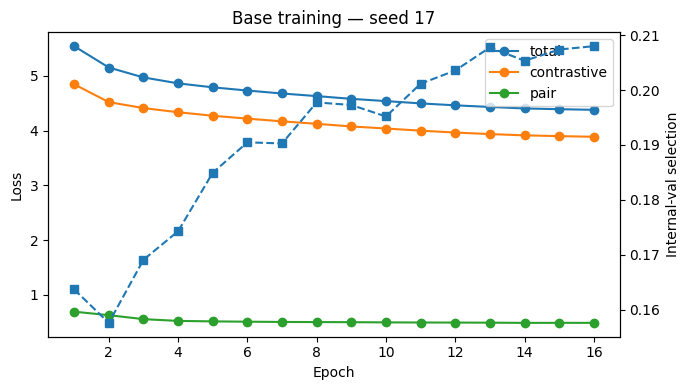

Monitor seed=17 e1:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=17 epoch=01 loss=0.6035 hardValAUROC=0.6554


Monitor seed=17 e2:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=17 epoch=02 loss=0.5631 hardValAUROC=0.6689


Monitor seed=17 e3:   0%|          | 0/529 [00:00<?, ?it/s]

...

monitor seed=17 epoch=14 loss=0.4891 hardValAUROC=0.7226


Monitor seed=17 e15:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=17 epoch=15 loss=0.4862 hardValAUROC=0.7247


Monitor seed=17 e16:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=17 epoch=16 loss=0.4840 hardValAUROC=0.7243


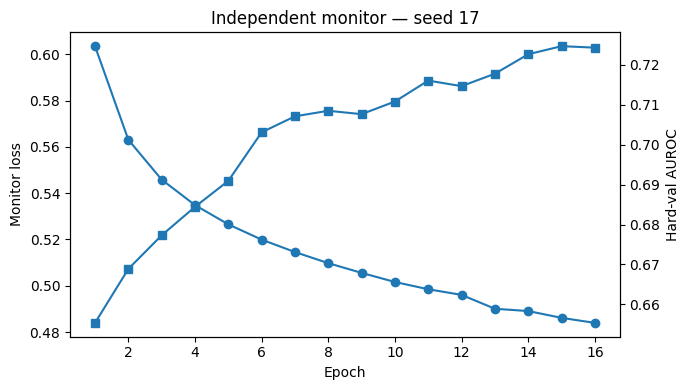

Cache shift noise:0.25:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift noise:0.50:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift noise:0.75:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift noise:1.00:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift blur:0.25:   0%|          | 0/13 [00:00<?, ?it/s]

...

Cache shift brightness:0.50:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift brightness:0.75:   0%|          | 0/13 [00:00<?, ?it/s]

Cache shift brightness:1.00:   0%|          | 0/13 [00:00<?, ?it/s]

Visual-shift external feature cache: BUILT ONCE


,view,n_pair_rows,n_monitor_rows,match_AUROC,cosine_match_AUROC,uncertainty_mismatch_AUROC,monitor_AUROC,base_conflict_AUROC
0,PA,898,898,0.553068,0.708211,0.484477,0.742982,0.553068
1,AP,1606,1606,0.623780,0.752249,0.449327,0.778234,0.623780


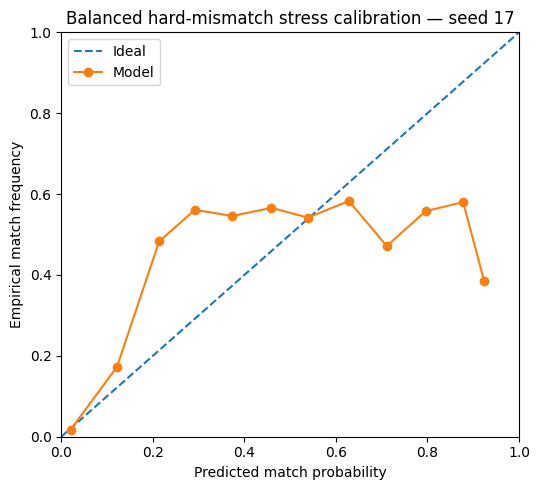

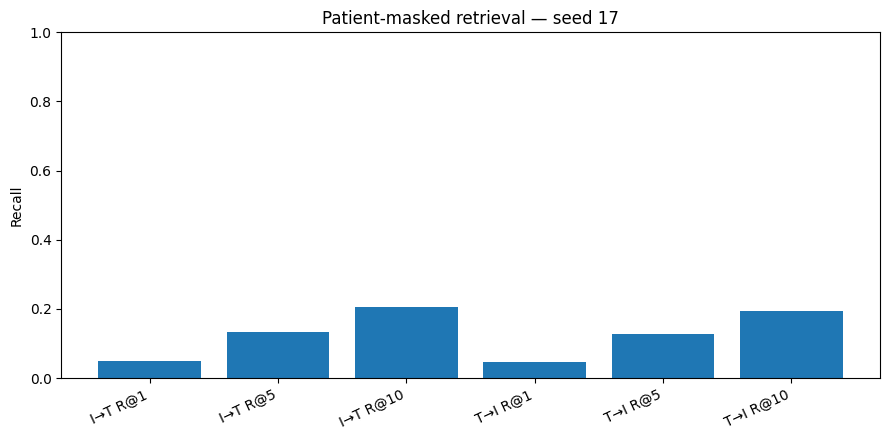

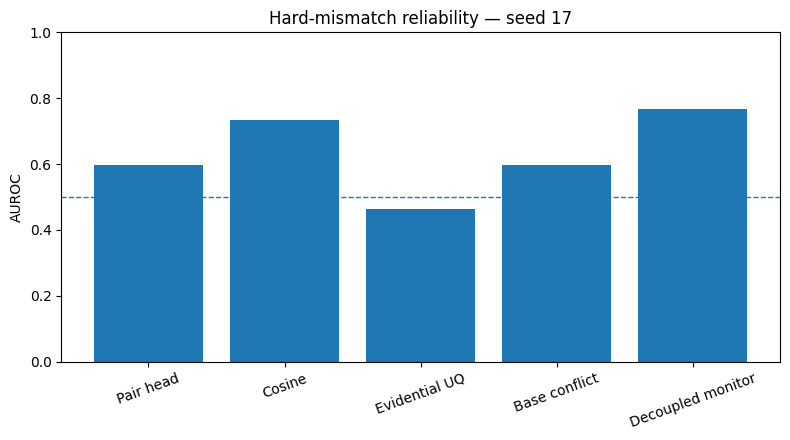

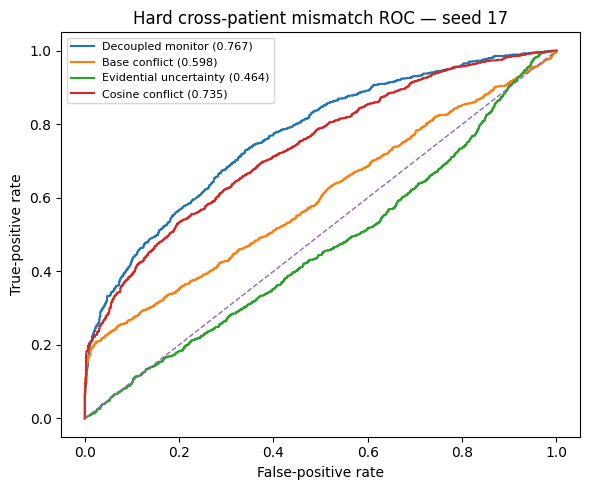

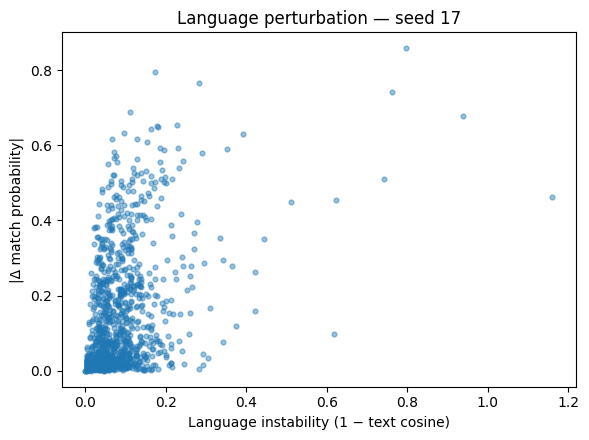

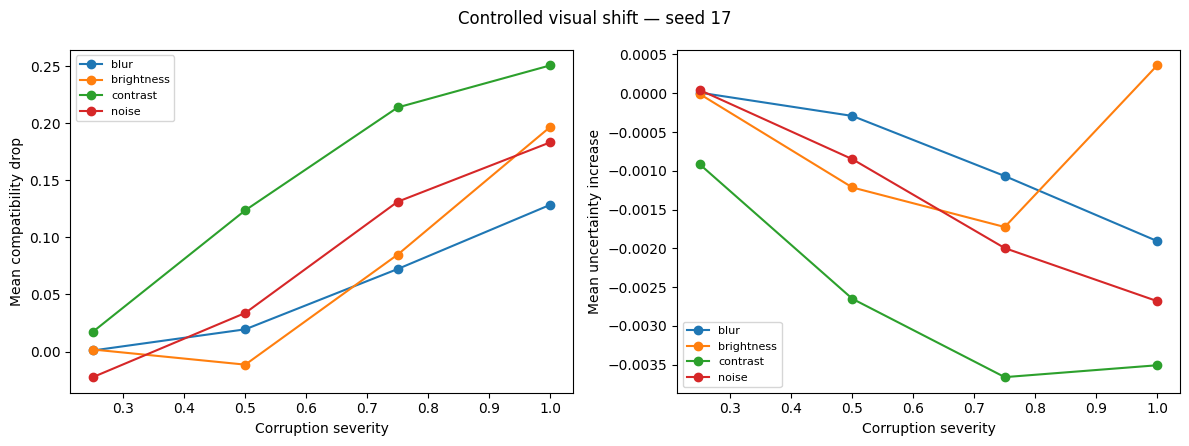

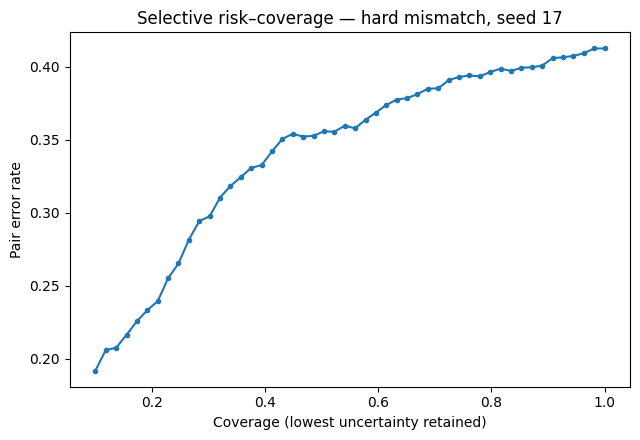

,value
seed,17.000000
best_internal_val_selection,0.207980
pair_threshold_internal_val,0.282222
pair_threshold_internal_val_bacc,0.565600
monitor_threshold_internal_val,0.425758
...,...
hard_monitor_gain_over_uncertainty_AUROC,0.302531
hard_monitor_gain_over_base_conflict_AUROC,0.168722
hard_monitor_gain_over_cosine_AUROC,0.031665
hard_evidential_AURC,0.309386



TRUST-VL-CXR SEED 42


Base seed=42 e1:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=42 epoch=01 loss=5.5900 valR10=(0.038,0.042) hardAUROC=0.563 select=0.1707


Base seed=42 e2:   0%|          | 0/529 [00:00<?, ?it/s]

...

base seed=42 epoch=14 loss=4.4093 valR10=(0.084,0.080) hardAUROC=0.565 select=0.2027


Base seed=42 e15:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=42 epoch=15 loss=4.3881 valR10=(0.083,0.082) hardAUROC=0.576 select=0.2059


Base seed=42 e16:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=42 epoch=16 loss=4.3801 valR10=(0.082,0.080) hardAUROC=0.574 select=0.2044


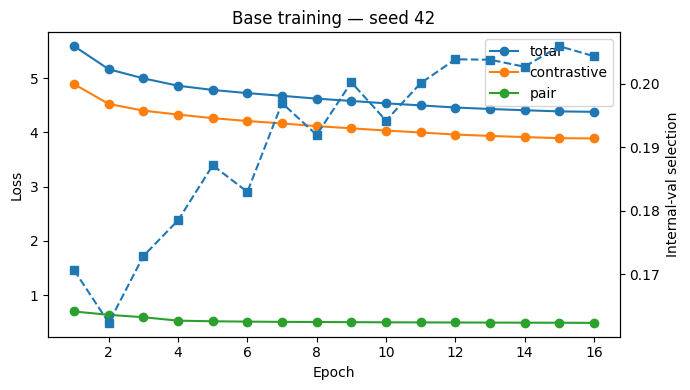

Monitor seed=42 e1:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=42 epoch=01 loss=0.6022 hardValAUROC=0.6473


Monitor seed=42 e2:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=42 epoch=02 loss=0.5638 hardValAUROC=0.6708


Monitor seed=42 e3:   0%|          | 0/529 [00:00<?, ?it/s]

...

monitor seed=42 epoch=14 loss=0.4918 hardValAUROC=0.7205


Monitor seed=42 e15:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=42 epoch=15 loss=0.4886 hardValAUROC=0.7147


Monitor seed=42 e16:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=42 epoch=16 loss=0.4866 hardValAUROC=0.7232


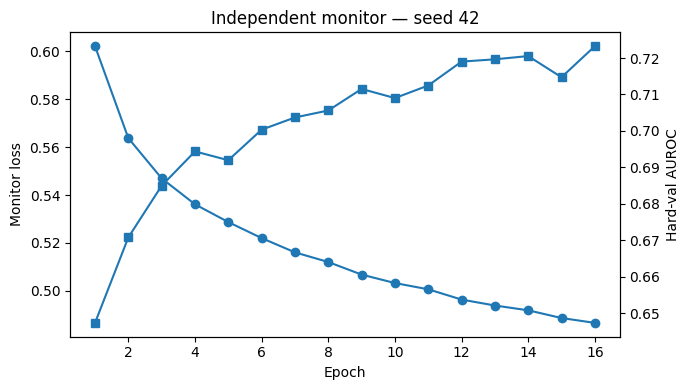

[resume] visual-shift external feature cache


,view,n_pair_rows,n_monitor_rows,match_AUROC,cosine_match_AUROC,uncertainty_mismatch_AUROC,monitor_AUROC,base_conflict_AUROC
0,PA,898,898,0.560776,0.716480,0.443787,0.753230,0.560776
1,AP,1606,1606,0.619763,0.752322,0.411349,0.781718,0.619763


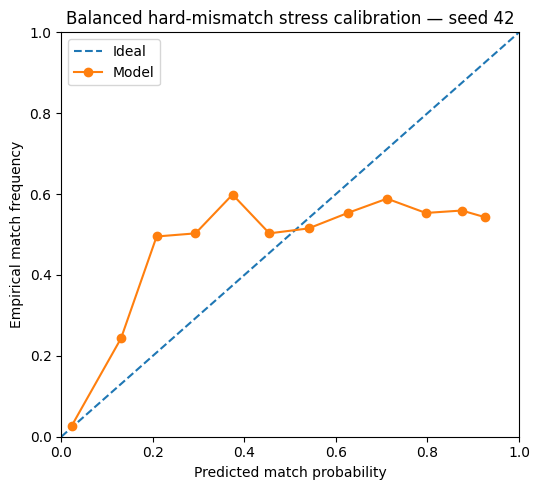

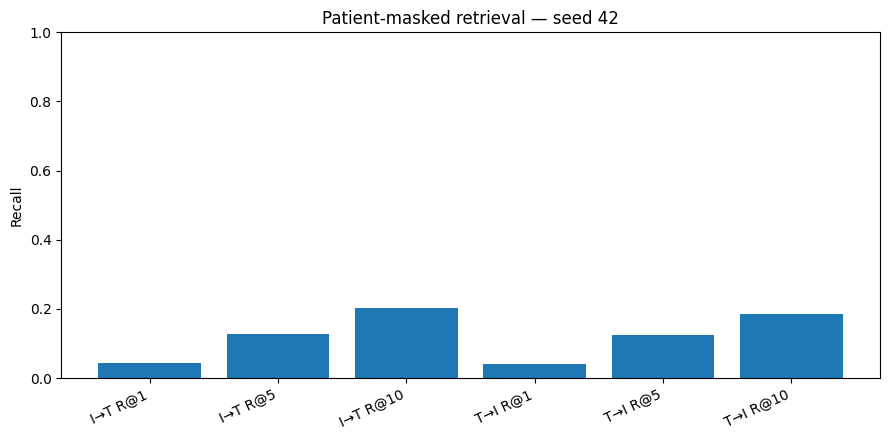

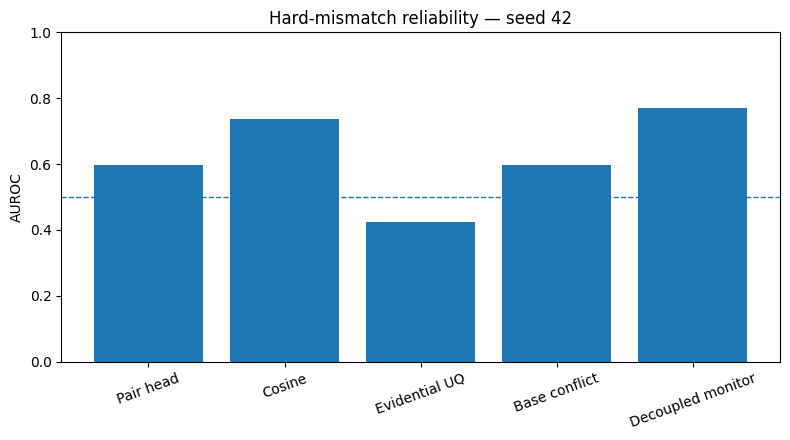

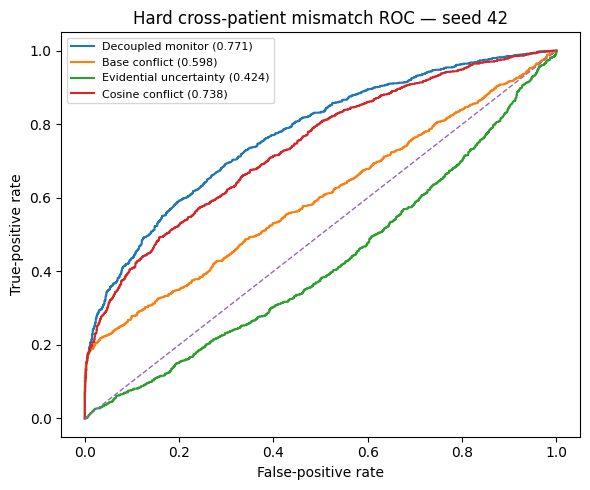

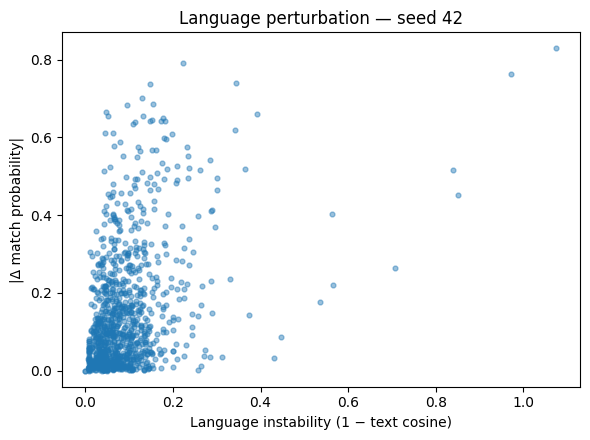

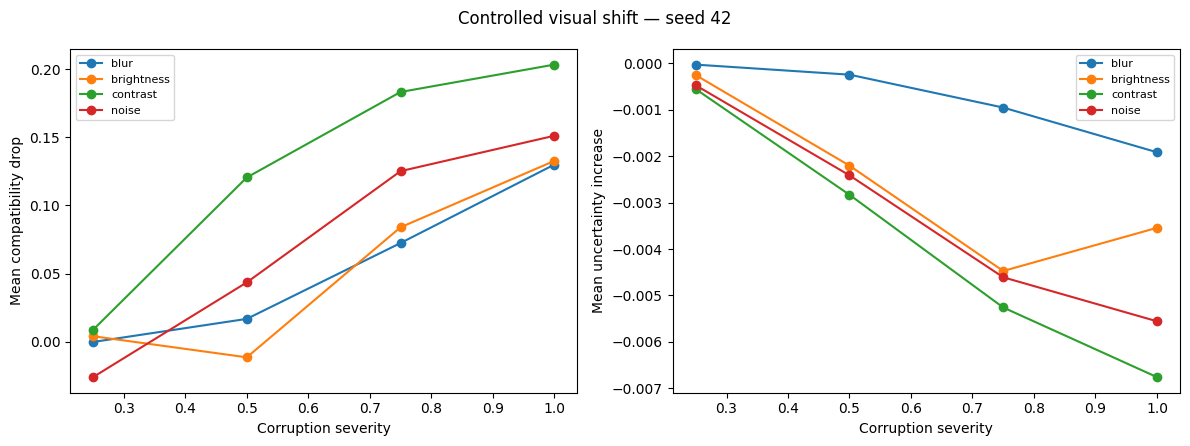

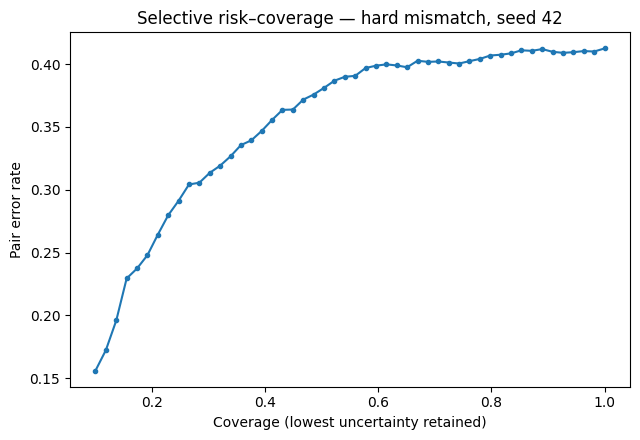

,value
seed,42.000000
best_internal_val_selection,0.205948
pair_threshold_internal_val,0.242626
pair_threshold_internal_val_bacc,0.563914
monitor_threshold_internal_val,0.420808
...,...
hard_monitor_gain_over_uncertainty_AUROC,0.346884
hard_monitor_gain_over_base_conflict_AUROC,0.173257
hard_monitor_gain_over_cosine_AUROC,0.033593
hard_evidential_AURC,0.321226



TRUST-VL-CXR SEED 73


Base seed=73 e1:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=73 epoch=01 loss=5.5540 valR10=(0.037,0.034) hardAUROC=0.541 select=0.1618


Base seed=73 e2:   0%|          | 0/529 [00:00<?, ?it/s]

...

base seed=73 epoch=14 loss=4.4082 valR10=(0.083,0.078) hardAUROC=0.574 select=0.2035


Base seed=73 e15:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=73 epoch=15 loss=4.3911 valR10=(0.083,0.077) hardAUROC=0.572 select=0.2029


Base seed=73 e16:   0%|          | 0/529 [00:00<?, ?it/s]

base seed=73 epoch=16 loss=4.3766 valR10=(0.083,0.078) hardAUROC=0.573 select=0.2035


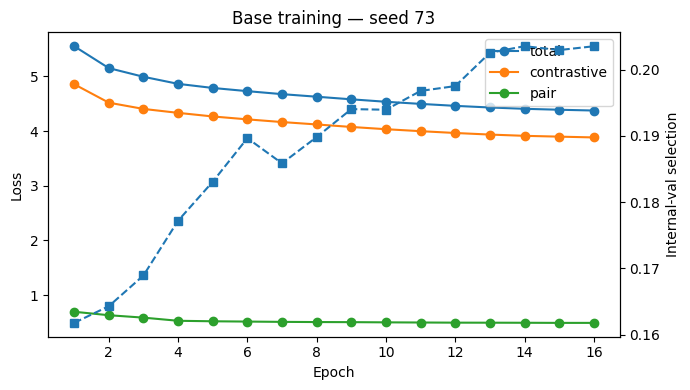

Monitor seed=73 e1:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=73 epoch=01 loss=0.6051 hardValAUROC=0.6470


Monitor seed=73 e2:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=73 epoch=02 loss=0.5634 hardValAUROC=0.6610


Monitor seed=73 e3:   0%|          | 0/529 [00:00<?, ?it/s]

...

monitor seed=73 epoch=14 loss=0.4888 hardValAUROC=0.7201


Monitor seed=73 e15:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=73 epoch=15 loss=0.4863 hardValAUROC=0.7245


Monitor seed=73 e16:   0%|          | 0/529 [00:00<?, ?it/s]

monitor seed=73 epoch=16 loss=0.4842 hardValAUROC=0.7273


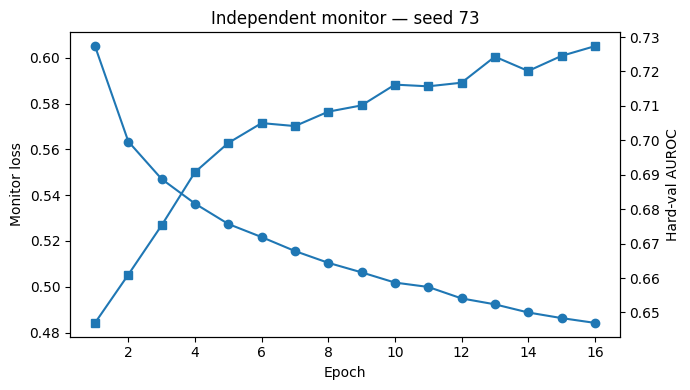

[resume] visual-shift external feature cache


,view,n_pair_rows,n_monitor_rows,match_AUROC,cosine_match_AUROC,uncertainty_mismatch_AUROC,monitor_AUROC,base_conflict_AUROC
0,PA,898,898,0.551019,0.710552,0.521113,0.737070,0.551019
1,AP,1606,1606,0.611142,0.749845,0.517380,0.788268,0.611142


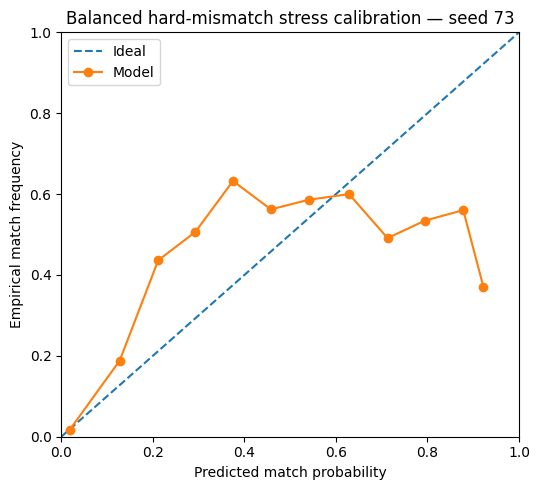

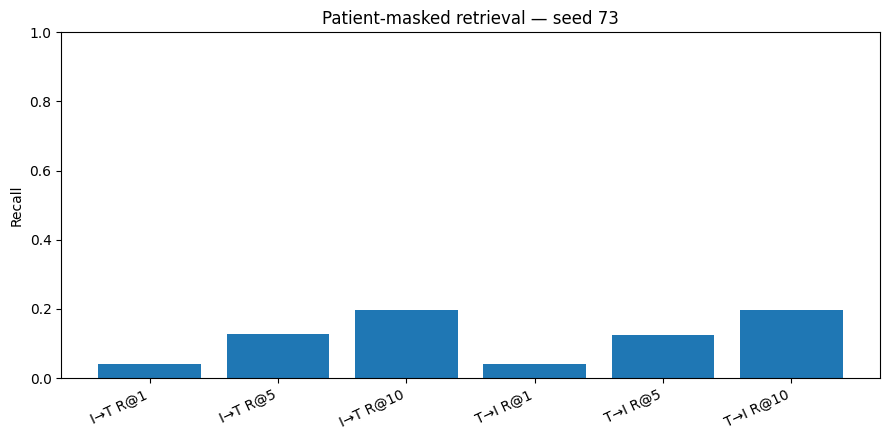

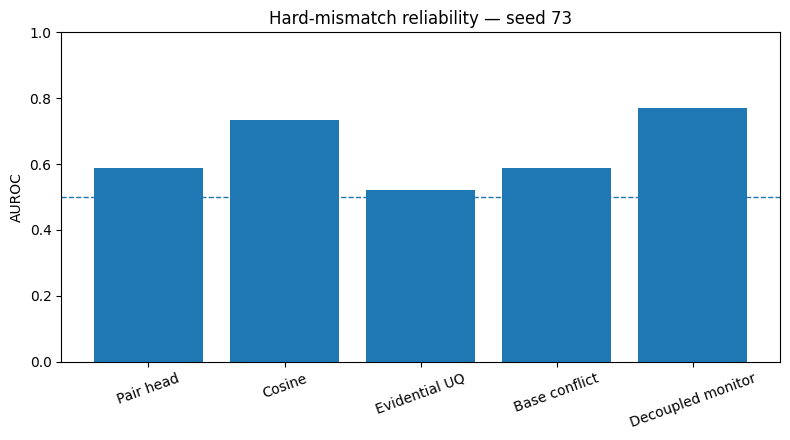

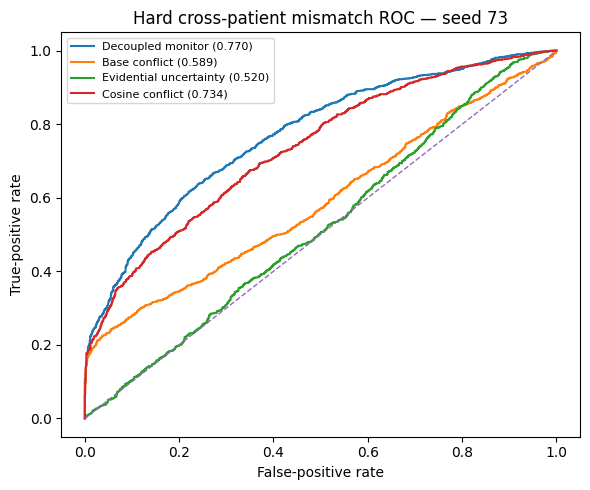

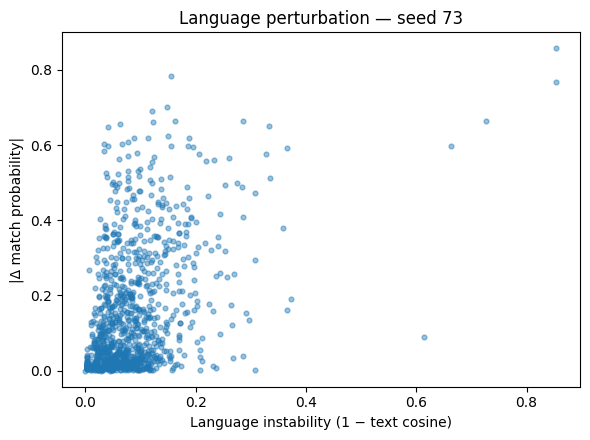

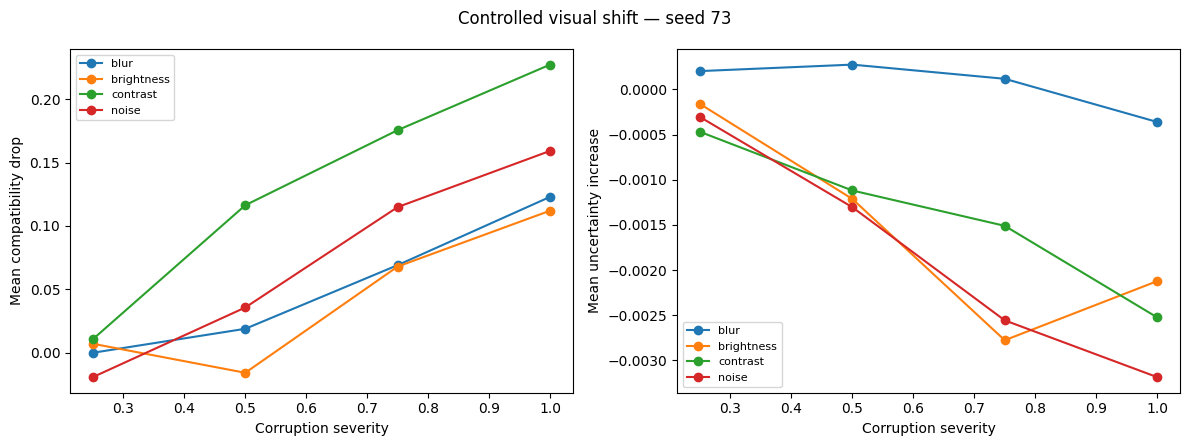

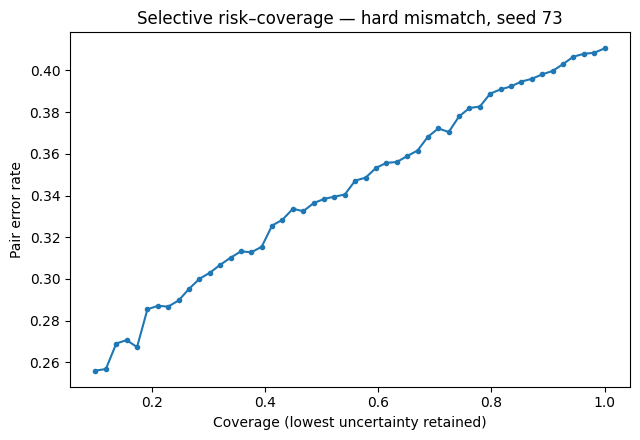

,value
seed,73.000000
best_internal_val_selection,0.203527
pair_threshold_internal_val,0.287172
pair_threshold_internal_val_bacc,0.562164
monitor_threshold_internal_val,0.401010
...,...
hard_monitor_gain_over_uncertainty_AUROC,0.250156
hard_monitor_gain_over_base_conflict_AUROC,0.181529
hard_monitor_gain_over_cosine_AUROC,0.036569
hard_evidential_AURC,0.308589


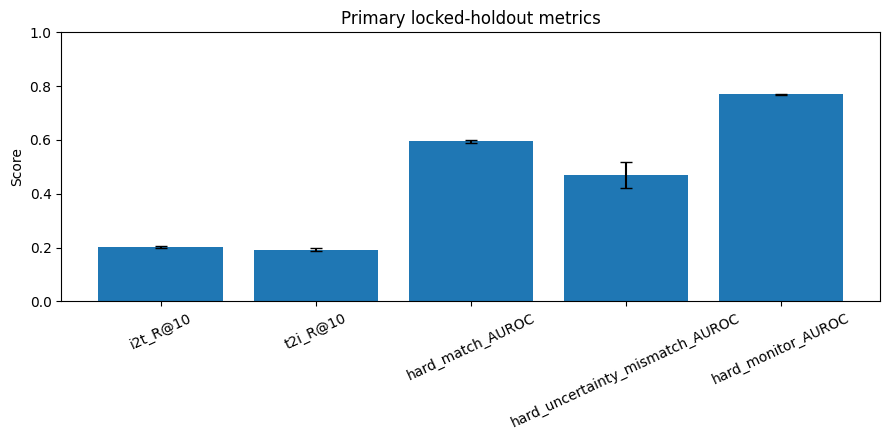

In [24]:
# ============================================================================
# 16. FULL LOCKED-HOLDOUT EXPERIMENT
# ============================================================================
seed_rows=[];all_bootstrap=[]

for seed in EXP["seeds"]:
    print(
        "\n"
        + "=" * 92
    )

    print(
        "TRUST-VL-CXR SEED",
        seed,
    )

    print(
        "=" * 92
    )

    if seed_is_complete(
        seed
    ):
        print(
            f"[resume] seed {seed} already complete; "
            "loading paper artifacts without recomputation."
        )

        metrics, boot = load_completed_seed(
            seed
        )

        seed_rows.append(
            metrics
        )

        all_bootstrap.append(
            boot
        )

        persist_partial_results(
            seed_rows,
            all_bootstrap,
        )

        continue

    base,best_selection,base_history=train_base(seed)
    monitor,monitor_threshold,monitor_val_auc,monitor_history,base_hash=train_monitor(base,seed)

    # Internal-validation thresholds: hard mismatch only.
    val_idx=fixed_eval_indices("internal_val",CFG.pair_selection_cap,CFG.validation_subset_seed+1)
    val_hard=pair_outputs(
        base,"internal_val",indices=val_idx,negative_mode="hard_text",
        seed=CFG.validation_mismatch_seed
    )
    pair_threshold,val_bacc=best_balanced_threshold(
        val_hard.label_match,
        val_hard.match_prob,
    )

    pair_calibrator = fit_platt_calibrator(
        val_hard.label_match,
        val_hard.match_prob,
    )

    # Monitor calibration is fit on the exact internal-validation hard pairs
    # used for monitor threshold selection; the locked holdout is untouched.
    _vm_internal, _vf_internal = evaluate_monitor(
        base,
        monitor,
        "internal_val",
        "hard_text",
        CFG.validation_mismatch_seed,
        indices=fixed_eval_indices(
            "internal_val",
            CFG.pair_selection_cap,
            CFG.validation_subset_seed + 2,
        ),
    )

    monitor_calibrator = fit_platt_calibrator(
        _vf_internal.label_conflict,
        _vf_internal.monitor_score,
    )

    # -------------------- LOCKED HOLDOUT --------------------
    i2t,t2i=retrieval_ranks(base,"holdout",mask_same_patient=True)
    exact_i2t,exact_t2i=retrieval_ranks(base,"holdout",mask_same_patient=False)
    retrieval={
        **rank_metrics(i2t,"i2t"),**rank_metrics(t2i,"t2i"),
        **rank_metrics(exact_i2t,"exact_i2t"),**rank_metrics(exact_t2i,"exact_t2i"),
    }

    hard_pair=pair_outputs(
        base,"holdout",negative_mode="hard_text",seed=CFG.holdout_mismatch_seed
    )
    random_pair=pair_outputs(
        base,"holdout",negative_mode="random",seed=CFG.holdout_mismatch_seed
    )
    hard_pair_metrics=pair_metrics_from_frame(
        hard_pair,
        pair_threshold,
        prefix="hard_",
    )

    random_pair_metrics=pair_metrics_from_frame(
        random_pair,
        pair_threshold,
        prefix="random_",
    )

    hard_pair_metrics.update(
        calibrated_binary_metrics(
            hard_pair.label_match.to_numpy(
                int
            ),
            hard_pair.match_prob.to_numpy(
                float
            ),
            pair_calibrator,
            prefix="hard_",
        )
    )

    random_pair_metrics.update(
        calibrated_binary_metrics(
            random_pair.label_match.to_numpy(
                int
            ),
            random_pair.match_prob.to_numpy(
                float
            ),
            pair_calibrator,
            prefix="random_",
        )
    )

    hard_mon_metrics,hard_mon_frame=evaluate_monitor(
        base,monitor,"holdout","hard_text",CFG.holdout_mismatch_seed,monitor_threshold
    )
    hard_mon_metrics={f"hard_{k}":v for k,v in hard_mon_metrics.items()}
    random_mon_metrics,random_mon_frame=evaluate_monitor(
        base,monitor,"holdout","random",CFG.holdout_mismatch_seed,monitor_threshold
    )
    random_mon_metrics={
        f"random_{k}":
        v
        for k, v
        in random_mon_metrics.items()
    }

    # Additional calibration reporting for the decoupled monitor.
    hard_monitor_calibrated = apply_platt_calibrator(
        hard_mon_frame.monitor_score,
        monitor_calibrator,
    )

    random_monitor_calibrated = apply_platt_calibrator(
        random_mon_frame.monitor_score,
        monitor_calibrator,
    )

    hard_monitor_ece, _ = expected_calibration_error(
        hard_mon_frame.label_conflict,
        hard_monitor_calibrated,
    )

    random_monitor_ece, _ = expected_calibration_error(
        random_mon_frame.label_conflict,
        random_monitor_calibrated,
    )

    hard_mon_metrics[
        "hard_monitor_calibrated_Brier"
    ] = float(
        brier_score_loss(
            hard_mon_frame.label_conflict,
            hard_monitor_calibrated,
        )
    )

    hard_mon_metrics[
        "hard_monitor_calibrated_ECE"
    ] = float(
        hard_monitor_ece
    )

    random_mon_metrics[
        "random_monitor_calibrated_Brier"
    ] = float(
        brier_score_loss(
            random_mon_frame.label_conflict,
            random_monitor_calibrated,
        )
    )

    random_mon_metrics[
        "random_monitor_calibrated_ECE"
    ] = float(
        random_monitor_ece
    )

    language_metrics,language_frame=language_analysis(base)
    visual_metrics,visual_frame=visual_shift_analysis(base)

    retrieval_frame=FEATURES["holdout"][3][["subject_id","study_id","view"]].copy()
    retrieval_frame["i2t_rank"]=i2t;retrieval_frame["t2i_rank"]=t2i
    retrieval_frame["exact_i2t_rank"]=exact_i2t;retrieval_frame["exact_t2i_rank"]=exact_t2i

    metrics={
        "seed":int(seed),"best_internal_val_selection":best_selection,
        "pair_threshold_internal_val":pair_threshold,
        "pair_threshold_internal_val_bacc":val_bacc,
        "monitor_threshold_internal_val":monitor_threshold,
        "monitor_best_internal_val_AUROC":
        monitor_val_auc,
        "pair_platt_coef":
        float(
            pair_calibrator[
                "coef"
            ]
        ),
        "pair_platt_intercept":
        float(
            pair_calibrator[
                "intercept"
            ]
        ),
        "monitor_platt_coef":
        float(
            monitor_calibrator[
                "coef"
            ]
        ),
        "monitor_platt_intercept":
        float(
            monitor_calibrator[
                "intercept"
            ]
        ),
        **retrieval,**hard_pair_metrics,**random_pair_metrics,
        **hard_mon_metrics,**random_mon_metrics,**language_metrics,**visual_metrics,
    }
    metrics["hard_monitor_gain_over_uncertainty_AUROC"]=(
        metrics["hard_monitor_AUROC"]-metrics["hard_uncertainty_conflict_AUROC"]
    )
    metrics["hard_monitor_gain_over_base_conflict_AUROC"]=(
        metrics["hard_monitor_AUROC"]-metrics["hard_base_conflict_AUROC"]
    )
    metrics["hard_monitor_gain_over_cosine_AUROC"]=(
        metrics["hard_monitor_AUROC"]-metrics["hard_cosine_conflict_AUROC"]
    )

    run=OUT/f"seed_{seed}";run.mkdir(parents=True,exist_ok=True)
    retrieval_frame.to_csv(run/"holdout_retrieval.csv",index=False)
    hard_pair.to_csv(run/"holdout_hard_pair_predictions.csv",index=False)
    random_pair.to_csv(run/"holdout_random_pair_predictions.csv",index=False)
    hard_mon_frame.to_csv(run/"holdout_hard_monitor_predictions.csv",index=False)
    random_mon_frame.to_csv(run/"holdout_random_monitor_predictions.csv",index=False)
    language_frame.to_csv(run/"holdout_language_perturbation.csv",index=False)
    visual_frame.to_csv(run/"visual_shift_records.csv",index=False)

    subgroup=subgroup_metrics(
        hard_pair,
        hard_mon_frame,
    )

    if int(
        subgroup[
            "n_pair_rows"
        ].sum()
    ) != len(
        hard_pair
    ):
        raise RuntimeError(
            "Projection-view subgroup accounting does not cover all hard pair rows."
        )

    if int(
        subgroup[
            "n_monitor_rows"
        ].sum()
    ) != len(
        hard_mon_frame
    ):
        raise RuntimeError(
            "Projection-view subgroup accounting does not cover all monitor rows."
        )

    subgroup.to_csv(
        run
        / "projection_view_subgroups_hard.csv",
        index=False,
    )

    display(
        subgroup
    )
    (run/"holdout_metrics.json").write_text(json.dumps(metrics,indent=2),encoding="utf-8")

    # Clustered query bootstrap: candidate pool is fixed by design.
    br=patient_cluster_bootstrap(
        retrieval_frame,{
            "i2t_R@10":lambda d:np.mean(d.i2t_rank<=10),
            "t2i_R@10":lambda d:np.mean(d.t2i_rank<=10),
            "i2t_MRR":lambda d:np.mean(1/d.i2t_rank),
            "t2i_MRR":lambda d:np.mean(1/d.t2i_rank),
        },EXP["bootstrap_reps"],seed+7000,
        scope="patient-clustered queries; fixed locked candidate pool"
    );br["family"]="retrieval"

    bp=patient_cluster_bootstrap(
        hard_pair,{
            "hard_match_AUROC":lambda d:roc_auc_score(d.label_match,d.match_prob),
            "hard_match_AUPRC":lambda d:average_precision_score(d.label_match,d.match_prob),
            "hard_uncertainty_mismatch_AUROC":lambda d:roc_auc_score(1-d.label_match,d.uncertainty),
            "hard_cosine_match_AUROC":lambda d:roc_auc_score(d.label_match,d.projected_cosine),
        },EXP["bootstrap_reps"],seed+7100,
        scope="patient-cluster bootstrap on balanced hard-mismatch stress set"
    );bp["family"]="pair_reliability"

    bm=patient_cluster_bootstrap(
        hard_mon_frame,{
            "hard_monitor_AUROC":lambda d:roc_auc_score(d.label_conflict,d.monitor_score),
            "hard_base_conflict_AUROC":lambda d:roc_auc_score(d.label_conflict,d.base_conflict_score),
            "hard_uncertainty_conflict_AUROC":lambda d:roc_auc_score(d.label_conflict,d.base_uncertainty),
            "hard_cosine_conflict_AUROC":lambda d:roc_auc_score(d.label_conflict,d.cosine_conflict_score),
            "monitor_minus_uncertainty":lambda d:roc_auc_score(d.label_conflict,d.monitor_score)-roc_auc_score(d.label_conflict,d.base_uncertainty),
            "monitor_minus_base":lambda d:roc_auc_score(d.label_conflict,d.monitor_score)-roc_auc_score(d.label_conflict,d.base_conflict_score),
            "monitor_minus_cosine":lambda d:roc_auc_score(d.label_conflict,d.monitor_score)-roc_auc_score(d.label_conflict,d.cosine_conflict_score),
        },EXP["bootstrap_reps"],seed+7200,
        scope="patient-cluster bootstrap on identical hard-mismatch pairs"
    );bm["family"]="decoupled_monitor"

    boots=[br,bp,bm]
    if not language_frame.empty:
        bl=patient_cluster_bootstrap(
            language_frame,{
                "mean_text_paraphrase_cos":lambda d:d.text_paraphrase_cos.mean(),
                "mean_abs_match_prob_shift":lambda d:d.match_prob_shift.mean(),
            },EXP["bootstrap_reps"],seed+7300,
            scope="patient-cluster bootstrap on aligned text_augment subset"
        );bl["family"]="language";boots.append(bl)
    boot=pd.concat(boots,ignore_index=True);boot["seed"]=seed
    boot.to_csv(run/"patient_cluster_bootstrap_ci.csv",index=False);all_bootstrap.append(boot)

    cal=plot_calibration(hard_pair,seed);cal.to_csv(run/"hard_calibration_bins.csv",index=False)
    curve=risk_coverage_curve(
        hard_pair.label_match,
        hard_pair.match_prob,
        hard_pair.uncertainty,
        pair_threshold,
    )

    curve.to_csv(
        run
        / "hard_risk_coverage.csv",
        index=False,
    )

    # Monitor self-selective risk: uncertainty is binary entropy of the
    # validation-calibrated conflict probability.
    monitor_curve = risk_coverage_curve(
        hard_mon_frame.label_conflict,
        hard_monitor_calibrated,
        entropy_binary(
            hard_monitor_calibrated
        ),
        0.5,
    )

    monitor_curve.to_csv(
        run
        / "hard_monitor_risk_coverage.csv",
        index=False,
    )

    metrics[
        "hard_evidential_AURC"
    ] = area_under_risk_coverage(
        curve
    )

    metrics[
        "hard_monitor_self_AURC"
    ] = area_under_risk_coverage(
        monitor_curve
    )

    # Re-write metrics after the additional selective-prediction fields.
    (
        run
        / "holdout_metrics.json"
    ).write_text(
        json.dumps(
            metrics,
            indent=2,
        ),
        encoding="utf-8",
    )

    plot_retrieval(metrics,seed);plot_reliability(metrics,seed);plot_conflict_roc(hard_mon_frame,seed)
    plot_language(language_frame,seed)
    vagg=plot_visual(visual_frame,seed);vagg.to_csv(run/"visual_shift_summary.csv",index=False)
    plot_risk_coverage(curve,seed)

    seed_rows.append(
        metrics
    )

    display(
        pd.DataFrame(
            [
                metrics
            ]
        ).T.rename(
            columns={
                0:
                "value"
            }
        )
    )

    (
        run
        / "seed_complete.json"
    ).write_text(
        json.dumps(
            {
                "seed":
                int(
                    seed
                ),
                "core_protocol":
                CFG.protocol,
                "analysis_revision":
                CFG.analysis_revision,
                "completed":
                True,
                "required_files":
                list(
                    REQUIRED_SEED_FILES[
                        :-1
                    ]
                ),
            },
            indent=2,
        ),
        encoding="utf-8",
    )

    persist_partial_results(
        seed_rows,
        all_bootstrap,
    )

    del base,monitor
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

completed_seeds = [
    int(
        seed
    )
    for seed
    in EXP[
        "seeds"
    ]
    if seed_is_complete(
        seed
    )
]

if set(
    completed_seeds
) != set(
    map(
        int,
        EXP[
            "seeds"
        ],
    )
):
    persist_partial_results(
        seed_rows,
        all_bootstrap,
    )

    raise RuntimeError(
        "Paper profile is incomplete. "
        f"Completed seeds={completed_seeds}; "
        f"expected={list(EXP['seeds'])}. "
        "Rerun this cell/notebook: completed seed checkpoints and artifacts "
        "will be reused automatically."
    )

results=pd.DataFrame(seed_rows)
results.to_csv(
    OUT/"seed_level_results.csv",
    index=False,
)

if all_bootstrap:
    pd.concat(all_bootstrap,ignore_index=True).to_csv(OUT/"bootstrap_all_seeds.csv",index=False)
numeric=[c for c in results.select_dtypes(include=[np.number]).columns if c!="seed"]
aggregate=pd.DataFrame({
    "metric":numeric,
    "mean":[results[c].mean() for c in numeric],
    "std":[results[c].std(ddof=1) if len(results)>1 else np.nan for c in numeric],
})
aggregate.to_csv(OUT/"aggregate_results.csv",index=False)

primary=["i2t_R@10","t2i_R@10","hard_match_AUROC","hard_uncertainty_mismatch_AUROC","hard_monitor_AUROC"]
fig,ax=plt.subplots(figsize=(9,4.5))
ax.bar(primary,[results[m].mean() for m in primary],
       yerr=[results[m].std(ddof=1) if len(results)>1 else 0 for m in primary],
       capsize=4)
ax.set_ylim(0,1);ax.set_ylabel("Score");ax.set_title("Primary locked-holdout metrics")
ax.tick_params(axis="x",rotation=25);fig.tight_layout()
fig.savefig(FIG/"11_primary_summary.png",dpi=200);plt.show();plt.close(fig)


## 19. Reproducibility export and ZIP creation


In [25]:
# ============================================================================
# 17. COMPACT REPRODUCIBILITY EXPORT + ZIP
# ============================================================================
for p in list(EXPORT.iterdir()):
    shutil.rmtree(p) if p.is_dir() else p.unlink()

for name in (
    "environment.json","protocol_config.json","dataset_provenance.json",
    "encoder_provenance.json","data_audit.json","feature_audit.json",
    "seed_level_results.csv","aggregate_results.csv","bootstrap_all_seeds.csv",
    "manifest_index_train.csv","manifest_index_internal_val.csv","manifest_index_holdout.csv",
    "pip_freeze.txt",
):
    src=OUT/name
    if src.exists(): shutil.copy2(src,EXPORT/src.name)

for extra in (
    Path("/kaggle/working/trust_vl_cxr_setup_audit.json"),
    Path("/kaggle/working/trust_vl_cxr_environment_constraints.txt"),
):
    if extra.exists(): shutil.copy2(extra,EXPORT/extra.name)

shutil.copytree(FIG,EXPORT/"figures",dirs_exist_ok=True)

# Derived outputs only. Remove raw IDs from the compact export copies.
for seed in EXP["seeds"]:
    src=OUT/f"seed_{seed}";dst=EXPORT/f"seed_{seed}";dst.mkdir(parents=True,exist_ok=True)
    for item in src.iterdir():
        if not item.is_file(): continue
        if item.suffix.lower()==".csv":
            df=pd.read_csv(item)
            drop=[c for c in ("subject_id","study_id","report_subject_id","report_study_id","image_path") if c in df.columns]
            df=df.drop(columns=drop)
            df.insert(0,"row_id",np.arange(len(df)))
            df.to_csv(dst/item.name,index=False)
        else:
            shutil.copy2(item,dst/item.name)

README=f"""TRUST-VL-CXR v5 results package
Protocol: {CFG.protocol}
Profile: {PROFILE}
Dataset: {CFG.dataset_slug}

Scope
- CXR-report retrieval and controlled mismatch reliability.
- NOT lesion segmentation.
- Provided validate CSV is locked holdout.
- Hard cross-patient report mismatch is the primary stress test; random mismatch is secondary.
- The decoupled monitor has its own projections of frozen external features.
- It does not consume base probability or evidential uncertainty.
- Base model parameters are verified unchanged during monitor training.
- Calibration/Brier metrics are for a balanced synthetic stress set, not clinical prevalence calibration.
- Retrieval bootstrap resamples patient-clustered queries with a fixed candidate pool.
- text_augment is evaluation-only.
- No raw reports, raw CXRs, or cached embeddings are included.
- Kaggle data card license is reported as Unknown; review dataset terms before redistribution/publication.
"""
(EXPORT/"README_RESULTS.txt").write_text(README,encoding="utf-8")

zip_base=Path("/kaggle/working")/f"TRUST_VL_CXR_{PROFILE}_RESULTS"
zip_path=Path(shutil.make_archive(str(zip_base),"zip",root_dir=EXPORT))
print("ZIP:",zip_path, f"({zip_path.stat().st_size/(1024**2):.2f} MB)")
display(FileLink(str(zip_path)))


ZIP: /kaggle/working/TRUST_VL_CXR_paper_RESULTS.zip (32.09 MB)


/kaggle/working/TRUST_VL_CXR_paper_RESULTS.zip

## 20. Final results dashboard


## Primary locked-holdout results

,seed,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MRR,t2i_R@1,t2i_R@5,t2i_R@10,t2i_MRR,hard_match_AUROC,...,hard_monitor_gain_over_uncertainty_AUROC,hard_monitor_gain_over_base_conflict_AUROC,hard_monitor_gain_over_cosine_AUROC,random_match_AUROC,random_monitor_AUROC,mean_text_paraphrase_cos,mean_abs_match_prob_shift,language_instability_vs_match_shift_spearman,visual_drift_vs_compatibility_drop_spearman,visual_drift_vs_uncertainty_delta_spearman
0,17,0.0487,0.1334,0.2061,0.1026,0.0471,0.1270,0.1933,0.0992,0.5979,...,0.3025,0.1687,0.0317,0.8217,0.8621,0.9088,0.1544,0.3522,0.3435,-0.2272
1,42,0.0439,0.1270,0.2021,0.0965,0.0399,0.1238,0.1869,0.0953,0.5979,...,0.3469,0.1733,0.0336,0.8205,0.8607,0.9092,0.1473,0.3481,0.3095,-0.3693
2,73,0.0423,0.1278,0.1965,0.0980,0.0423,0.1238,0.1965,0.0944,0.5886,...,0.2502,0.1815,0.0366,0.8154,0.8674,0.9120,0.1531,0.3781,0.2861,-0.2538


## Across-seed aggregation

,metric,mean,std
0,best_internal_val_selection,0.20582,0.00223
1,pair_threshold_internal_val,0.27067,0.02442
2,pair_threshold_internal_val_bacc,0.56389,0.00172
3,monitor_threshold_internal_val,0.41586,0.01310
4,monitor_best_internal_val_AUROC,0.72508,0.00208
...,...,...,...
70,hard_monitor_gain_over_uncertainty_AUROC,0.29986,0.04842
71,hard_monitor_gain_over_base_conflict_AUROC,0.17450,0.00649
72,hard_monitor_gain_over_cosine_AUROC,0.03394,0.00247
73,hard_evidential_AURC,0.31307,0.00708


## Clustered 95% uncertainty intervals

,metric,estimate,ci95_low,ci95_high,n_boot,cluster_unit,bootstrap_scope,family,seed
0,i2t_R@10,0.2061,0.1797,0.2334,2000,subject_id,patient-clustered queries; fixed locked candid...,retrieval,17
1,t2i_R@10,0.1933,0.1668,0.2209,2000,subject_id,patient-clustered queries; fixed locked candid...,retrieval,17
2,i2t_MRR,0.1026,0.0904,0.1161,2000,subject_id,patient-clustered queries; fixed locked candid...,retrieval,17
3,t2i_MRR,0.0992,0.0844,0.1165,2000,subject_id,patient-clustered queries; fixed locked candid...,retrieval,17
4,hard_match_AUROC,0.5979,0.5769,0.6175,2000,subject_id,patient-cluster bootstrap on balanced hard-mis...,pair_reliability,17
5,hard_match_AUPRC,0.5512,0.5364,0.5689,2000,subject_id,patient-cluster bootstrap on balanced hard-mis...,pair_reliability,17
6,hard_uncertainty_mismatch_AUROC,0.4641,0.4497,0.4791,2000,subject_id,patient-cluster bootstrap on balanced hard-mis...,pair_reliability,17
7,hard_cosine_match_AUROC,0.7349,0.7156,0.7532,2000,subject_id,patient-cluster bootstrap on balanced hard-mis...,pair_reliability,17
8,hard_monitor_AUROC,0.7666,0.7453,0.7846,2000,subject_id,patient-cluster bootstrap on identical hard-mi...,decoupled_monitor,17
9,hard_base_conflict_AUROC,0.5979,0.5770,0.6157,2000,subject_id,patient-cluster bootstrap on identical hard-mi...,decoupled_monitor,17


## Saved figures

01_dataset_protocol.png


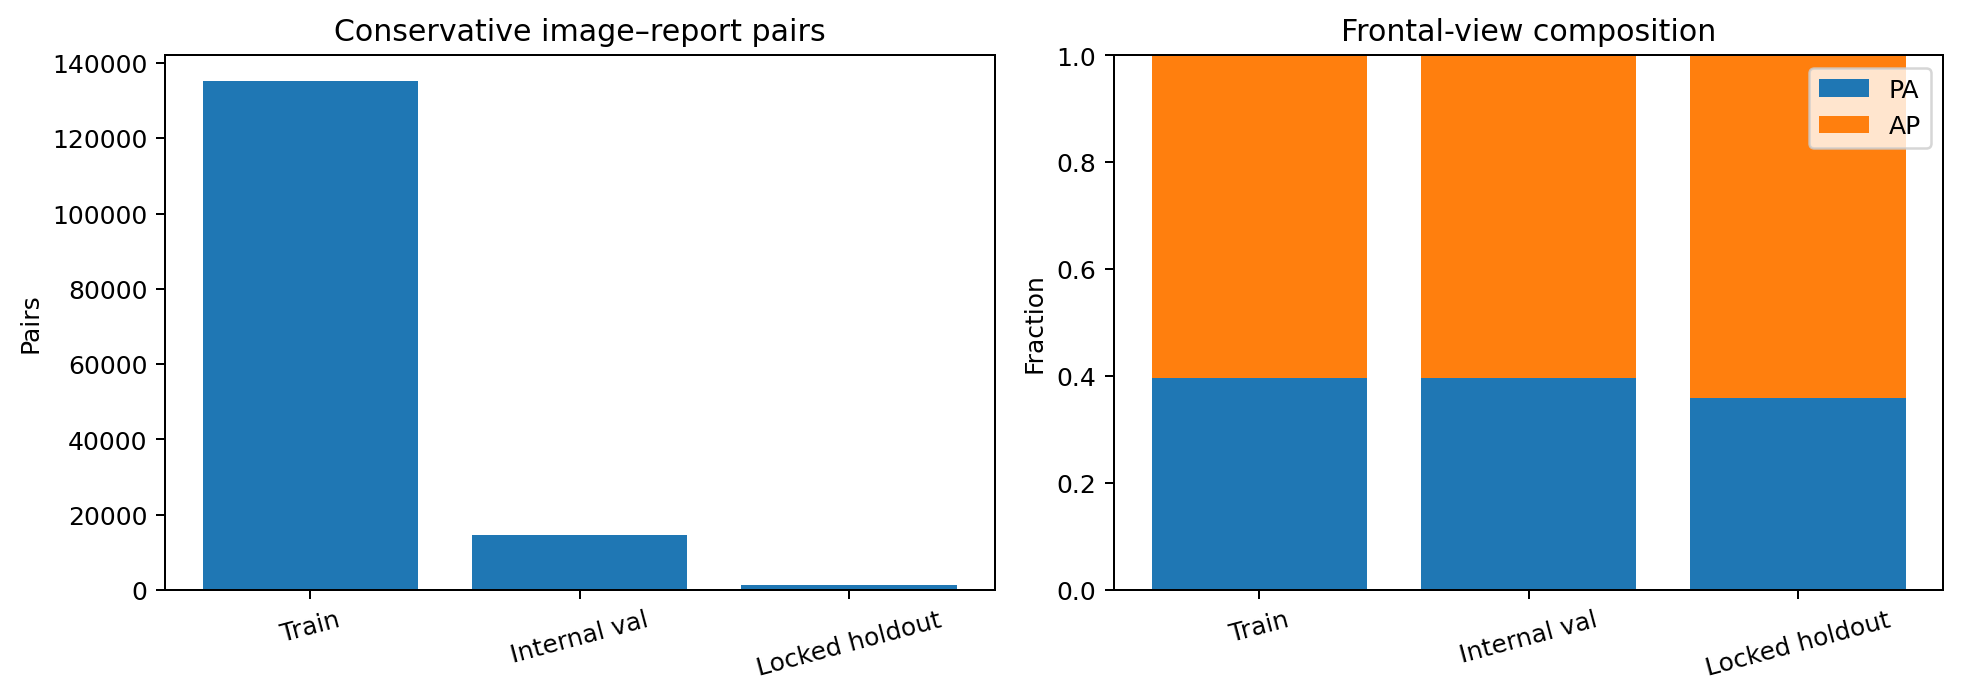

02_base_training_seed17.png


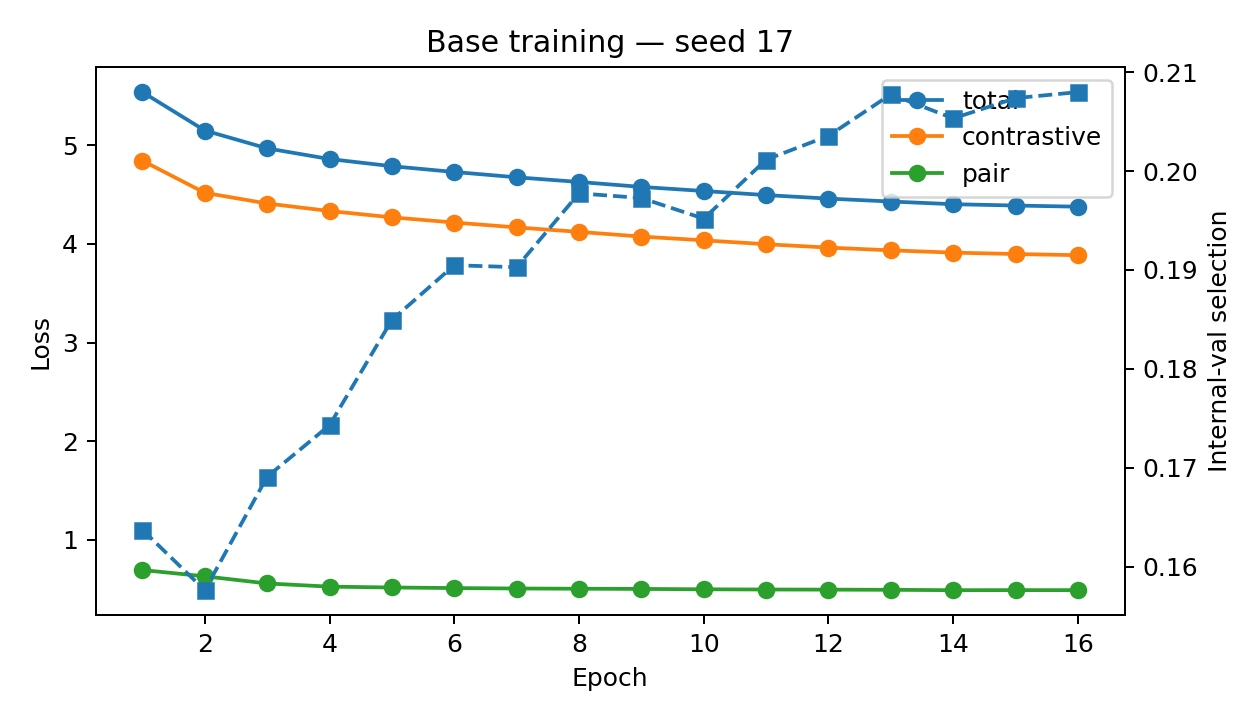

02_base_training_seed42.png


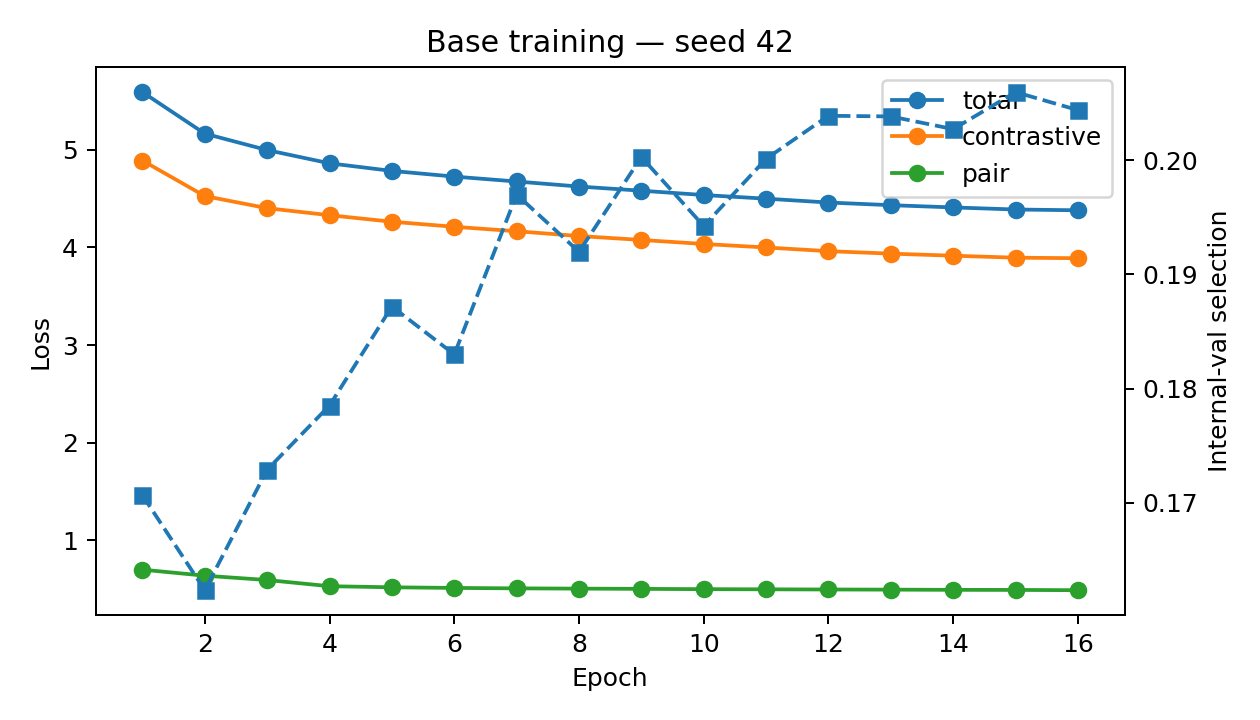

02_base_training_seed73.png


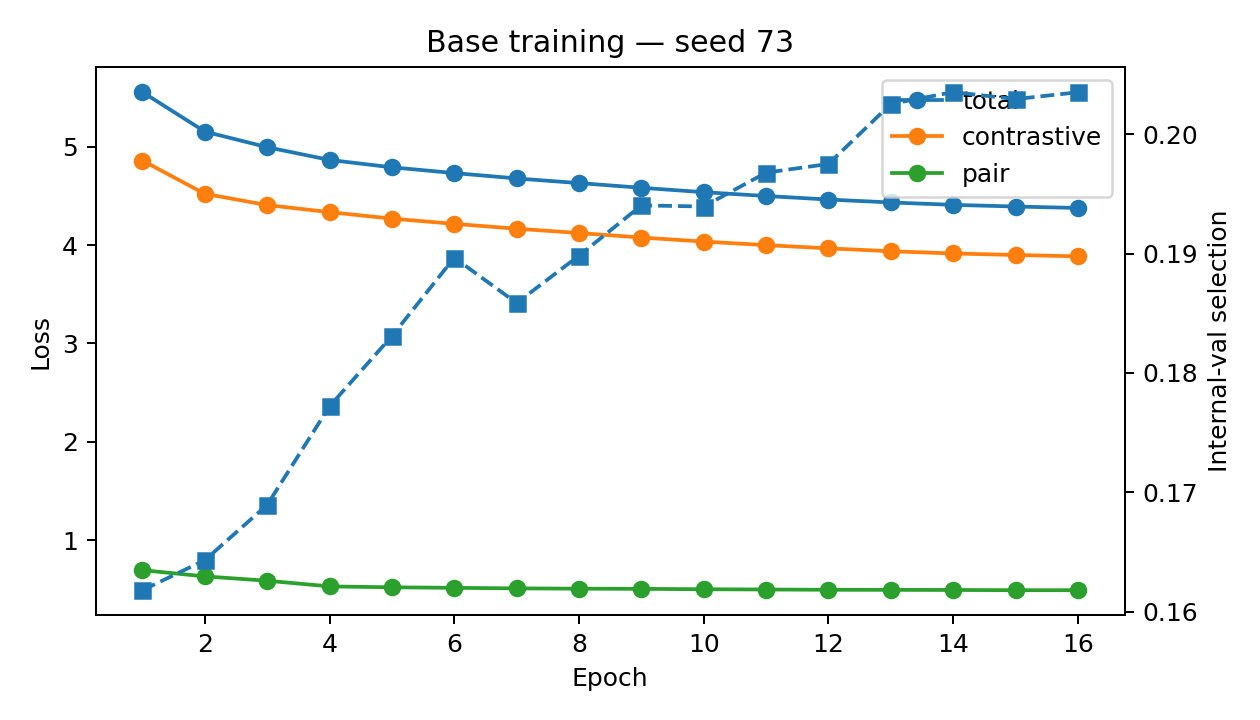

03_monitor_training_seed17.png


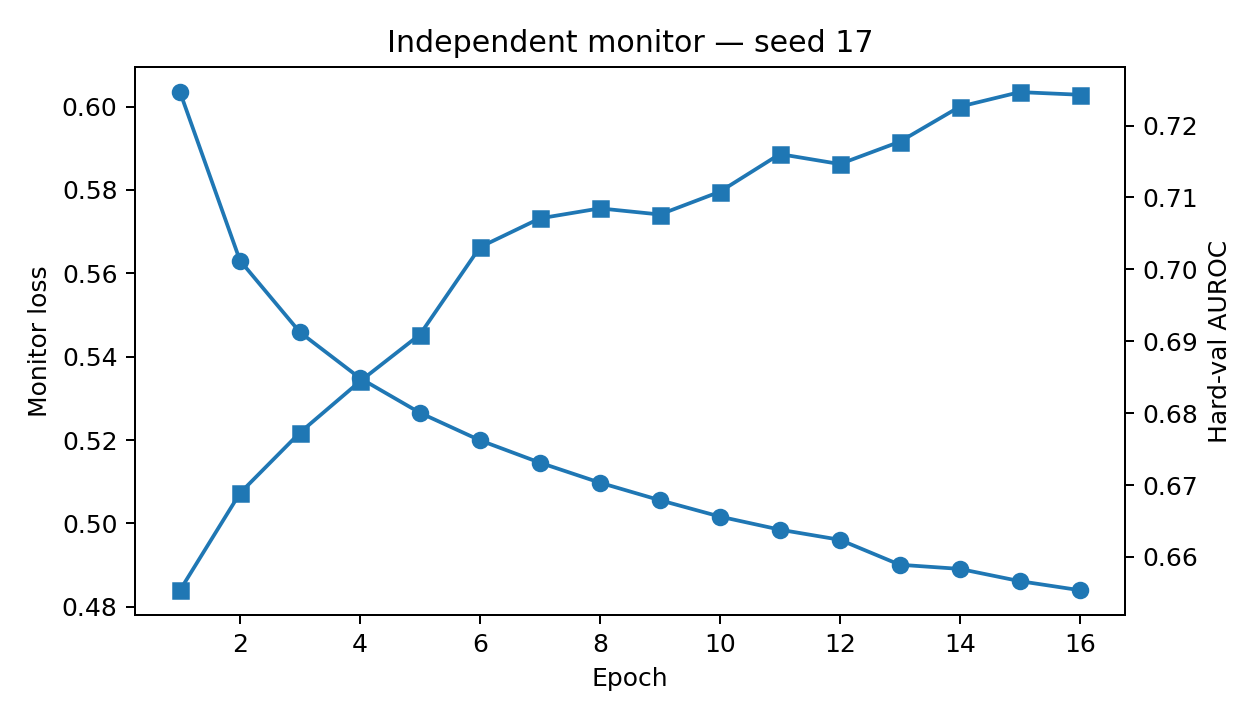

03_monitor_training_seed42.png


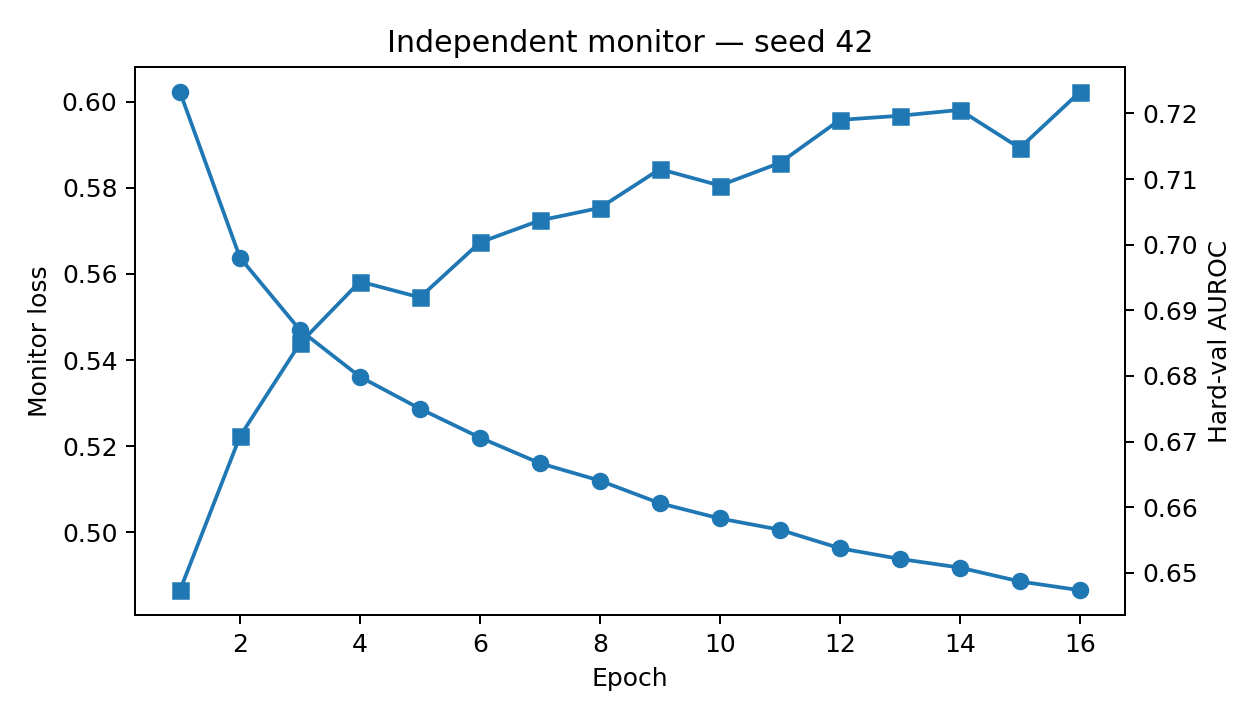

03_monitor_training_seed73.png


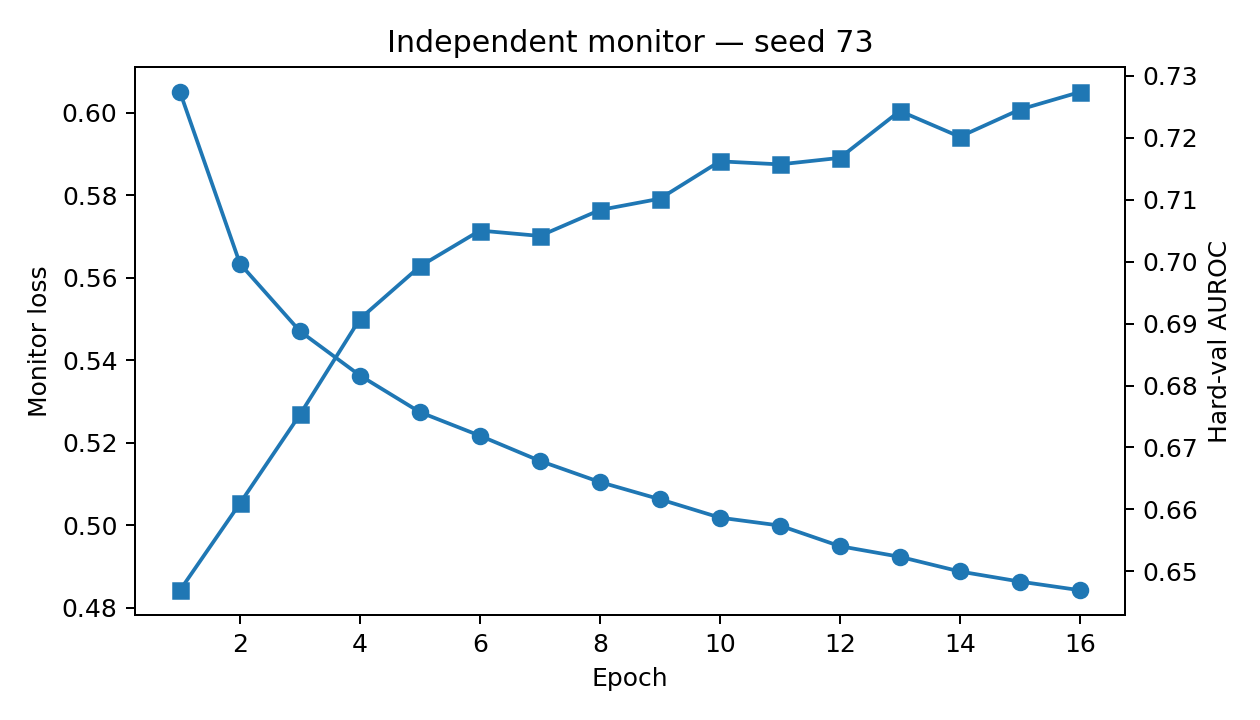

04_retrieval_seed17.png


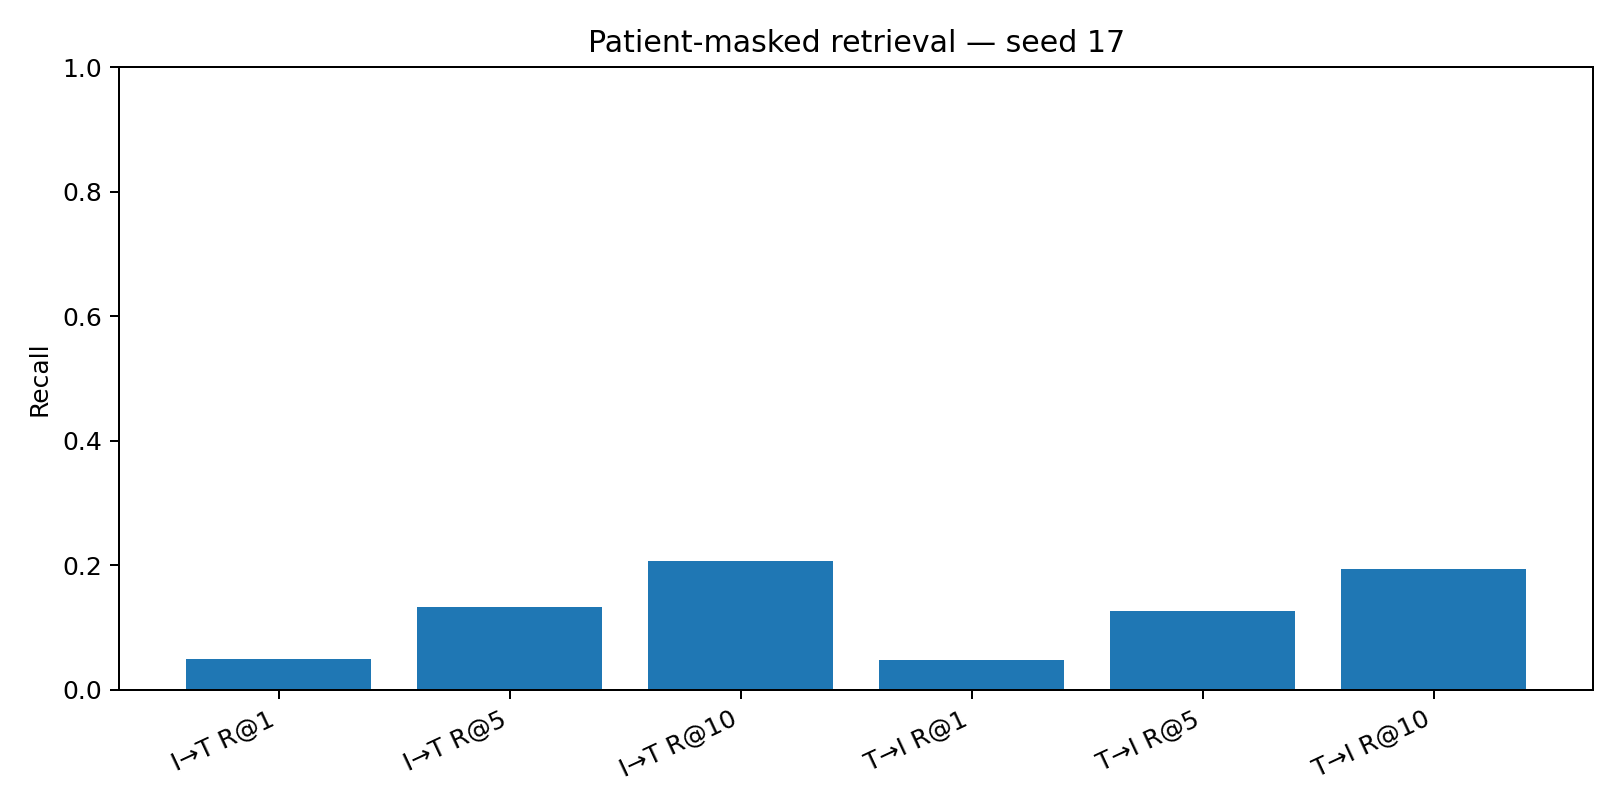

04_retrieval_seed42.png


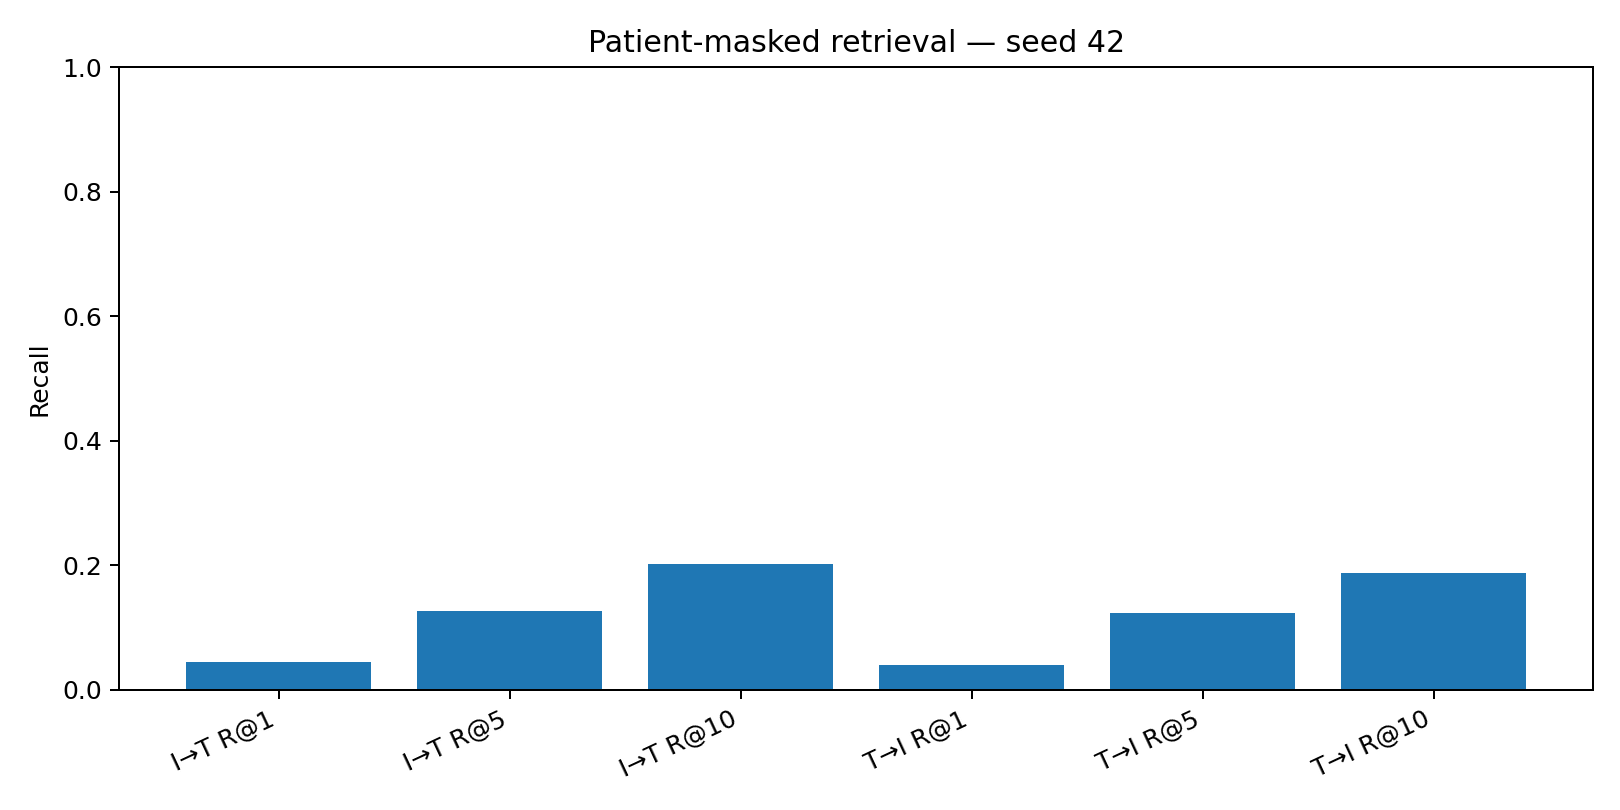

04_retrieval_seed73.png


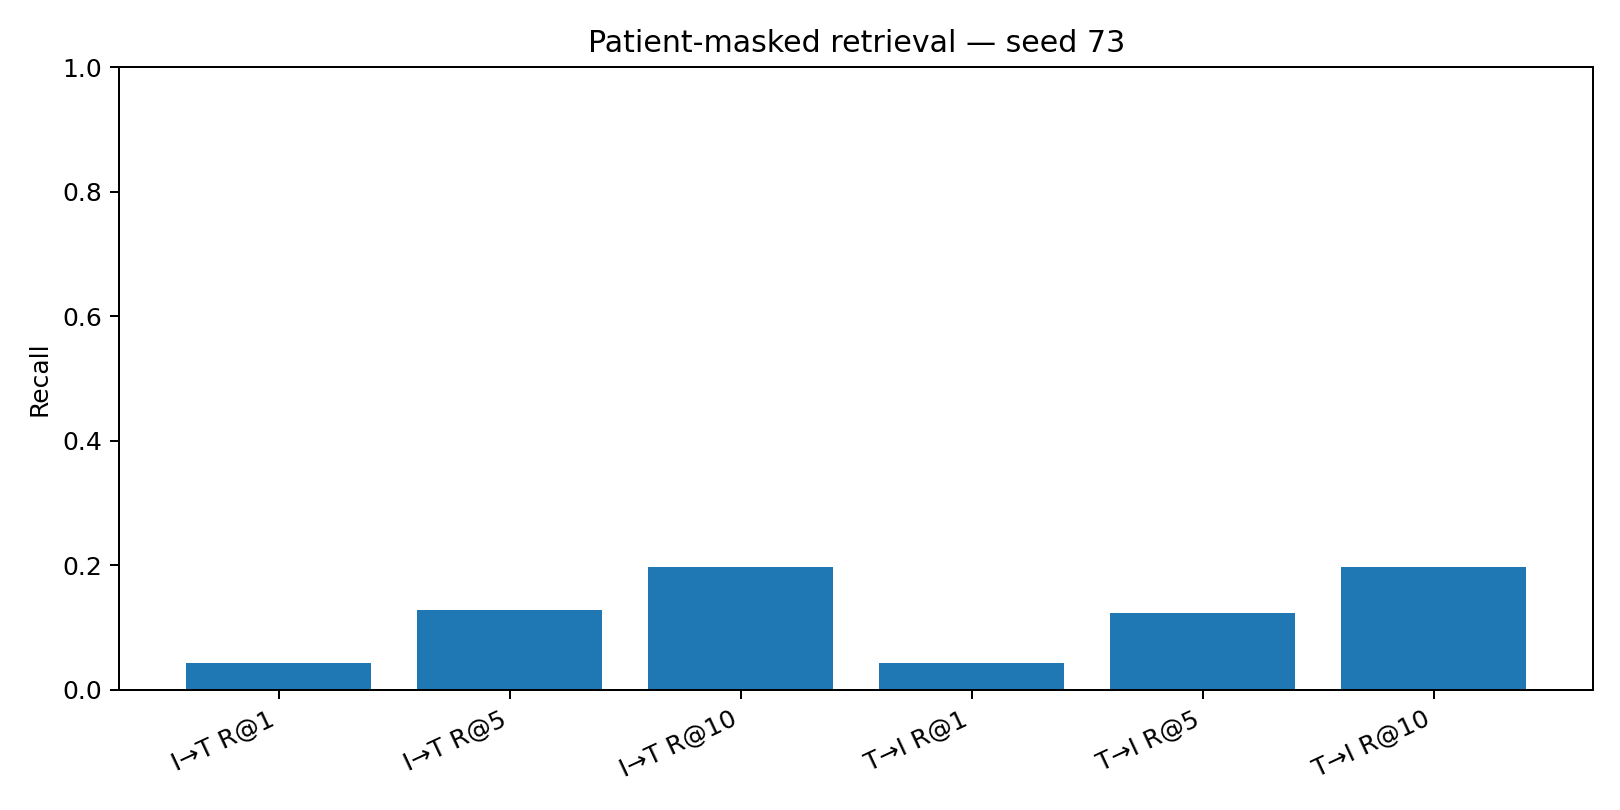

05_reliability_seed17.png


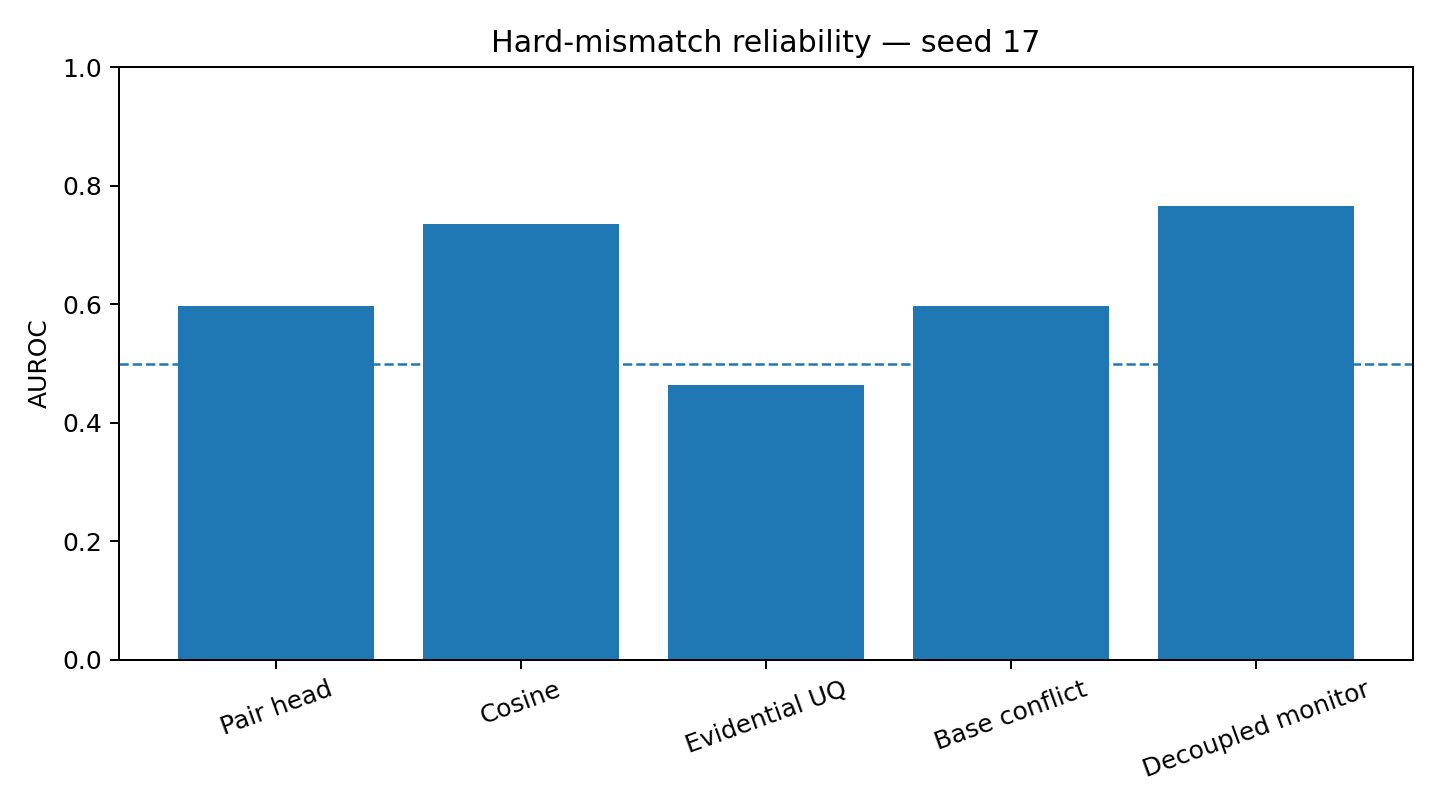

05_reliability_seed42.png


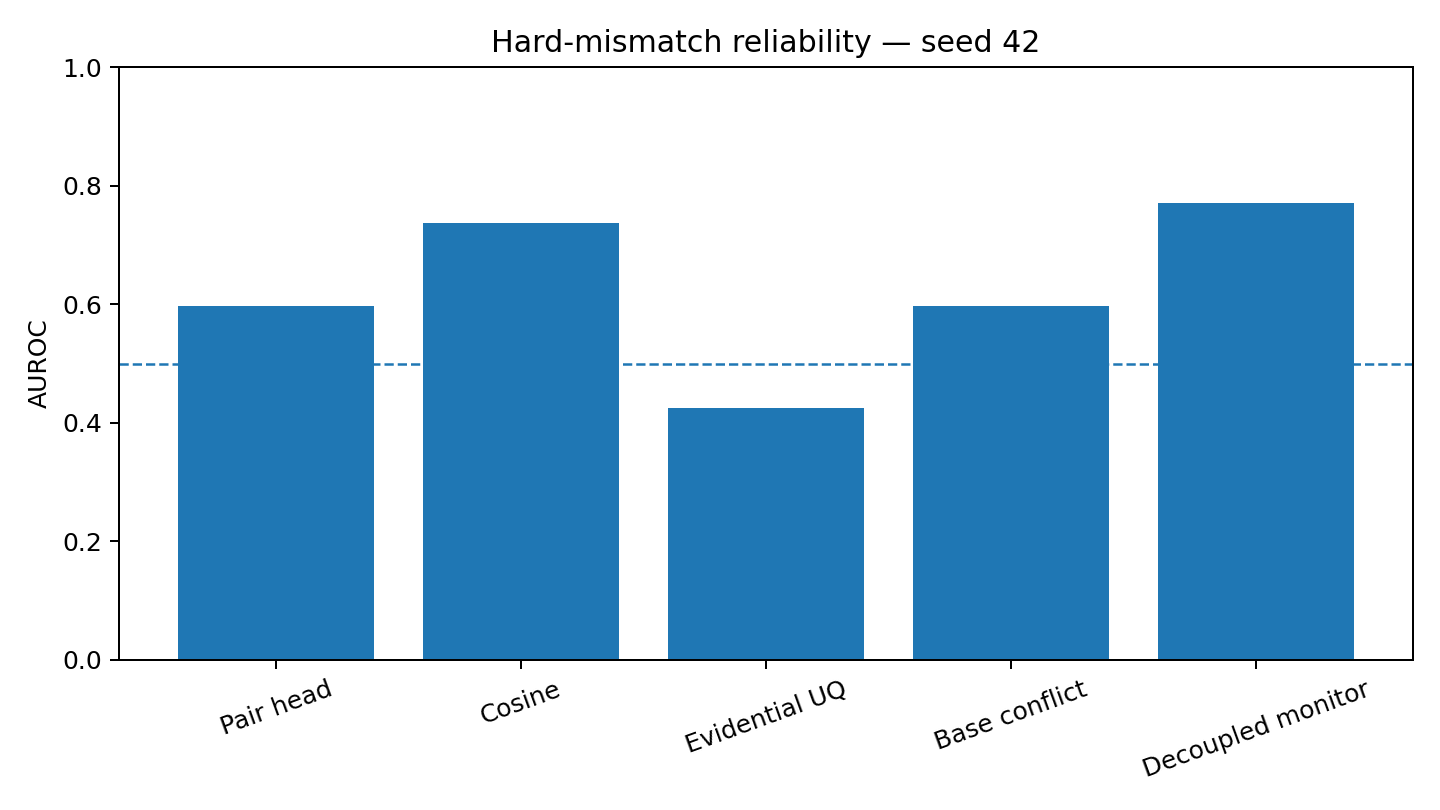

05_reliability_seed73.png


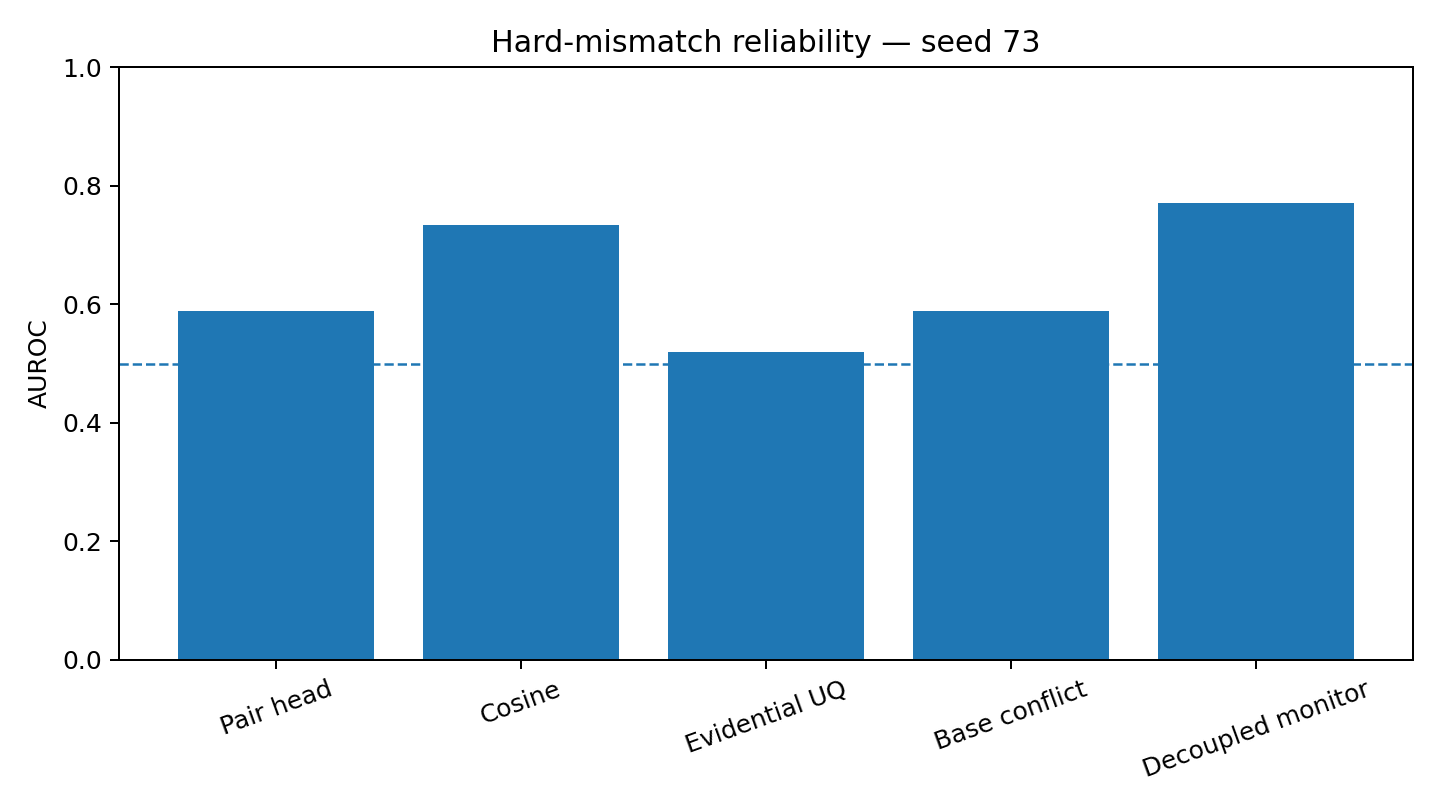

06_hard_conflict_roc_seed17.png


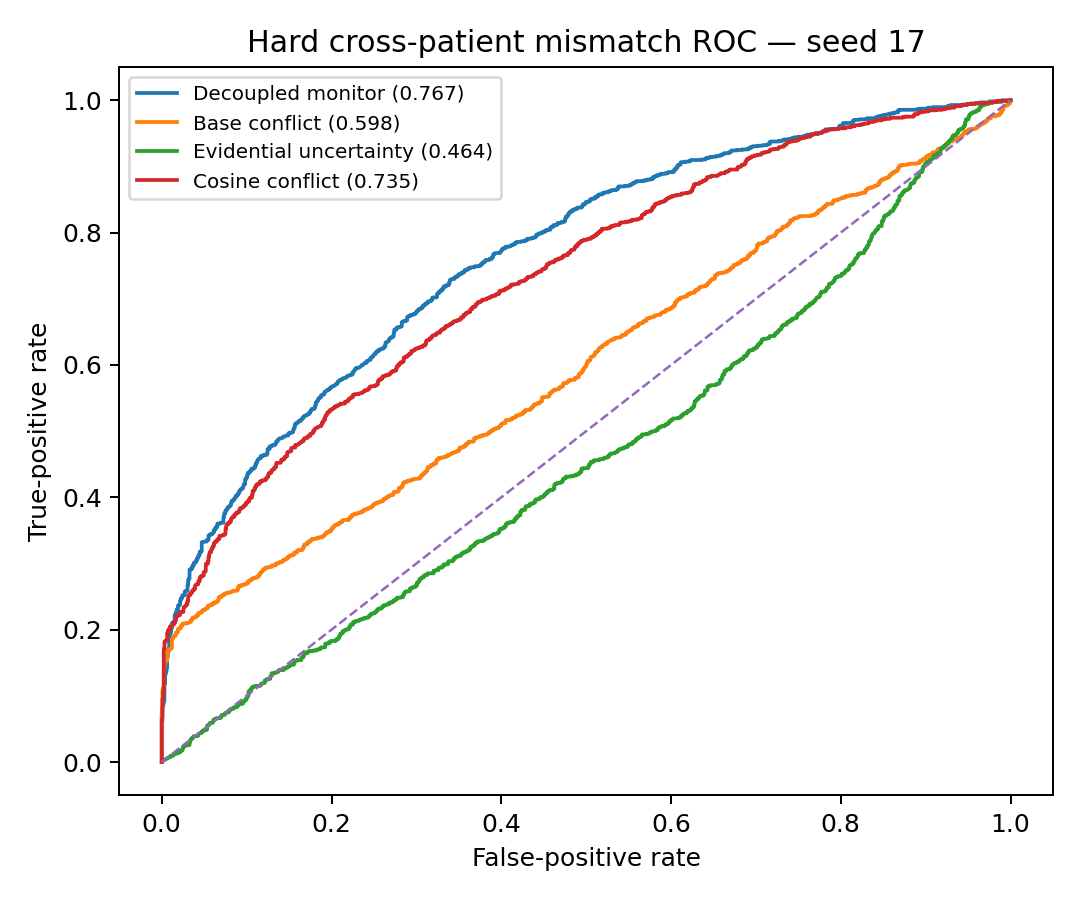

06_hard_conflict_roc_seed42.png


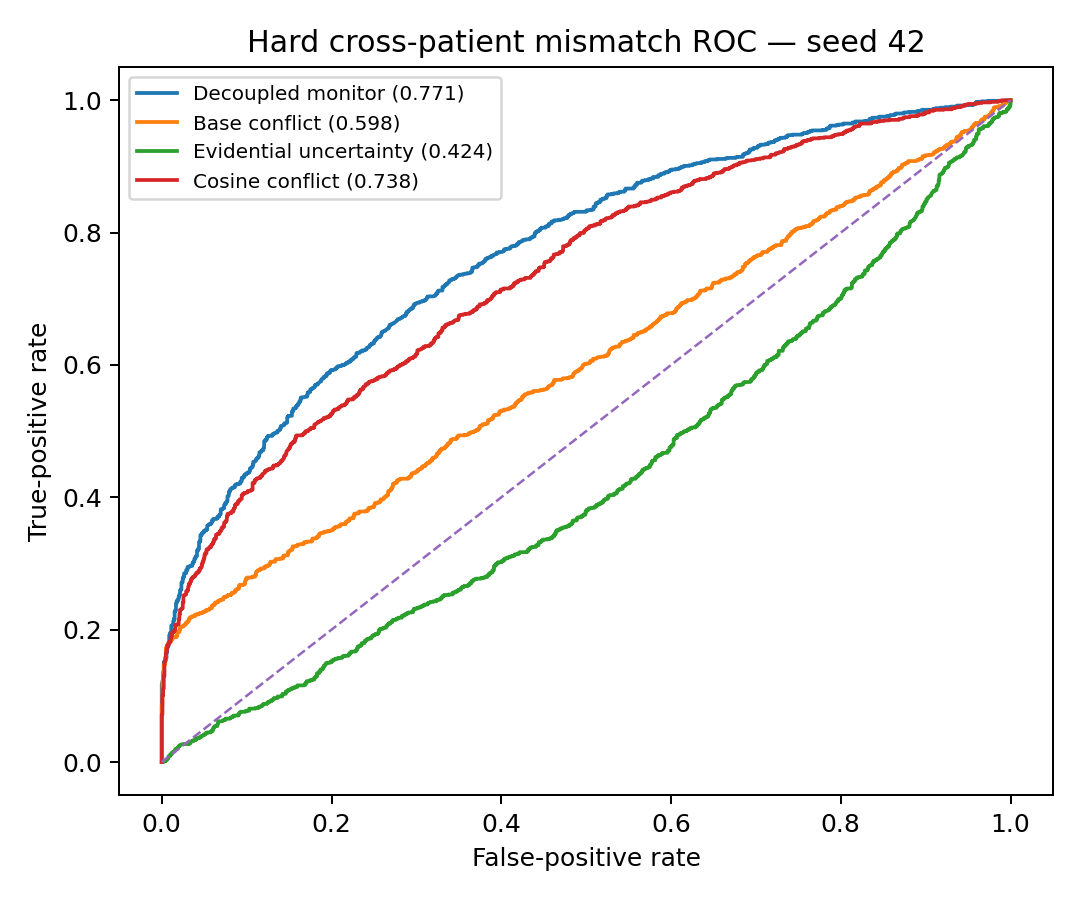

06_hard_conflict_roc_seed73.png


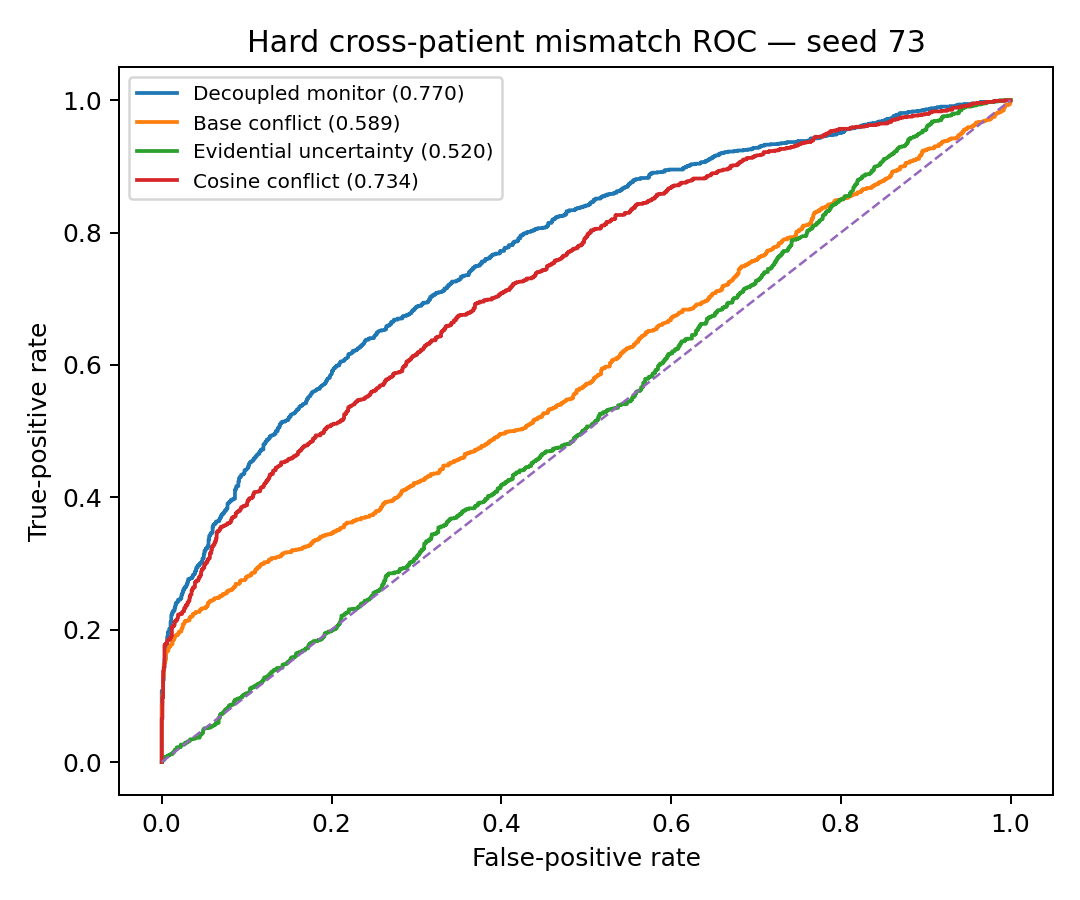

07_calibration_seed17.png


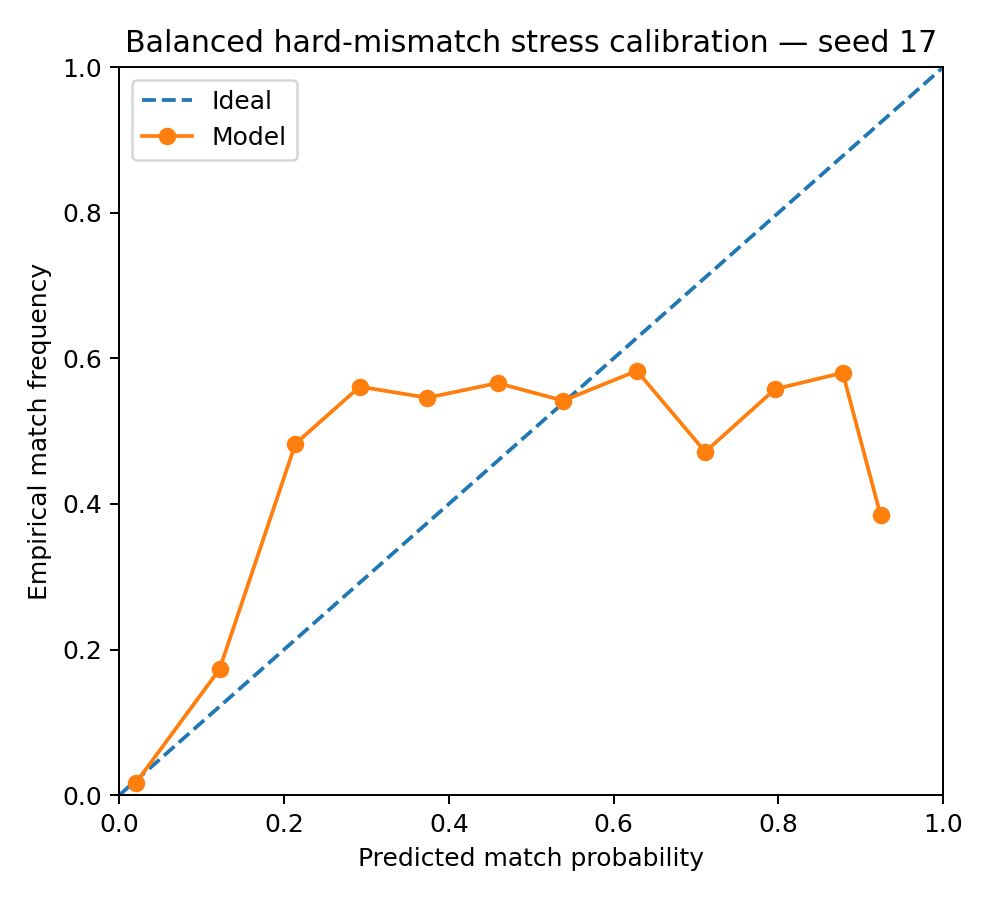

07_calibration_seed42.png


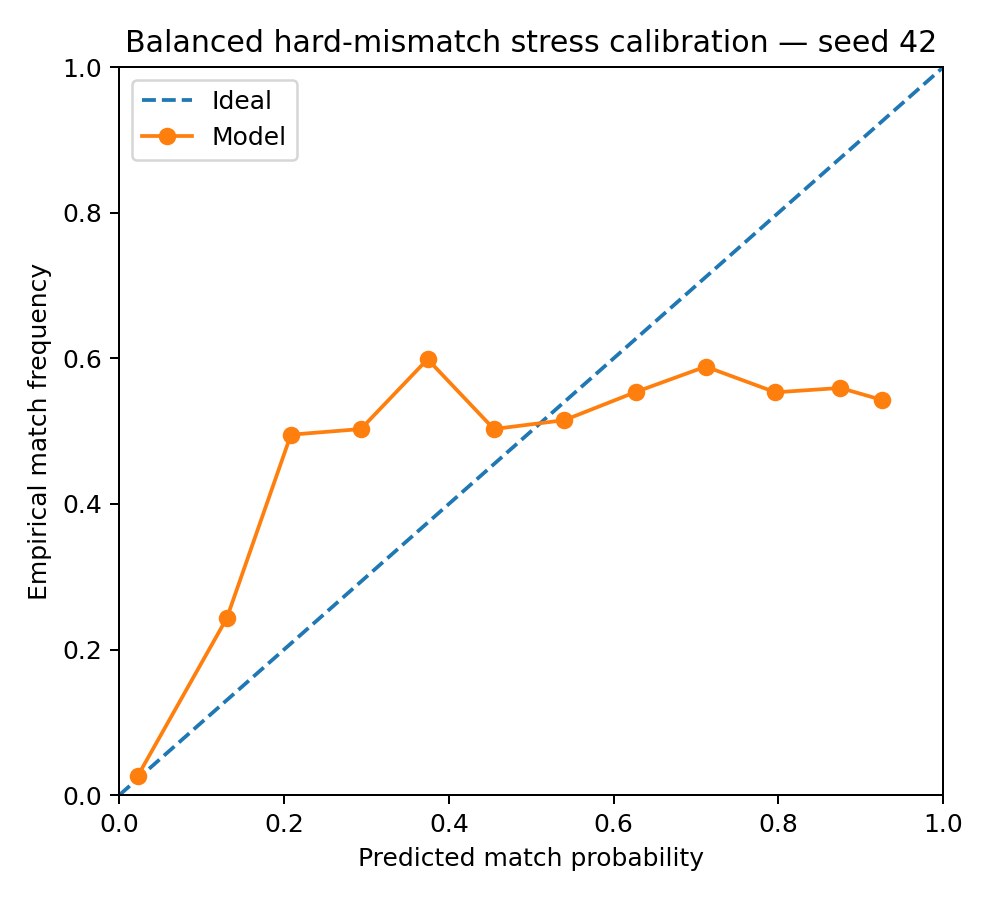

07_calibration_seed73.png


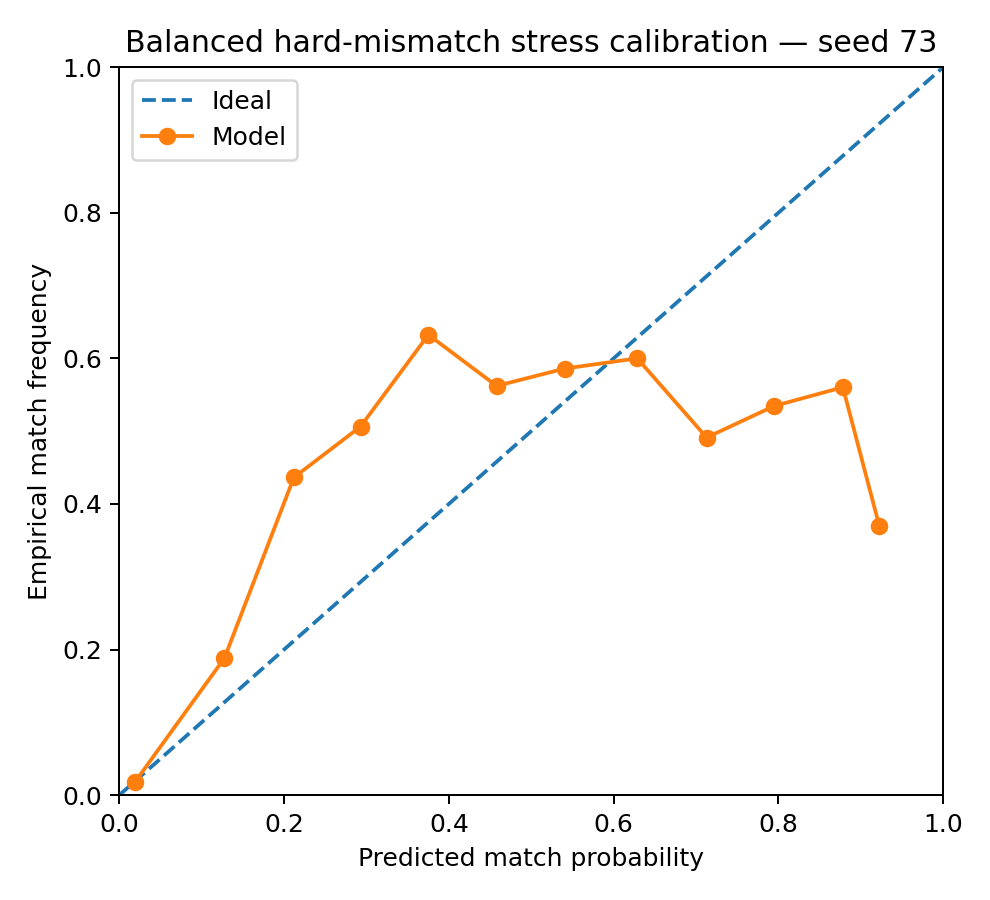

08_language_shift_seed17.png


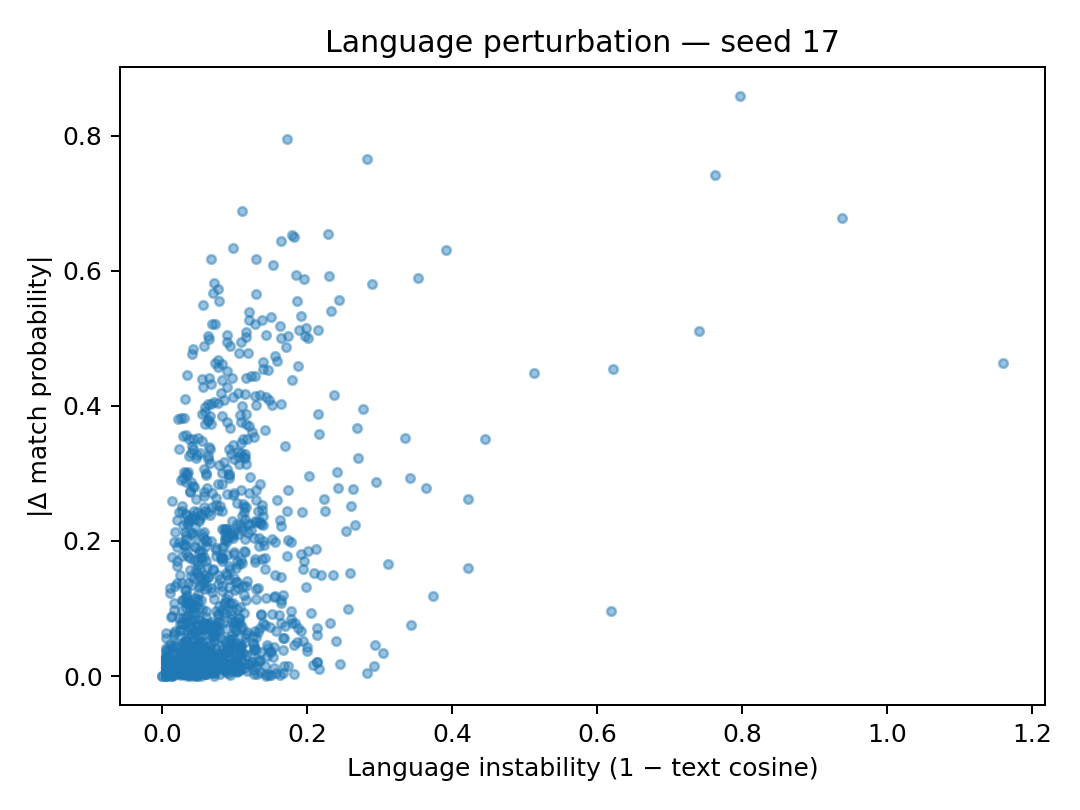

08_language_shift_seed42.png


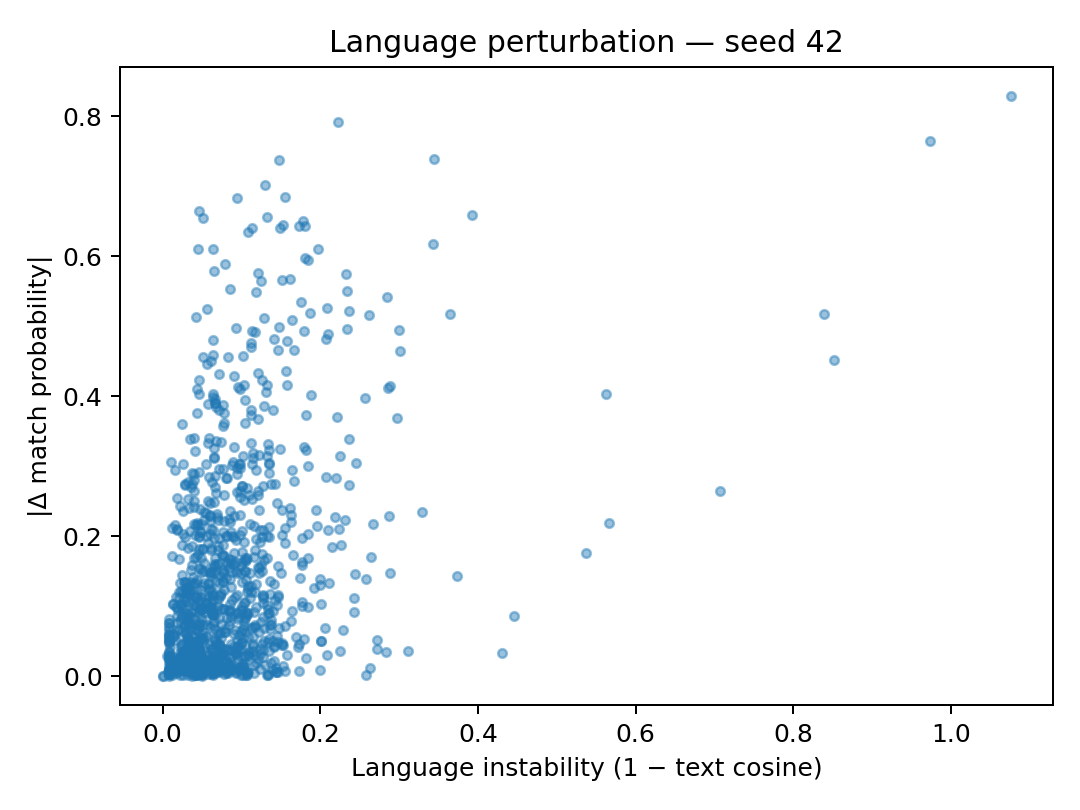

08_language_shift_seed73.png


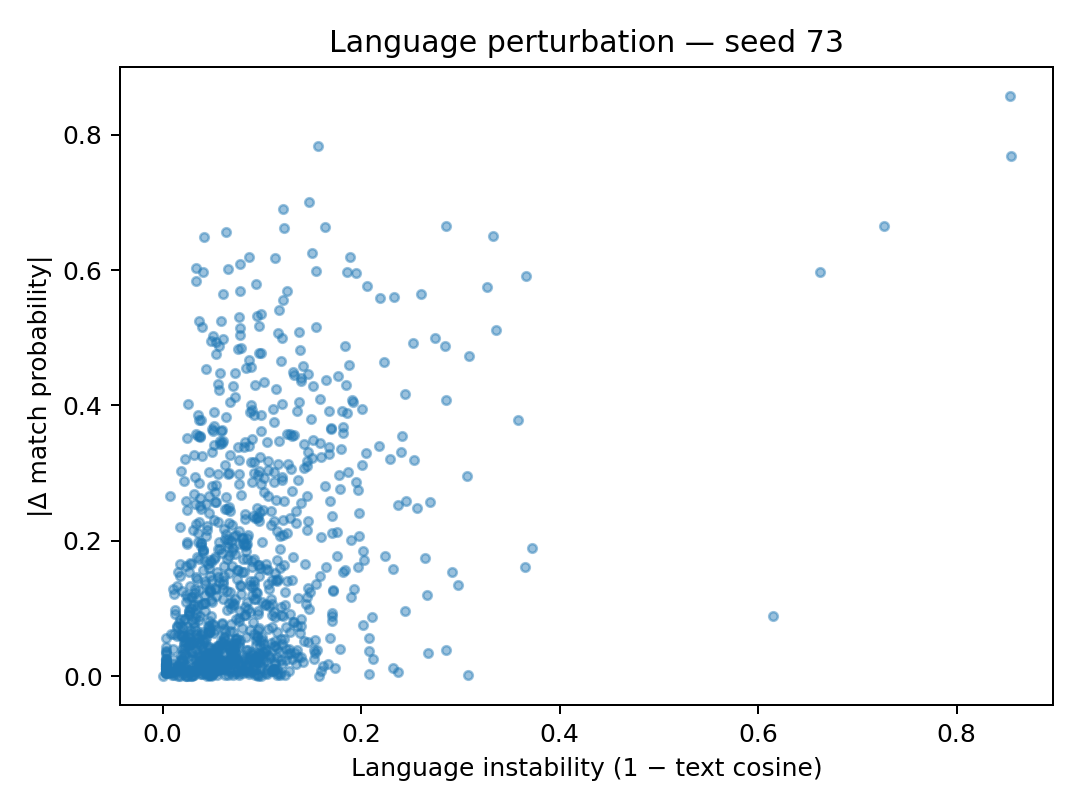

09_visual_shift_seed17.png


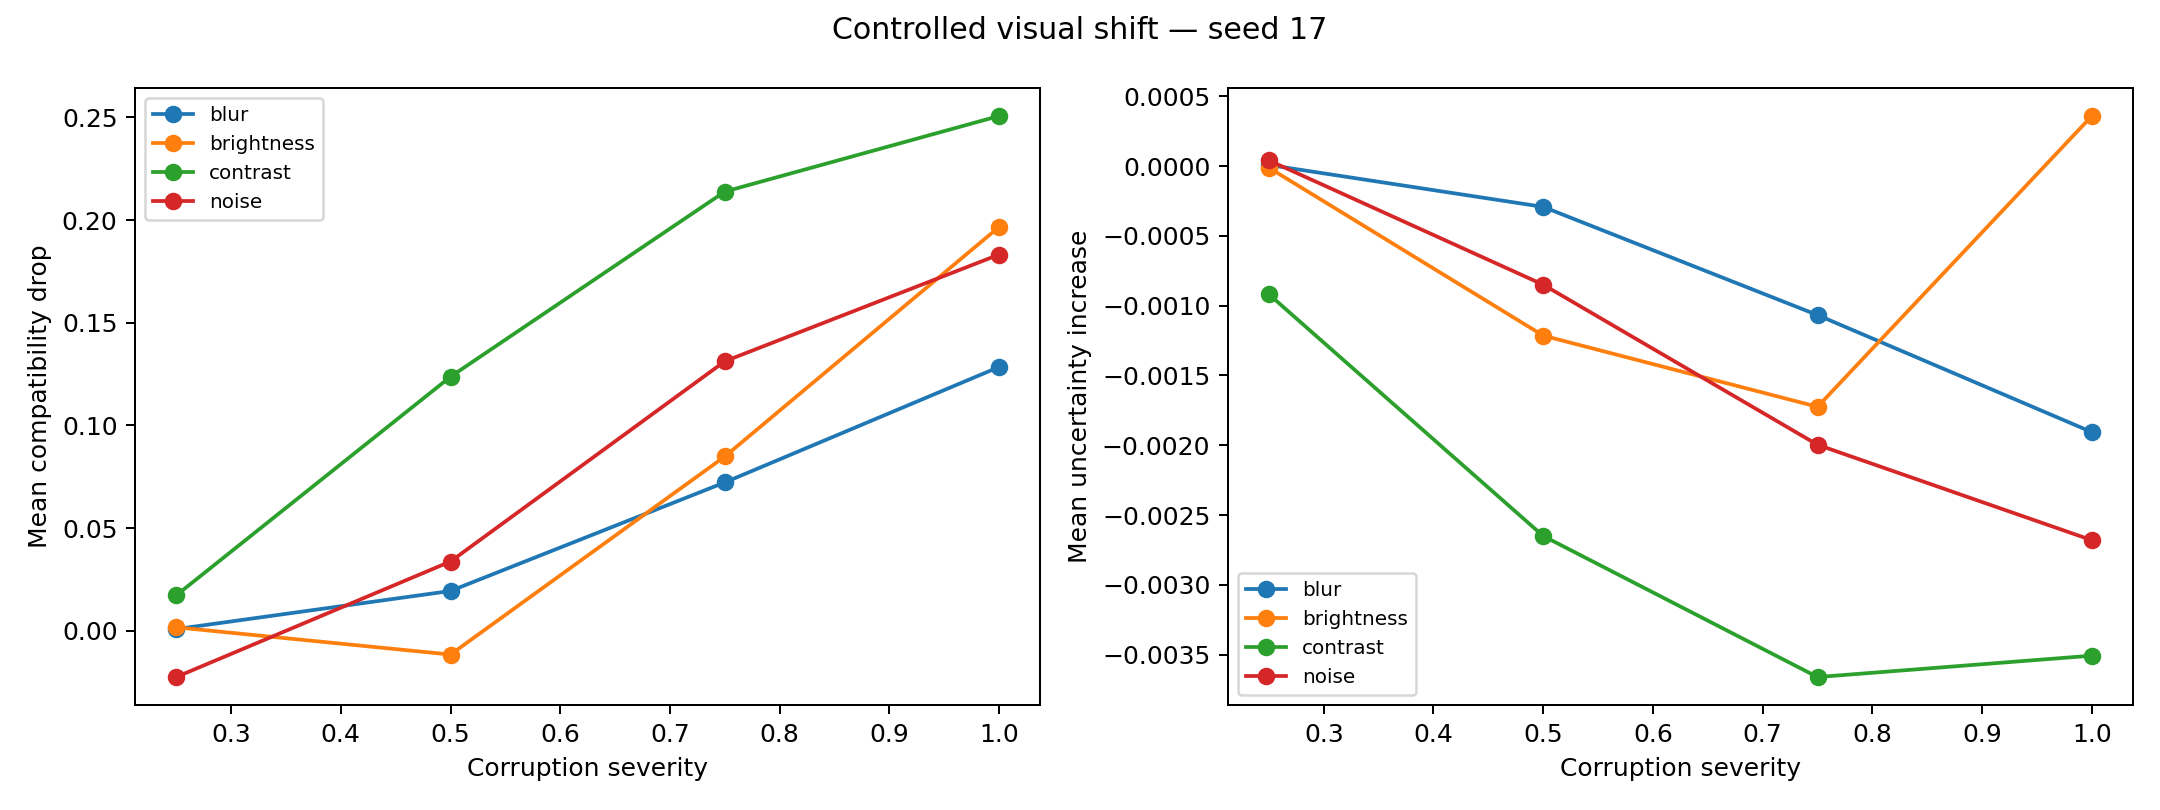

09_visual_shift_seed42.png


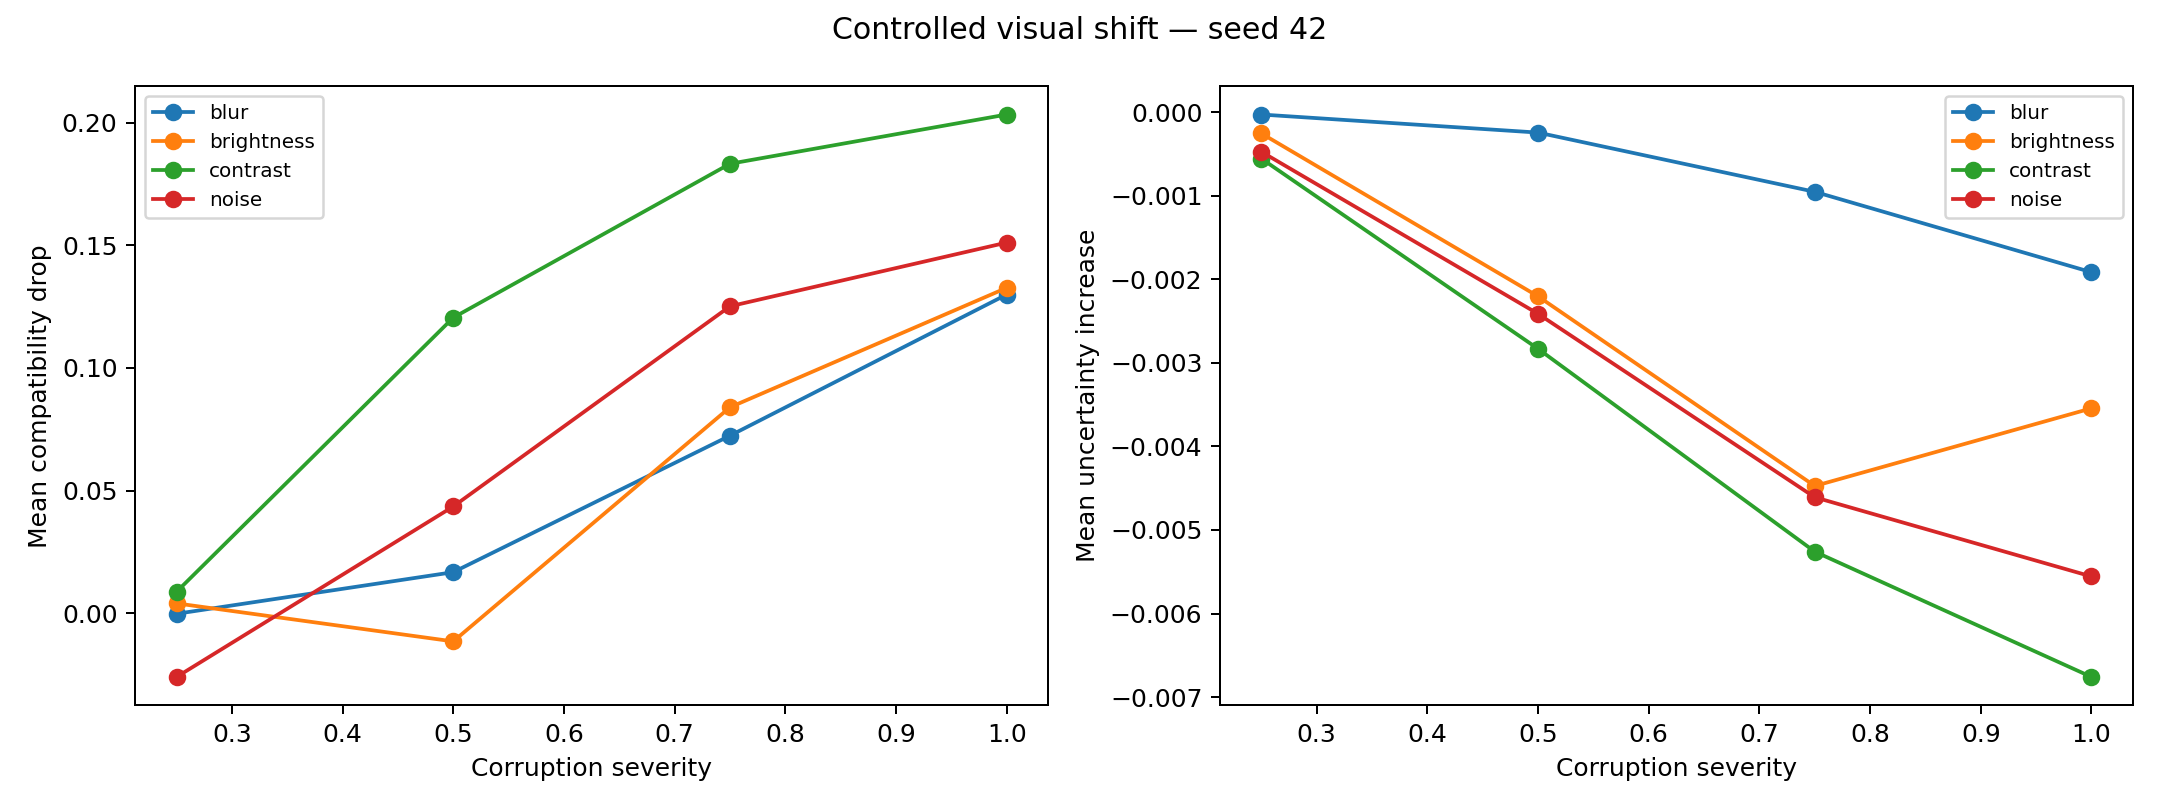

09_visual_shift_seed73.png


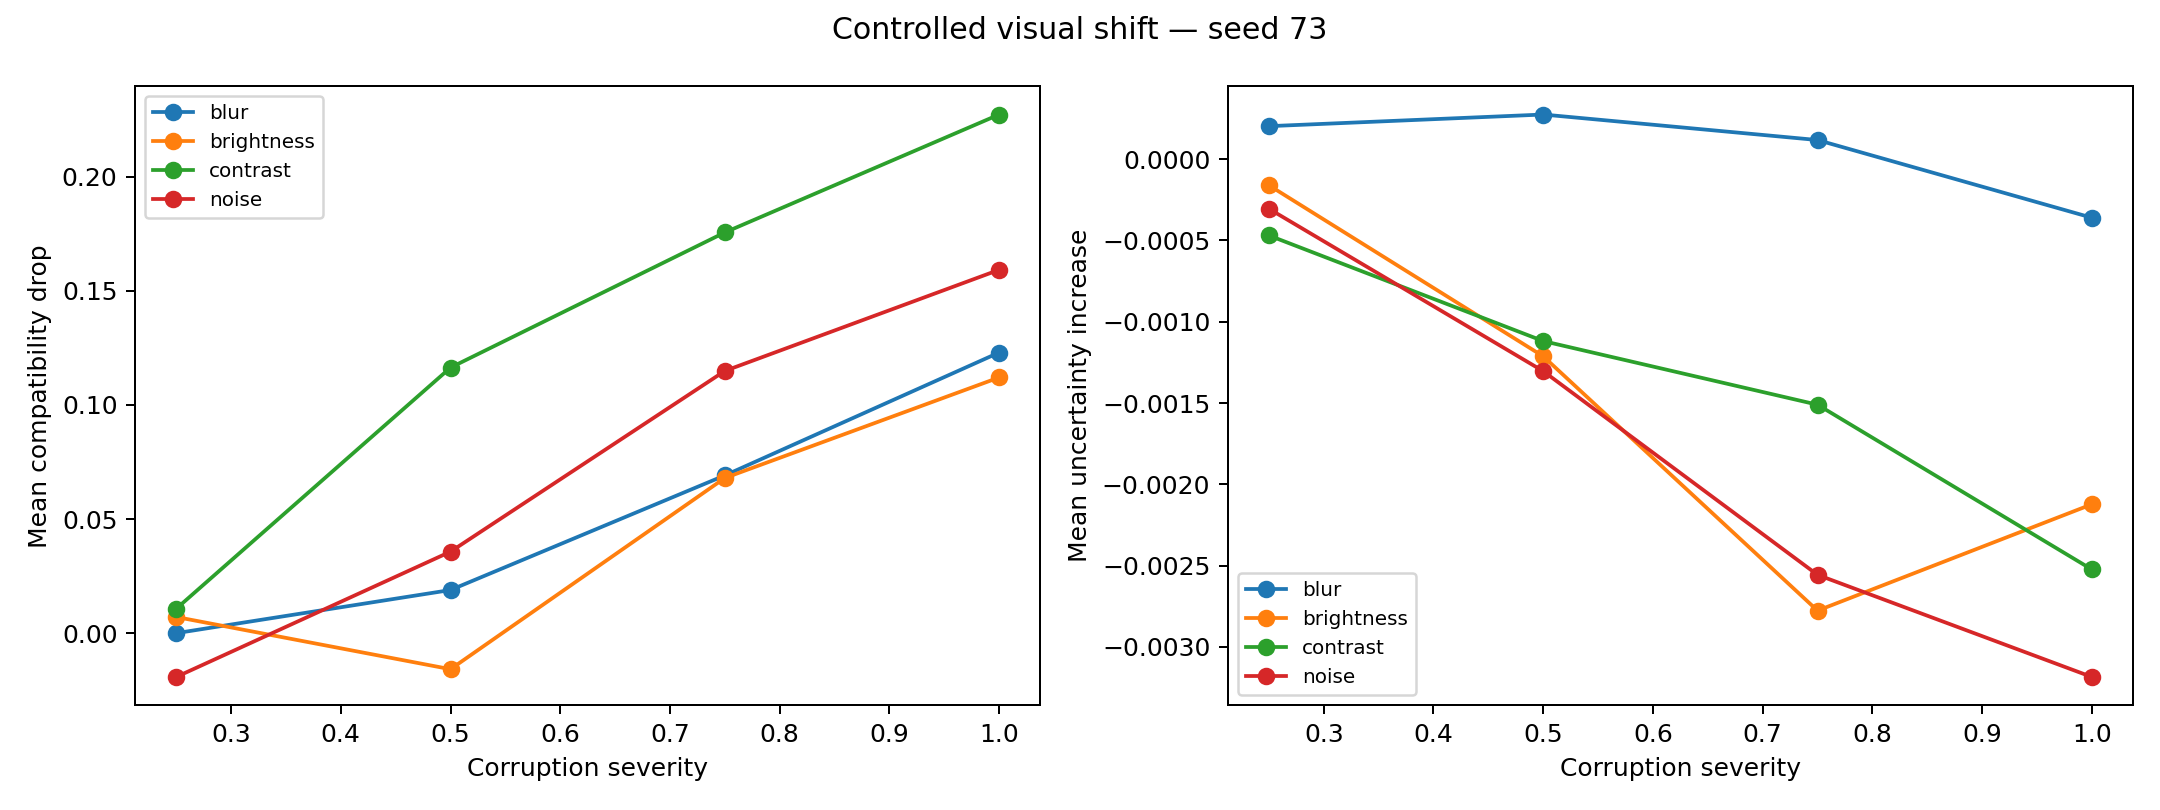

10_risk_coverage_seed17.png


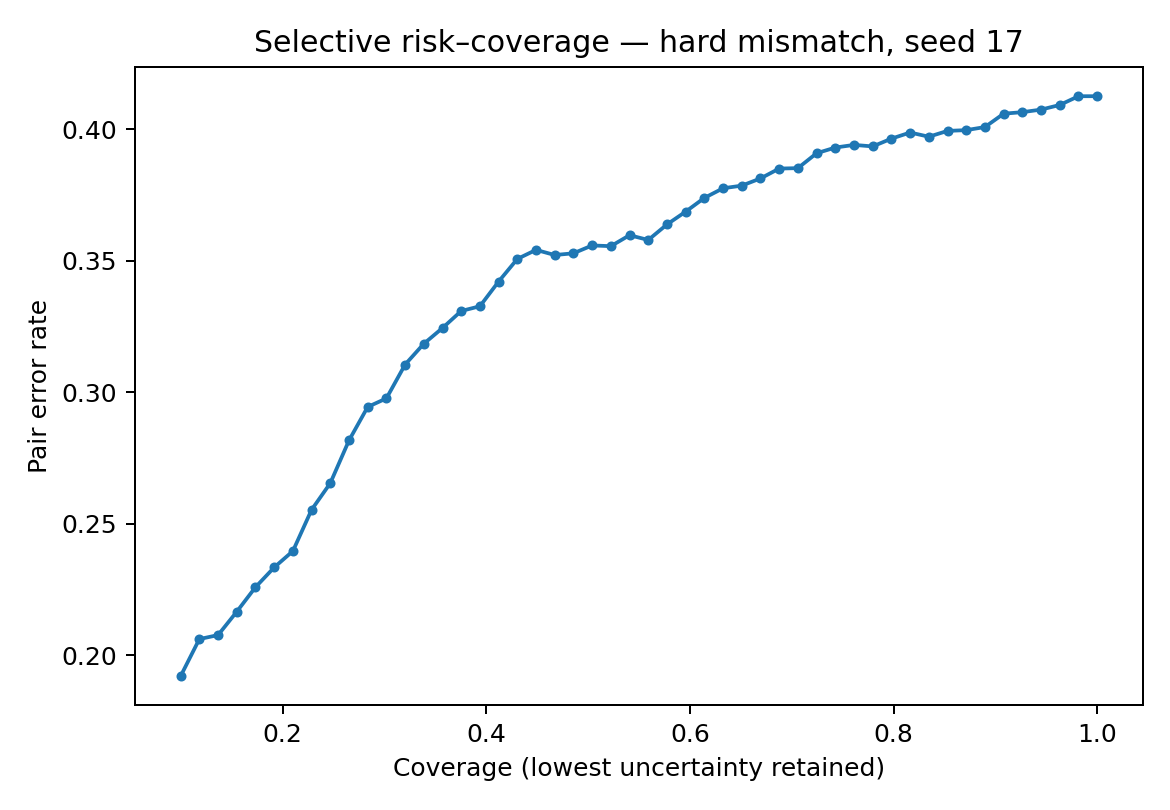

10_risk_coverage_seed42.png


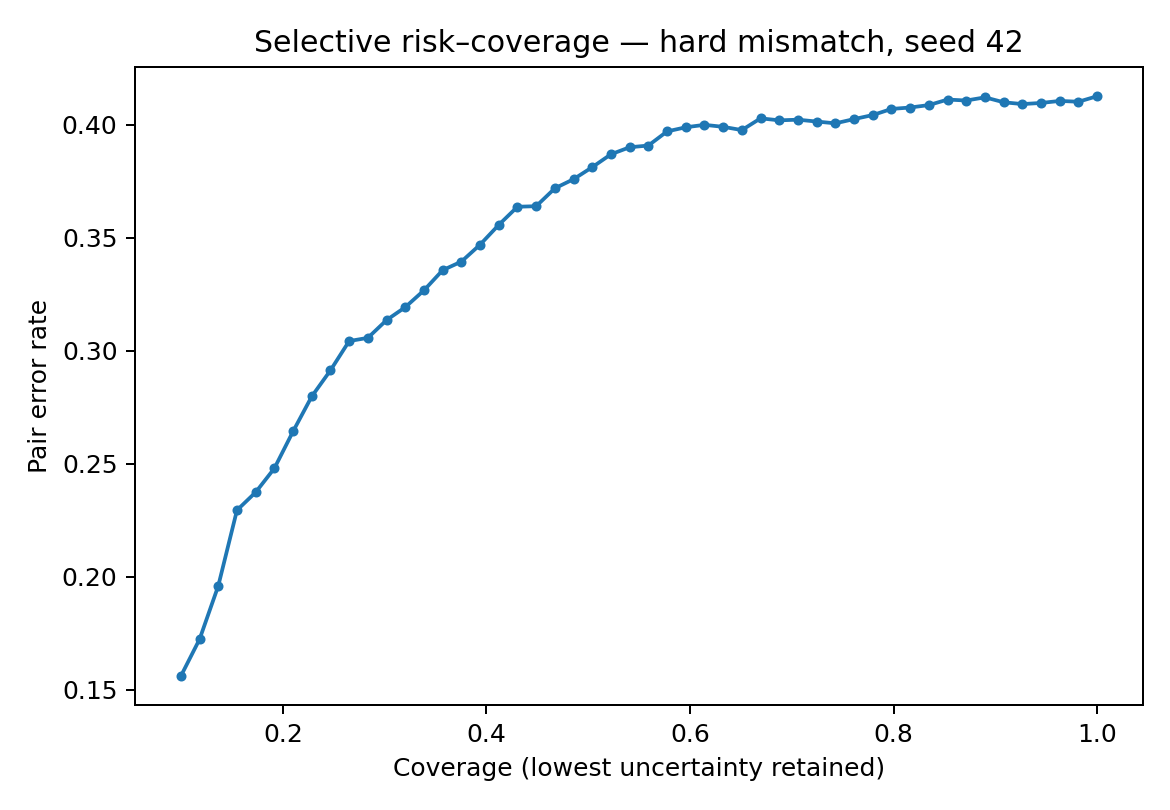

10_risk_coverage_seed73.png


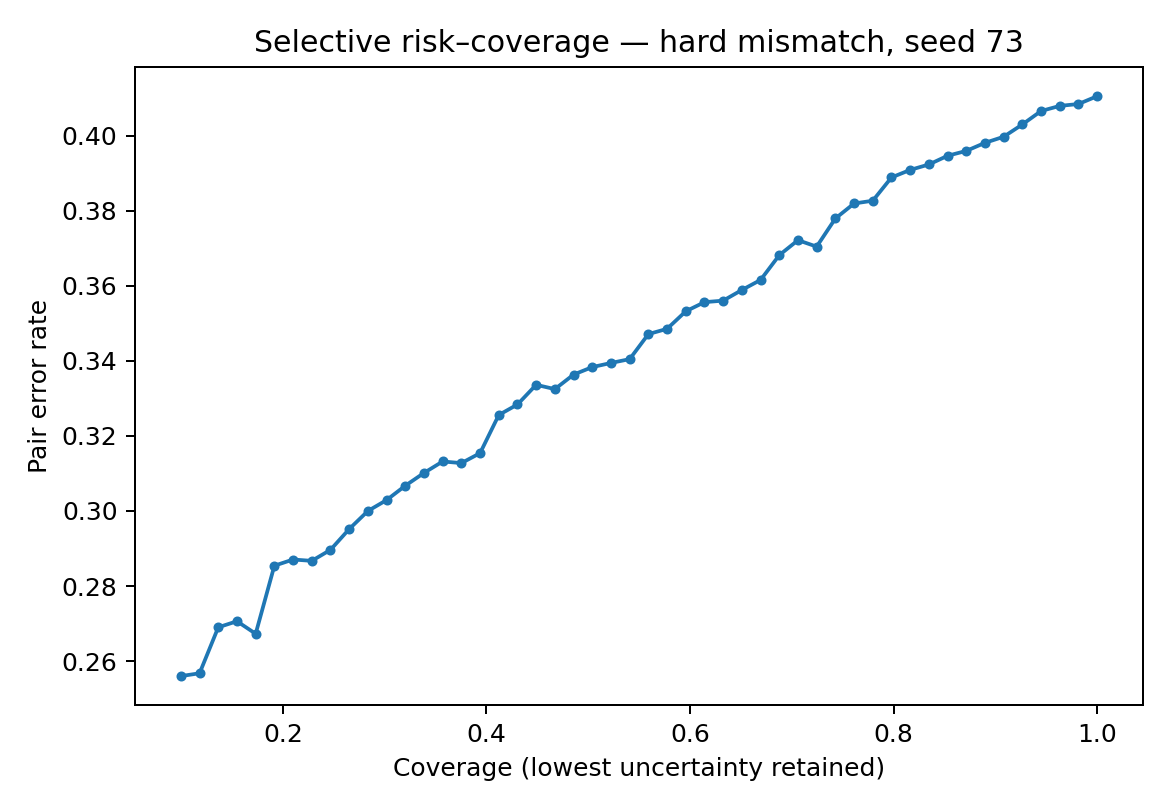

11_primary_summary.png


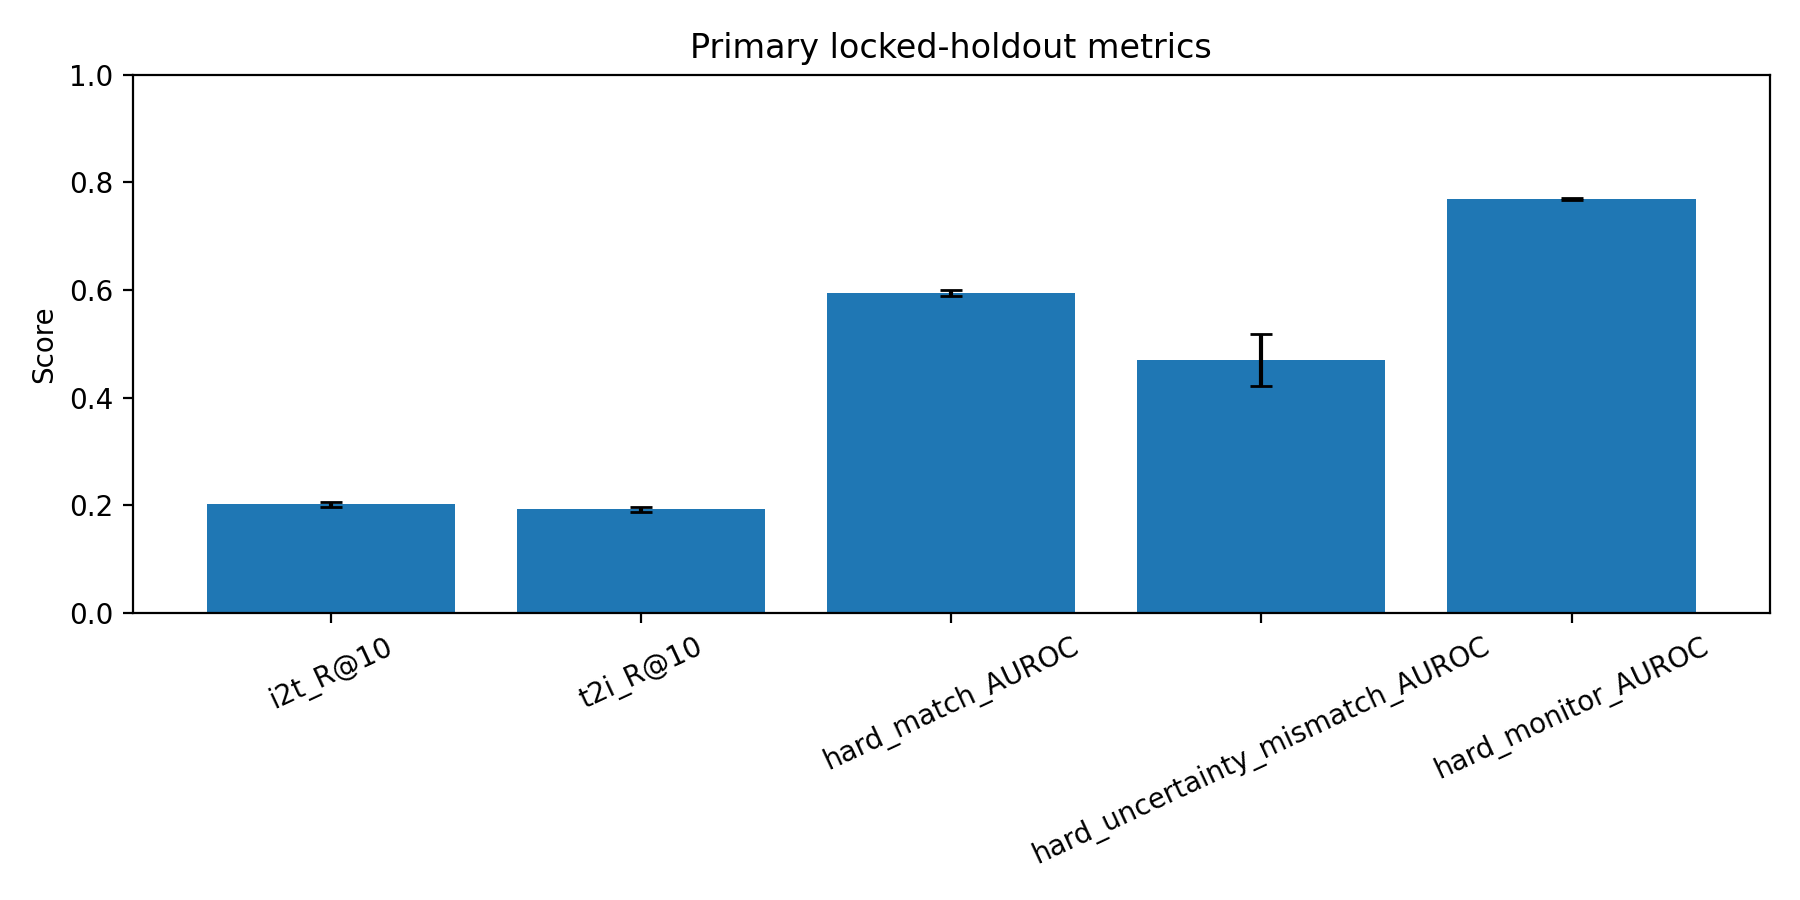

## Download results ZIP
**TRUST_VL_CXR_paper_RESULTS.zip** — 32.09 MB

/kaggle/working/TRUST_VL_CXR_paper_RESULTS.zip

In [26]:
# ============================================================================
# FINAL DASHBOARD
# ============================================================================
seed_table=pd.read_csv(OUT/"seed_level_results.csv")
agg_table=pd.read_csv(OUT/"aggregate_results.csv")
display(Markdown("## Primary locked-holdout results"))
primary=[c for c in [
    "seed","i2t_R@1","i2t_R@5","i2t_R@10","i2t_MRR",
    "t2i_R@1","t2i_R@5","t2i_R@10","t2i_MRR",
    "hard_match_AUROC","hard_match_AUPRC","hard_cosine_match_AUROC",
    "hard_uncertainty_mismatch_AUROC",
    "hard_monitor_AUROC","hard_monitor_AUPRC",
    "hard_base_conflict_AUROC","hard_cosine_conflict_AUROC",
    "hard_uncertainty_conflict_AUROC",
    "hard_monitor_gain_over_uncertainty_AUROC",
    "hard_monitor_gain_over_base_conflict_AUROC",
    "hard_monitor_gain_over_cosine_AUROC",
    "random_match_AUROC","random_monitor_AUROC",
    "mean_text_paraphrase_cos","mean_abs_match_prob_shift",
    "language_instability_vs_match_shift_spearman",
    "visual_drift_vs_compatibility_drop_spearman",
    "visual_drift_vs_uncertainty_delta_spearman",
] if c in seed_table.columns]
display(seed_table[primary].round(4))

display(Markdown("## Across-seed aggregation"))
display(agg_table.round(5))

boot_path=OUT/"bootstrap_all_seeds.csv"
if boot_path.exists():
    display(Markdown("## Clustered 95% uncertainty intervals"))
    boot=pd.read_csv(boot_path)
    display(boot.round(4))

display(Markdown("## Saved figures"))
for fp in sorted(FIG.glob("*.png")):
    print(fp.name);display(IPyImage(filename=str(fp)))

zip_path=Path("/kaggle/working")/f"TRUST_VL_CXR_{PROFILE}_RESULTS.zip"
if zip_path.exists():
    display(Markdown(f"## Download results ZIP\n**{zip_path.name}** — {zip_path.stat().st_size/(1024**2):.2f} MB"))
    display(FileLink(str(zip_path)))


In [27]:
# ============================================================================
# EXTERNAL VLM BASELINE PAIR CONTRACT
# ============================================================================
def export_external_vlm_pair_contract():
    """
    Export pair identities only; raw reports/images are not redistributed.

    An official CXR-CLIP/BiomedCLIP runner can use the local source dataset to
    reconstruct these exact pairs, score them, and write:
      seed, negative_mode, subject_id, study_id,
      report_subject_id, report_study_id, compatibility_score
    """
    rows = []

    for seed in EXP[
        "seeds"
    ]:
        run = OUT / f"seed_{seed}"

        for mode, filename in [
            (
                "hard_text",
                "holdout_hard_pair_predictions.csv",
            ),
            (
                "random",
                "holdout_random_pair_predictions.csv",
            ),
        ]:
            path = run / filename

            if not path.exists():
                continue

            frame = pd.read_csv(
                path,
                dtype={
                    "subject_id":
                    str,
                    "study_id":
                    str,
                    "report_subject_id":
                    str,
                    "report_study_id":
                    str,
                },
            )

            keep = frame[
                [
                    "subject_id",
                    "study_id",
                    "report_subject_id",
                    "report_study_id",
                    "label_match",
                    "pair_type",
                    "view",
                ]
            ].copy()

            keep.insert(
                0,
                "negative_mode",
                mode,
            )

            keep.insert(
                0,
                "seed",
                int(
                    seed
                ),
            )

            rows.append(
                keep
            )

    if not rows:
        print(
            "No completed seed pair files yet."
        )

        return None

    contract = pd.concat(
        rows,
        ignore_index=True,
    )

    path = (
        OUT
        / "external_vlm_pair_contract.csv"
    )

    contract.to_csv(
        path,
        index=False,
    )

    print(
        "External VLM pair contract:",
        path,
    )

    return contract


_EXTERNAL_VLM_CONTRACT = export_external_vlm_pair_contract()


External VLM pair contract: /kaggle/working/TRUST_VL_CXR/paper/external_vlm_pair_contract.csv
